Senescent signatures are characteristic sets of molecular and phenotypic markers—often including specific gene expression patterns, protein biomarkers, and secreted factors—that distinguish senescent cells from normal, proliferating, or quiescent cells. These signatures are used to identify, quantify, and study senescent cell populations both in vitro and in vivo.

For starters I will use SenMayo:

It is a comprehensive gene set of 125 genes, primarily composed of SASP factors, transmembrane and intracellular proteins. It reliably identifies senescent cells across tissues and species and outperforms existing senescence/SASP gene panels. Key genes include inflammatory cytokines (IL1A, CXCL8), proteases (MMP2), and regulators like IGF1. SenMayo can characterize senescent cells at the single-cell level and track their clearance.

The reason behind starting with SenMayo is because we are using single cell RNA data from SmartSeq2 sequencing from Liver. This technique allwos the capture of full-length transcripts from individual cells with high sensitivity and accuracy. It is excellent for detecting low abundance and alternatively spliced transcripts and provides detailed information on transcript isoforms. An excelent technique to investigate the presence of senescence marker genes.

I will also try a different senescent signature, CellAge.

A curated database and gene set of genes driving or associated with cellular senescence used to identify senescence-related pathways and genetic programs in cells.

CellAge is a human derived senescent gene set signature, just like SenMayo, but unlike the previous signature it does not have a readily available file with mice orthologs for my utilization. Based on this the mapping will have to be done first between the human CellAge genes to the mouse orthologs.

A third senescent signature will be Hernandez-Segura: 

Transcriptomic profiles defining distinct senescence states depending on senescence inducers and cell types, highlighting heterogeneity in senescent cell gene expression.

None of these three signatures were constructed with single cell RNA sequencing. SenMayo was from bulk genomics, CellAge was built from a compilation of information of senescence from literature and Hernandez-Segura was built from bulk.

In [2]:
import gseapy as gp
import scanpy as sc
import pandas as pd
from mygene import MyGeneInfo
import mygene
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
from matplotlib_venn import venn3


In [3]:
# Data retrieval
sc.settings.set_figure_params(dpi=50, facecolor="white")

# Load your liver FACS Smart-seq2 data
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated.h5ad")  # path to your file

# Make sure variable (gene) names are unique
adata.var_names_make_unique()

# Make sure observation (cell) names are unique
adata.obs_names_make_unique()

# Inspect AnnData object
print(adata)

#display the pandas crosstab 
print(pd.crosstab(adata.obs['age'], adata.obs['mouse.id']))

AnnData object with n_obs × n_vars = 2858 × 19559
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'age_sex', 'doublet_score', 'predicted_doublet', 'leiden_0.5', 'leiden_0.75', 'leiden_1.0', 'cell_type', 'celltypist_predicted_labels'
    var: 'n_cells', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mean', 'std', 'mouse_gene_symbols'
    uns: 'age_colors', 'age_sex_colors', 'cell_ontology_class_colors', 'cell_type_colors', 'celltypi

In [2]:
import pandas as pd

# 1. Python Lists: Hernandez-Segura (Human Symbols)
hernandez_enriched = ['ACADVL', 'ADPGK', 'B4GALT7', 'BCL2L2', 'CCND1', 'CHMP5', 'DDA1', 'DGKA', 'DYNLT3', 'FAM214B', 'GBE1', 'GDNF', 'KLC1', 'MT-CYB', 'NOL3', 'P4HA2', 'PDLIM4', 'PLK3', 'PLXNA3', 'POFUT2', 'RAI14', 'SCOC', 'SLC10A3', 'SLC16A3', 'SUSD6', 'TAF13', 'TMEM87B', 'TOLLIP', 'TSPAN13', 'UFM1', 'ZBTB7A', 'ZNHIT1']
hernandez_depleted = ['ARHGAP35', 'ARID2', 'ASCC1', 'C2CD5', 'CNTLN', 'CREBBP', 'EFNB3', 'GSTM4', 'ICE1', 'KCTD3', 'MEIS1', 'NFIA', 'PATZ1', 'PCIF1', 'PDS5B', 'RHNO1', 'SMO', 'SPATA6', 'SPIN4', 'STAG1', 'TRDMT1', 'USP6NL', 'ZC3H4']

# 2. Load cellage3.tsv with automatic column detection
cellage_genes = []
try:
    # Read the first few lines to check columns
    cellage_df = pd.read_csv('cellage3.tsv', sep='\t')
    
    # Try to find a column that looks like gene symbols
    possible_columns = ['Symbol', 'symbol', 'gene', 'Gene', 'Gene Symbol', 'gene_symbol']
    target_col = next((c for c in possible_columns if c in cellage_df.columns), None)
    
    if target_col:
        cellage_genes = cellage_df[target_col].dropna().unique().tolist()
    else:
        # If no column name matches, use the first column
        cellage_genes = cellage_df.iloc[:, 0].dropna().unique().tolist()
        print(f"Note: Using first column of cellage3.tsv ('{cellage_df.columns[0]}') as gene list.")
except Exception as e:
    print(f"Could not read cellage3.tsv: {e}")

# 3. Load SAUL_SEN_MAYO (Mouse Symbols)
saul_mayo_genes = set()
try:
    with open('SAUL_SEN_MAYO.v2025.1.Mm.gmt', 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            saul_mayo_genes.update(parts[2:]) # Skip name and description
except Exception as e:
    print(f"Error loading Saul GMT: {e}")

# --- RESULTS ---
print("-" * 45)
print(f"{'Signature':<30} | {'Gene Count':<10}")
print("-" * 45)
print(f"{'CellAge (cellage3.tsv)':<30} | {len(cellage_genes)}")
print(f"{'Saul/Mayo (Mouse)':<30} | {len(saul_mayo_genes)}")
print(f"{'Hernandez-Segura Enriched':<30} | {len(hernandez_enriched)}")
print(f"{'Hernandez-Segura Depleted':<30} | {len(hernandez_depleted)}")
print("-" * 45)

# 4. Species Helper (Important for your Liver Mice Data)
def to_mouse_format(gene_list):
    """Converts HUMAN_GENE to Human_gene format"""
    return [g.capitalize() for g in gene_list]

# Example conversion for your next analysis step
hernandez_mouse_ready = to_mouse_format(hernandez_enriched + hernandez_depleted)
print(f"\nExample: First 5 Hernandez genes converted to Mouse format: {hernandez_mouse_ready[:5]}")

Note: Using first column of cellage3.tsv ('Entrez ID') as gene list.
---------------------------------------------
Signature                      | Gene Count
---------------------------------------------
CellAge (cellage3.tsv)         | 866
Saul/Mayo (Mouse)              | 117
Hernandez-Segura Enriched      | 32
Hernandez-Segura Depleted      | 23
---------------------------------------------

Example: First 5 Hernandez genes converted to Mouse format: ['Acadvl', 'Adpgk', 'B4galt7', 'Bcl2l2', 'Ccnd1']


In [5]:
# --- STEP 1: LOAD THE ORIGINAL DATA (ONLY ONCE!) ---
print("Loading the original annotated data...")
# Make sure the path to your file is correcti
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated.h5ad")

# --- STEP 2: CALCULATE AND ADD THE SENMAYO SCORE ---
print("\n--- Calculating SenMayo Score ---")
# Load the mouse SenMayo gene set
try:
    senmayo_gene_sets = gp.read_gmt(path="SAUL_SEN_MAYO.v2025.1.Mm.gmt")
    senmayo_genes = list(senmayo_gene_sets["SAUL_SEN_MAYO"])
    print(f"Loaded {len(senmayo_genes)} SenMayo genes.")
    # Compute the score and add it to adata.obs
    sc.tl.score_genes(adata, senmayo_genes, score_name='SenMayo_score')
    print("SenMayo score added to adata.obs.")
except FileNotFoundError:
    print("SAUL_SEN_MAYO.v2025.1.Mm.gmt not found. Skipping SenMayo score calculation.")


# --- STEP 3: CALCULATE AND ADD THE CELLAGE SCORE ---
print("\n--- Calculating CellAge Score ---")
# Load CellAge data and extract human genes that induce senescence
try:
    cellage_df = pd.read_csv("cellage3.tsv", sep="\t")
    human_cellage_genes = cellage_df.loc[cellage_df["Senescence Effect"] == "Induces", "Gene symbol"].tolist()
    print(f"Extracted {len(human_cellage_genes)} human genes from CellAge.")

    # Convert human genes to mouse orthologs (symbols)
    print("Finding mouse orthologs for CellAge genes...")
    mg = MyGeneInfo()
    # First, get NCBI IDs
    human_query = mg.querymany(human_cellage_genes, scopes="symbol", species="human", fields="homologene", verbose=False)
    mouse_gene_ids = []
    for item in human_query:
        if isinstance(item.get('homologene'), dict) and 'genes' in item['homologene']:
            for g in item["homologene"]["genes"]:
                if g[0] == 10090: # Mouse taxon ID
                    mouse_gene_ids.append(g[1])
    mouse_gene_ids = sorted(list(set(mouse_gene_ids)))
    # Second, convert NCBI IDs to symbols
    mouse_gene_info = mg.getgenes(mouse_gene_ids, fields='symbol', verbose=False)
    mouse_cellage_genes = [info['symbol'] for info in mouse_gene_info if 'symbol' in info]
    print(f"Converted to {len(mouse_cellage_genes)} mouse ortholog symbols.")

    # Compute the score and add it to the SAME adata.obs
    sc.tl.score_genes(adata, mouse_cellage_genes, score_name='CellAge_up_score')
    print("CellAge score added to adata.obs.")
except FileNotFoundError:
    print("cellage3.tsv not found. Skipping CellAge score calculation.")


# --- STEP 4: CALCULATE AND ADD HERNANDEZ SEGURA SCORES ---
print("\n--- Calculating Hernandez Segura Scores ---")
# Define the human gene lists from the image
hernandez_segura_enriched_human = [
    'ACADVL', 'ADPGK', 'B4GALT7', 'BCL2L2', 'CCND1', 'CHMP5', 'DDA1', 'DGKA',
    'DYNLT3', 'FAM214B', 'GBE1', 'GDNF', 'KLC1', 'MT-CYB', 'NOL3', 'P4HA2',
    'PDLIM4', 'PLK3', 'PLXNA3', 'POFUT2', 'RAI14', 'SCOC', 'SLC10A3', 'SLC16A3',
    'SUSD6', 'TAF13', 'TMEM87B', 'TOLLIP', 'TSPAN13', 'UFM1', 'ZBTB7A', 'ZNHIT1'
]
hernandez_segura_depleted_human = [
    'ARHGAP35', 'ARID2', 'ASCC1', 'C2CD5', 'CNTLN', 'CREBBP', 'EFNB3', 'GSTM4',
    'ICE1', 'KCTD3', 'MEIS1', 'NFIA', 'PATZ1', 'PCIF1', 'PDS5B', 'RHNO1', 'SMO',
    'SPATA6', 'SPIN4', 'STAG1', 'TRDMT1', 'USP6NL', 'ZC3H4'
]
print(f"Defined Hernandez Segura signature with {len(hernandez_segura_enriched_human)} enriched and {len(hernandez_segura_depleted_human)} depleted human genes.")

# Initialize MyGeneInfo client if not already done
if 'mg' not in locals():
    mg = MyGeneInfo()

# Function to convert human gene symbols to mouse orthologs
def convert_human_to_mouse(gene_list):
    human_query = mg.querymany(gene_list, scopes="symbol", species="human", fields="homologene", verbose=False)
    mouse_ids = []
    for item in human_query:
        if isinstance(item.get('homologene'), dict) and 'genes' in item['homologene']:
            for g in item["homologene"]["genes"]:
                if g[0] == 10090:  # Mouse taxon ID
                    mouse_ids.append(g[1])
    mouse_ids = sorted(list(set(mouse_ids)))
    mouse_info = mg.getgenes(mouse_ids, fields='symbol', verbose=False)
    mouse_symbols = [info['symbol'] for info in mouse_info if 'symbol' in info]
    return mouse_symbols

# Convert both lists
print("Finding mouse orthologs for Hernandez Segura genes...")
mouse_hernandez_enriched = convert_human_to_mouse(hernandez_segura_enriched_human)
mouse_hernandez_depleted = convert_human_to_mouse(hernandez_segura_depleted_human)
print(f"Converted to {len(mouse_hernandez_enriched)} enriched and {len(mouse_hernandez_depleted)} depleted mouse orthologs.")

# Compute and add the scores to adata.obs
sc.tl.score_genes(adata, mouse_hernandez_enriched, score_name='HernandezSegura_enriched_score')
print("HernandezSegura_enriched_score added to adata.obs.")
sc.tl.score_genes(adata, mouse_hernandez_depleted, score_name='HernandezSegura_depleted_score')
print("HernandezSegura_depleted_score added to adata.obs.")


# --- STEP 5: VERIFY AND SAVE THE FINAL OBJECT ---
print("\n--- Verification and Saving ---")
# Verify that ALL score columns are now in adata.obs
print("Columns in adata.obs now include:", adata.obs.columns.tolist())
# Save the final object containing ALL scores to a new file
output_filename = "Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad"
adata.write_h5ad(output_filename)
print(f"\nSuccessfully saved AnnData object with ALL scores to '{output_filename}'")

Loading the original annotated data...

--- Calculating SenMayo Score ---
Loaded 117 SenMayo genes.


SenMayo score added to adata.obs.

--- Calculating CellAge Score ---
Extracted 417 human genes from CellAge.
Finding mouse orthologs for CellAge genes...


Converted to 366 mouse ortholog symbols.
       'Ifi207', 'Ifi209', 'Tigar', 'Ccn6', 'Ifi211', 'Atraid', 'Ifi214',
       'Ifi213', 'Ifi208', 'Bnip3l-ps', 'Ifi203-ps', 'Ifi206'],
      dtype='object')


CellAge score added to adata.obs.

--- Calculating Hernandez Segura Scores ---
Defined Hernandez Segura signature with 32 enriched and 23 depleted human genes.
Finding mouse orthologs for Hernandez Segura genes...


Converted to 31 enriched and 21 depleted mouse orthologs.
HernandezSegura_enriched_score added to adata.obs.
HernandezSegura_depleted_score added to adata.obs.

--- Verification and Saving ---
Columns in adata.obs now include: ['FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'age_sex', 'doublet_score', 'predicted_doublet', 'leiden_0.5', 'leiden_0.75', 'leiden_1.0', 'cell_type', 'celltypist_predicted_labels', 'SenMayo_score', 'CellAge_up_score', 'HernandezSegura_enriched_score', 'HernandezSegura_depleted_score']

Successfully saved AnnData object with ALL scores to 'Liver_facs_filt

For the scoring of the dataset using each one of these three senescent signatures i still followed the ScanPy tutorial that specified the tl.score_genes function from the ScanPy Python package, adapted from the Seurat R package.

This function calculates a score based on the average expression of a target gene set relative to a randomly selected reference set of genes that have similar average expression levels. 

1- for every single cell it calculates the average expression of the genes in your specific list, in this case SenMayo CellAge and HernandezSegura.

2- it bins all genes into separate qualitative categories of gene expression (low, high, etc.) to prevent bias of outlier genes.

3- for each gene in our senescent signature, the function randomly selects a specific inputable number of control genes from our dataset that are in the same expression value bin. Meaning if the senescent gene is highly expressed then the function will choose 50 other highly expressed genes from the dataset.

4- then for each cell it calculates the average expression of the control genes which will the background.

5- the final score of each cell will be the difference between the signal and the background. For example if the score is positive it means that the cell expressed the senescent genes more than the random control genes. If it is neutral then the average of expression is relatively the same, and if it is negative it expresses the senescent gene less than the control genes.

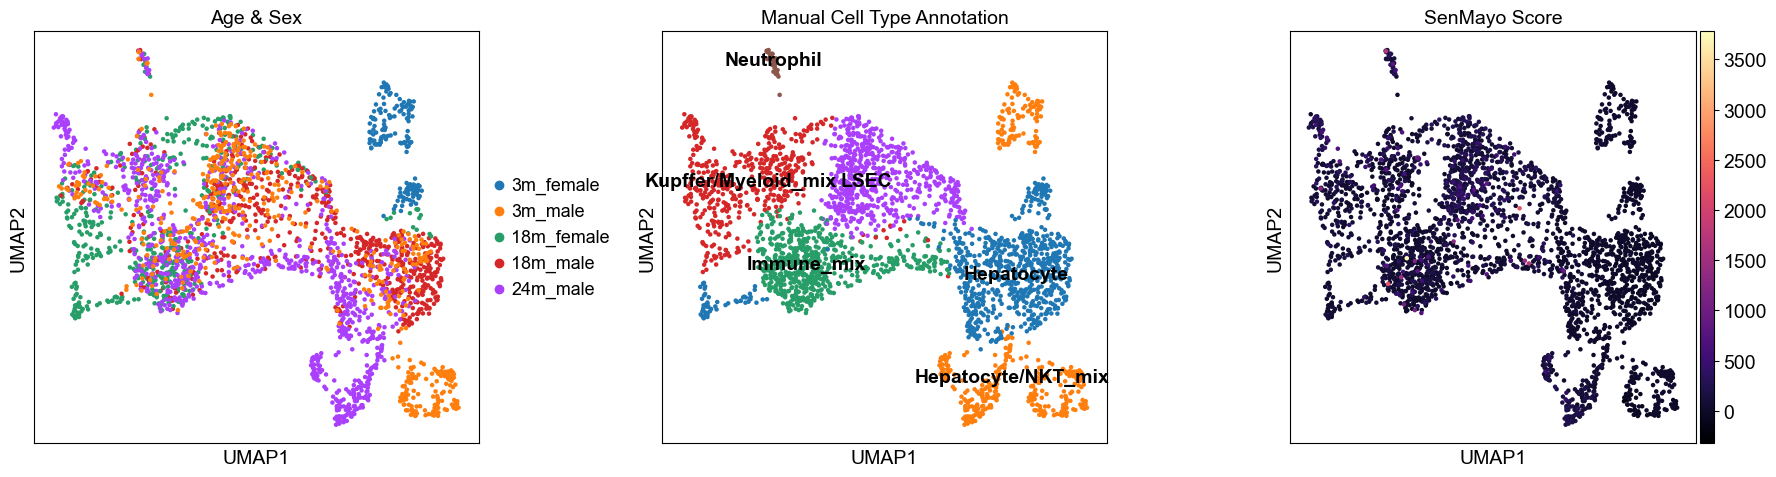

In [9]:
# Visualize
# 1. Create a figure and a 1x3 grid of subplots (one row, three columns).
# We'll make the figure wider to accommodate the side-by-side plots.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2. Plot each UMAP on a specific subplot (ax).
# The 'axes' object is now a simple list, so we access subplots with a single index.
# We use show=False to prevent each plot from displaying individually.

# First plot (left): Age and Sex
sc.pl.umap(
    adata,
    color='age_sex',
    ax=axes[0], # Target the first subplot
    show=False,
    legend_loc='right margin', # Legend on the right
    title='Age & Sex'
)

# Second plot (middle): Manual cell type annotation
sc.pl.umap(
    adata,
    color='cell_type',
    ax=axes[1], # Target the second subplot
    show=False,
    legend_loc='on data',
    title='Manual Cell Type Annotation'
)

# Third plot (right): SenMayo score
sc.pl.umap(
    adata,
    color='SenMayo_score',
    ax=axes[2], # Target the third subplot
    show=False,
    cmap='magma',
    title='SenMayo Score'
)

# 3. Adjust spacing and display the final composite figure
plt.tight_layout()
plt.show()

The SenMayo_score calculated indicates the degree to which individual cells in the dataset express a gene signature associated with cellular senescence. In short, it's a per-cell measurement of a specific aging-related biological process.

Here we can see that basically the majority of the cell population is categorized with a low to negative senescence score. This is a biologically expected finding, as senescent cells are typically a rare population in healthy or moderately aged tissues. And it is known that the efficacy of senescent signatures, particularly those developed in vitro on different species, is not the best at identifying in vivo senescence.

There is a scattered group of very low scored cells in the LSEC cluster, and really throughout the whole UMAP, possibly belonging to the 3 month male indicated by the dim green and yellow colors. 

According to the SenMayo researchers the score of each cell is not statistically significant. What is is its comparison between each other, for example the comparison of scores through time. Something that I've done downstream. But the absolute score is still a visually informative point when compared between all cells to emphasize the difficulty of characterizing senescence in vivo.

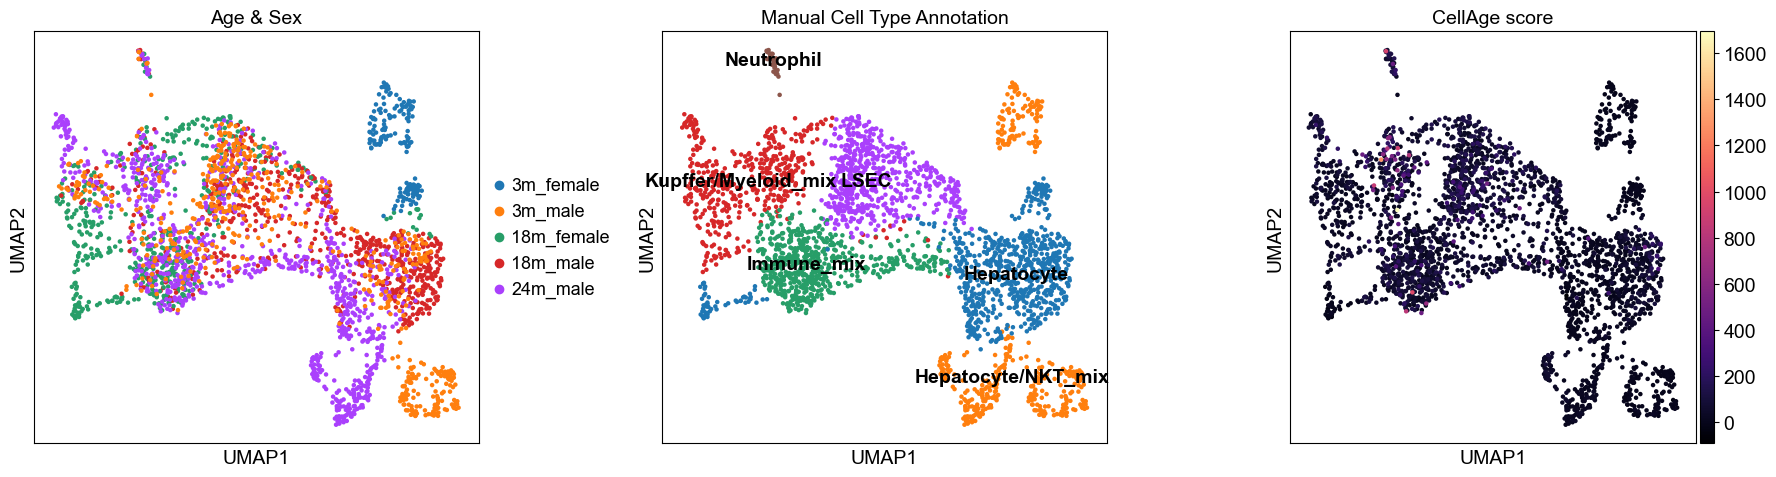

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2. Plot each UMAP on a specific subplot (ax).
# The 'axes' object is now a simple list, so we access subplots with a single index.
# We use show=False to prevent each plot from displaying individually.

# First plot (left): Age and Sex
sc.pl.umap(
    adata,
    color='age_sex',
    ax=axes[0], # Target the first subplot
    show=False,
    legend_loc='right margin', # Legend on the right
    title='Age & Sex'
)

# Second plot (middle): Manual cell type annotation
sc.pl.umap(
    adata,
    color='cell_type',
    ax=axes[1], # Target the second subplot
    show=False,
    legend_loc='on data',
    title='Manual Cell Type Annotation'
)

# Third plot (right): SenMayo score
sc.pl.umap(
    adata,
    color='CellAge_up_score',
    ax=axes[2], # Target the third subplot
    show=False,
    cmap='magma',
    title='CellAge score'
)

# 3. Adjust spacing and display the final composite figure
plt.tight_layout()
plt.show()


The code reports this: 

39 input query terms found dup hits: This means some human genes (like ATF6) have multiple potential mouse orthologs. mygene reports this ambiguity.

1 input query terms found no hit: ['PHB']: The tool could not find a confident mouse ortholog for the human gene PHB.

There are also 20 genes missing. This is normal since this gene set is much larger than the SenMayo set, where only 2 genes were missing, when comparing it to my liver data.

Here we can see a plot very similar to the SenMayo plot, with perhaps more cells with a higher score than before. 

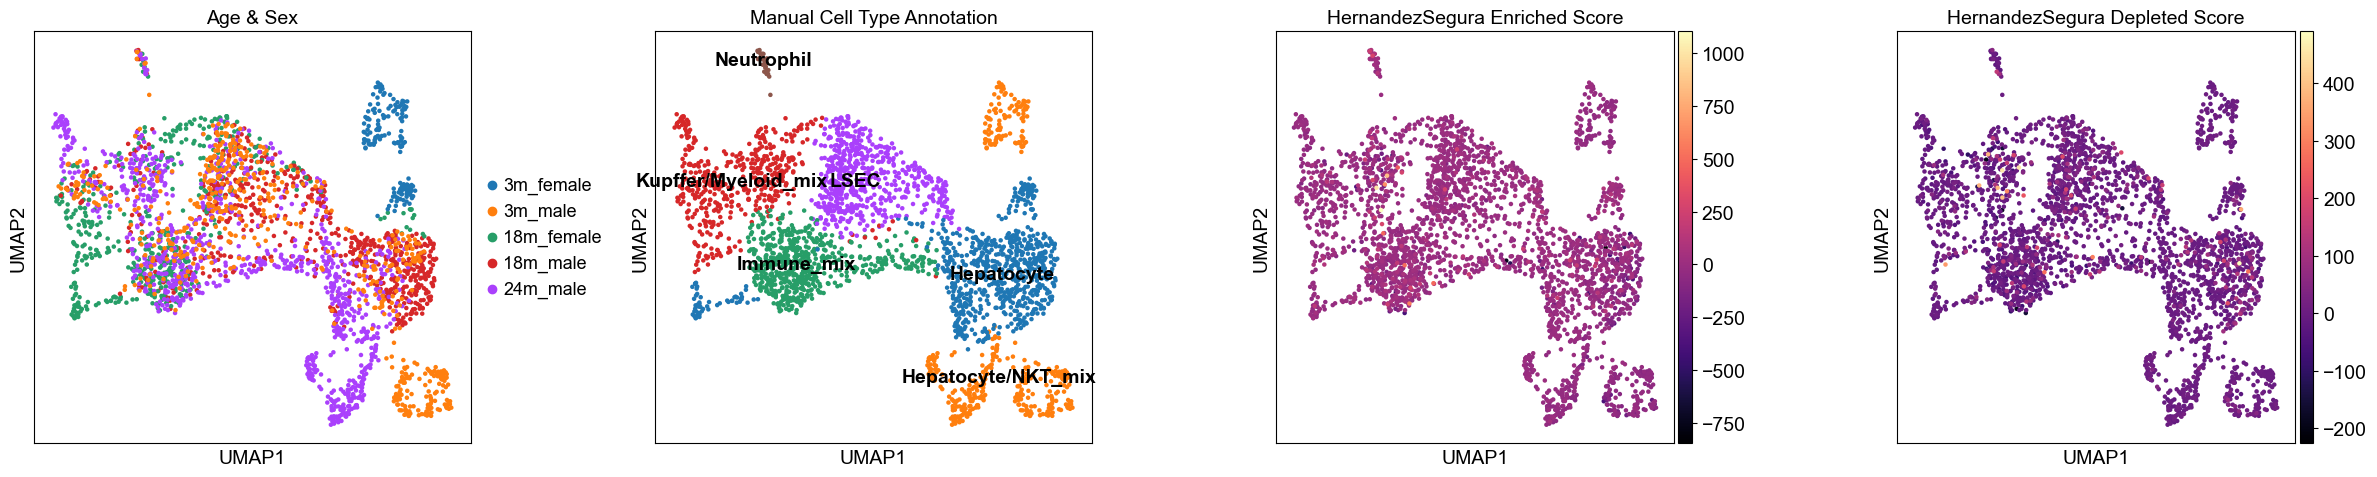

In [11]:
# 1. Create a figure with 4 subplots in a single row.
# Increased the figsize width to accommodate the extra plot.
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# 2. Plot each UMAP on its specific subplot (ax).

# First plot (left): Age and Sex
sc.pl.umap(
    adata,
    color='age_sex',
    ax=axes[0],
    show=False,
    legend_loc='right margin',
    title='Age & Sex'
)

# Second plot (middle-left): Manual cell type annotation
sc.pl.umap(
    adata,
    color='cell_type',
    ax=axes[1],
    show=False,
    # 'on data' can get crowded, 'right margin' might be better if you have many types.
    legend_loc='on data', 
    title='Manual Cell Type Annotation'
)

# Third plot (middle-right): HernandezSegura Enriched Score
sc.pl.umap(
    adata,
    color='HernandezSegura_enriched_score', # Plot only the enriched score here
    ax=axes[2],
    show=False,
    cmap='magma', # 'viridis' is a good choice for continuous scores
    title='HernandezSegura Enriched Score' # Corrected title
)

# Fourth plot (right): HernandezSegura Depleted Score
sc.pl.umap(
    adata,
    color='HernandezSegura_depleted_score', # Plot only the depleted score here
    ax=axes[3],
    show=False,
    cmap='magma',
    title='HernandezSegura Depleted Score'
)

# 3. Adjust spacing and display the final composite figure.
plt.tight_layout()
plt.show()

I want to compare senescence score distribution between young and old cells.

Loading Liver Atlas...


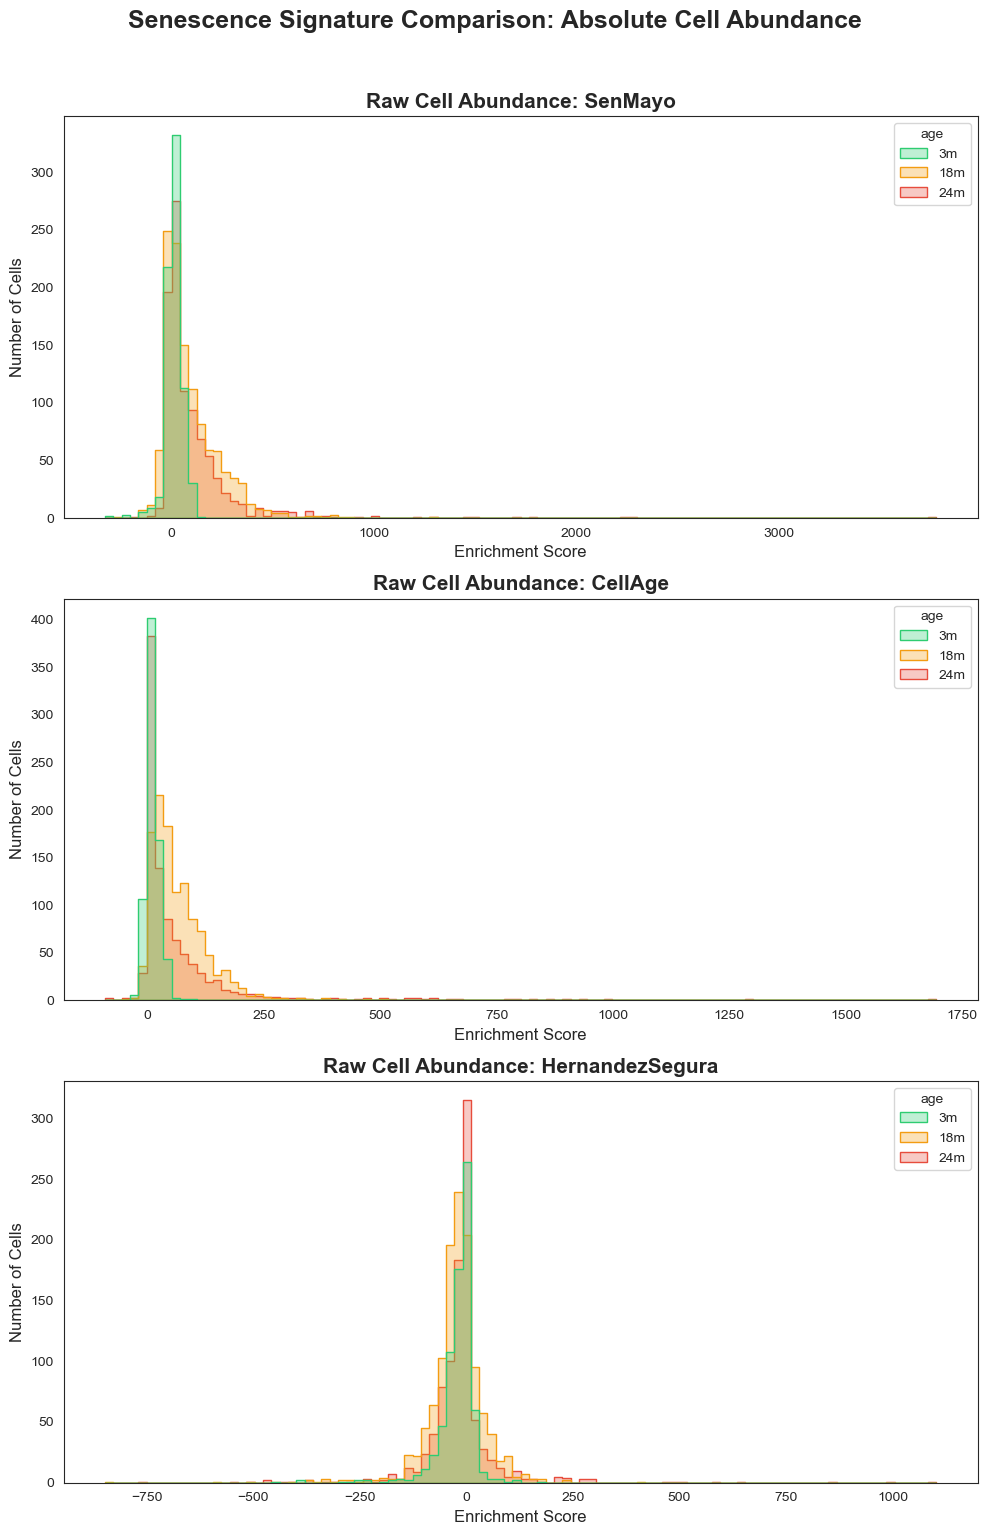


--- Total cells per age group in this analysis ---
age
3m      731
18m    1180
24m     947
Name: count, dtype: int64


In [3]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA
print("Loading Liver Atlas...")
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad")

# 2. DEFINE COLUMNS AND ORDER
score_cols = [
    'SenMayo_score', 
    'CellAge_up_score', 
    'HernandezSegura_enriched_score'
]

age_order = ['3m', '18m', '24m']
palette = {'3m': '#2ecc71', '18m': '#f39c12', '24m': '#e74c3c'}

# Filter data
df_plot = adata.obs[adata.obs['age'].isin(age_order)].copy()

# 3. CREATE VERTICAL STACKED HISTOGRAMS (RAW COUNTS)
fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=False)
sns.set_style("white")

for i, score in enumerate(score_cols):
    ax = axes[i]
    
    # We use histplot with element="step" to make it look like a curve but based on counts
    sns.histplot(
        data=df_plot, 
        x=score, 
        hue='age', 
        hue_order=age_order,
        palette=palette,
        element="step",  # Outline style for easier overlap viewing
        fill=True,
        alpha=0.3,
        bins=100,        # Higher number of bins for single-cell resolution
        ax=ax
    )
    
    clean_name = score.replace('_score', '').replace('_up', '').replace('_enriched', '')
    ax.set_title(f"Raw Cell Abundance: {clean_name}", fontsize=15, fontweight='bold')
    ax.set_xlabel("Enrichment Score", fontsize=12)
    ax.set_ylabel("Number of Cells", fontsize=12) # This is the key difference

# Final layout adjustments
plt.suptitle("Senescence Signature Comparison: Absolute Cell Abundance", 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

# 4. SAVE
plt.savefig("Senescence_Scores_Vertical_Counts.png", dpi=300, bbox_inches='tight')
plt.show()

# 5. PRINT COUNTS FOR CONTEXT
print("\n--- Total cells per age group in this analysis ---")
print(df_plot['age'].value_counts().reindex(age_order))

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import mygene

# 1. LOAD DATA
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad")

# 2. DEFINE SIGNATURES TO TEST
sigs = {
    "SenMayo": "SenMayo_score",
    "CellAge": "CellAge_up_score",
    "Hernandez": "HernandezSegura_enriched_score"
}

mg = mygene.MyGeneInfo()
summary_report = {}

print("--- Starting Comparative Tail Analysis ---\n")

for label, col_name in sigs.items():
    print(f"Analyzing {label}...")
    
    # A. Find Thresholds (Max AND Min for Young cells)
    young_subset = adata[adata.obs['age'] == '3m'].obs[col_name]
    max_young = young_subset.max()
    min_young = young_subset.min()
    
    # B. Isolate Old Outliers (18m/24m)
    # ALTERATION: For Hernandez, we take both tails. For others, just the top tail.
    if label == "Hernandez":
        outlier_mask = (adata.obs['age'].isin(['18m', '24m'])) & \
                       ((adata.obs[col_name] > max_young) | (adata.obs[col_name] < min_young))
    else:
        outlier_mask = (adata.obs['age'].isin(['18m', '24m'])) & (adata.obs[col_name] > max_young)
    
    outliers = adata[outlier_mask].copy()
    num_outliers = outliers.n_obs
    print(f"  - Young Range: [{min_young:.2f} to {max_young:.2f}]")
    print(f"  - Number of 'Pure Old' Outliers: {num_outliers}")
    
    if num_outliers > 0:
        # C. Identify Top 10 Expressed Genes
        exp_matrix = outliers.X.toarray() if hasattr(outliers.X, "toarray") else outliers.X
        mean_exp = np.mean(exp_matrix, axis=0)
        gene_ranking = pd.Series(mean_exp, index=adata.var_names).sort_values(ascending=False).head(10)
        
        # D. Translate IDs
        clean_ids = [str(i).split('.')[0] for i in gene_ranking.index]
        res = mg.querymany(clean_ids, scopes='ensembl.gene', fields='symbol', species='mouse', verbose=False)
        symbol_map = {r['query']: r.get('symbol', r['query']) for r in res if 'notfound' not in r}
        top_symbols = [symbol_map.get(str(idx).split('.')[0], idx) for idx in gene_ranking.index]
        
        # E. Get Cell Type Distribution
        ct_dist = outliers.obs['cell_ontology_class'].value_counts().head(5)
        
        summary_report[label] = {
            'threshold': f"<{min_young:.1f} or >{max_young:.1f}" if label == "Hernandez" else f">{max_young:.1f}",
            'count': num_outliers,
            'top_genes': top_symbols,
            'top_cell_types': ct_dist.to_dict()
        }

# 3. PRINT CONSOLIDATED COMPARISON
print("\n" + "="*50)
print("FINAL COMPARISON: SENESCENCE SIGNATURE BIAS")
print("="*50)

for label, data in summary_report.items():
    print(f"\nSIGNATURE: {label}")
    print(f"Outlier Criteria: {data['threshold']}")
    print(f"Unique 'Old' Outliers: {data['count']}")
    print(f"Top Cell Types in Tail: {list(data['top_cell_types'].keys())}")
    print(f"Top Expressed Genes: {', '.join(data['top_genes'])}")
    print("-" * 30)

# Final Tagging block (Updated with the same two-sided logic for Hernandez)
adata.obs['is_senescence_outlier'] = False
for label, col_name in sigs.items():
    y_scores = adata[adata.obs['age'] == '3m'].obs[col_name]
    max_y, min_y = y_scores.max(), y_scores.min()
    
    if label == "Hernandez":
        mask = (adata.obs['age'].isin(['18m', '24m'])) & ((adata.obs[col_name] > max_y) | (adata.obs[col_name] < min_y))
    else:
        mask = (adata.obs['age'].isin(['18m', '24m'])) & (adata.obs[col_name] > max_y)
        
    adata.obs.loc[mask, 'is_senescence_outlier'] = True

adata.write("Liver_Atlas_with_TwoTailed_Outliers.h5ad")

Input sequence provided is already in string format. No operation performed


--- Starting Comparative Tail Analysis ---

Analyzing SenMayo...
  - Young Range: [-324.58 to 132.53]
  - Number of 'Pure Old' Outliers: 583


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Analyzing CellAge...
  - Young Range: [-32.71 to 93.62]
  - Number of 'Pure Old' Outliers: 474


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Analyzing Hernandez...
  - Young Range: [-443.08 to 183.02]
  - Number of 'Pure Old' Outliers: 35

FINAL COMPARISON: SENESCENCE SIGNATURE BIAS

SIGNATURE: SenMayo
Outlier Criteria: >132.5
Unique 'Old' Outliers: 583
Top Cell Types in Tail: ['endothelial cell of hepatic sinusoid', 'Kupffer cell', 'hepatocyte', 'myeloid leukocyte', 'CD8-positive, alpha-beta T cell']
Top Expressed Genes: CLDN5, CD300LG, PRICKLE1, TMEM106A, GM7609, FLT4, GPR77, TCN2, NPR1, TINAGL1
------------------------------

SIGNATURE: CellAge
Outlier Criteria: >93.6
Unique 'Old' Outliers: 474
Top Cell Types in Tail: ['endothelial cell of hepatic sinusoid', 'myeloid leukocyte', 'hepatocyte', 'mature NK T cell', 'Kupffer cell']
Top Expressed Genes: GM7609, CBFA2T3, CD300LG, ANXA2, FCGR2B, CLDN5, TMEM106A, MALAT1, NCOA3, GPR77
------------------------------

SIGNATURE: Hernandez
Outlier Criteria: <-443.1 or >183.0
Unique 'Old' Outliers: 35
Top Cell Types in Tail: ['myeloid leukocyte', 'hepatocyte', 'mature NK T cell', 'CD

Our comparative analysis of three independent senescence signatures (SenMayo, CellAge, and Hernandez-Segura) reveals a fundamental lack of specificity and sensitivity in the liver. While SenMayo and CellAge identified a large number of aged 'outliers,' these populations were dominated by sinusoidal endothelial cells, and their top-expressed genes were structural vascular markers (CLDN5, CD300LG) rather than cell-cycle arrest markers (p16, p21).
Conversely, the Hernandez-Segura signature proved highly insensitive, capturing only 26 cells across the entire dataset, mostly myeloid in origin.
This collective underperformance demonstrates that expression-based senescence signatures are confounded by baseline cell-type identity in the liver. These results provide a strong scientific mandate for our Splicing Analysis, which bypasses these biased signaling pathways to identify aging through the fundamental breakdown of the cell's post-transcriptional machinery.

C:\Users\lukas\AppData\Local\Temp\ipykernel_4136\897885827.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_means = adata_young.obs.groupby('cell_ontology_class')[score_cols].mean()


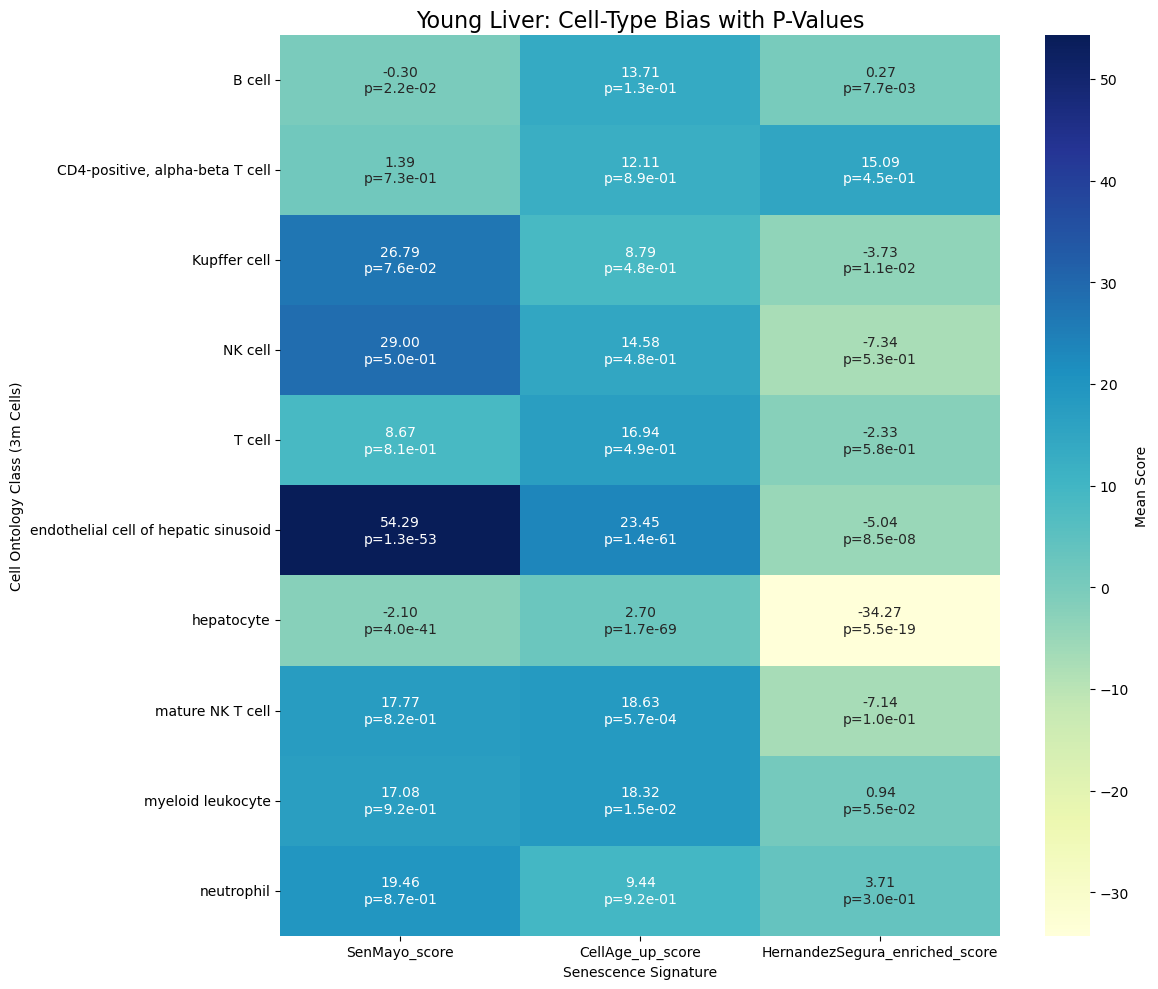

SenMayo_score Global ANOVA P-Value: 2.64e-54
CellAge_up_score Global ANOVA P-Value: 8.91e-79
HernandezSegura_enriched_score Global ANOVA P-Value: 1.68e-13


In [6]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind
import numpy as np

# 1. LOAD DATA
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad")
score_cols = ['SenMayo_score', 'CellAge_up_score', 'HernandezSegura_enriched_score']
adata_young = adata[adata.obs['age'] == '3m'].copy()

# 2. PREPARE DATA AND STATS
# Calculate means
type_means = adata_young.obs.groupby('cell_ontology_class')[score_cols].mean()

# Create a matching matrix for P-Values
p_values_matrix = pd.DataFrame(index=type_means.index, columns=type_means.columns)
annot_matrix = pd.DataFrame(index=type_means.index, columns=type_means.columns)

for score in score_cols:
    for ct in type_means.index:
        # Get values for this cell type vs all others
        target = adata_young.obs[adata_young.obs['cell_ontology_class'] == ct][score]
        others = adata_young.obs[adata_young.obs['cell_ontology_class'] != ct][score]
        
        # Calculate p-value (t-test)
        _, p_val = ttest_ind(target, others)
        
        # Create a label string: "Mean Value \n p=0.00e+00"
        mean_val = type_means.loc[ct, score]
        annot_matrix.loc[ct, score] = f"{mean_val:.2f}\np={p_val:.1e}"

# 3. VISUALIZE (Using the style from your first code)
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    type_means, 
    annot=annot_matrix, # THIS PUTS P-VALUES IN THE BOXES
    fmt="",             # Required for string annotations
    cmap="YlGnBu", 
    cbar_kws={'label': 'Mean Score'},
    ax=ax
)

# --- Template Style: Manually setting titles and labels ---
ax.set_title("Young Liver: Cell-Type Bias with P-Values", fontsize=16)
ax.set_ylabel("Cell Ontology Class (3m Cells)")
ax.set_xlabel("Senescence Signature")

plt.tight_layout()
plt.show()

# 4. ANOVA (Global check for your terminal)
for score in score_cols:
    groups = [adata_young.obs[adata_young.obs['cell_ontology_class'] == ct][score].values 
              for ct in type_means.index]
    _, p_anova = f_oneway(*groups)
    print(f"{score} Global ANOVA P-Value: {p_anova:.2e}")

We evaluated the specificity of three prominent senescence signatures (SenMayo, CellAge, Hernandez-Segura) within the liver environment. By analyzing healthy 3-month-old cells, we identified a profound cell-type bias that undermines signature performance.
As shown in the heatmap, Endothelial cells and Kupffer cells exhibit high baseline scores (false positives) compared to Hepatocytes, even in a young, non-senescent state. Statistical analysis confirmed that the primary driver of signature variance is cell-type identity rather than cellular state (p<10−50 for SenMayo and CellAge).
This underperformance justifies our shift toward Splicing Analysis, which provides a more robust, cell-type-independent measure of cellular aging that is not confounded by baseline signaling pathways

--- Analyzing Signature Bias in Aged Cells (18m & 24m) ---


C:\Users\lukas\AppData\Local\Temp\ipykernel_4136\3601230163.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  old_type_means = adata_old.obs.groupby('cell_ontology_class')[score_cols].mean()


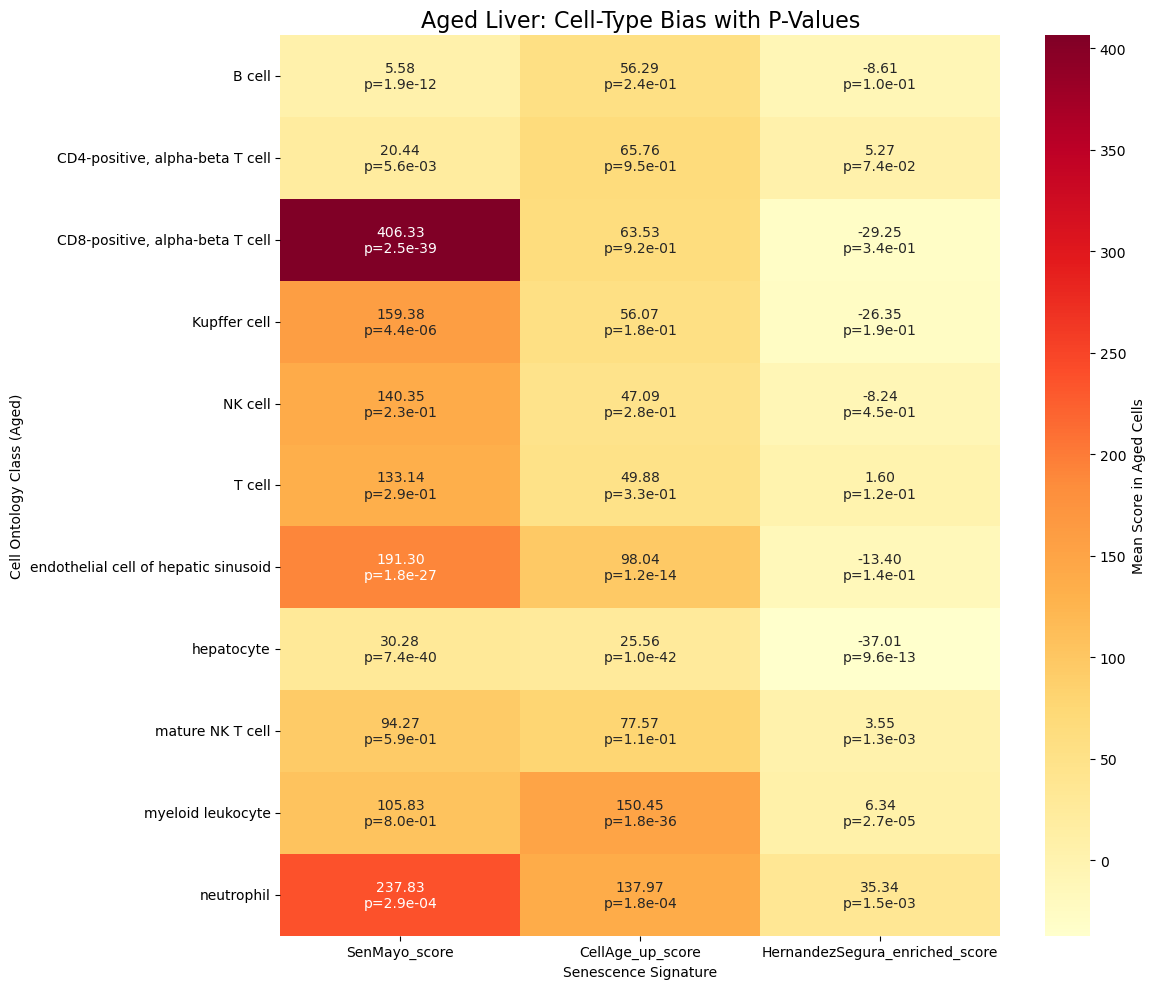


--- ANOVA Results: Is global variance driven by Cell Type in the Aged group? ---
Signature SenMayo_score: Global ANOVA p = 3.39e-101
  - STATUS: HIGH BIAS. Signature is significantly confounded by cell identity.
Signature CellAge_up_score: Global ANOVA p = 5.08e-69
  - STATUS: HIGH BIAS. Signature is significantly confounded by cell identity.
Signature HernandezSegura_enriched_score: Global ANOVA p = 2.12e-13
  - STATUS: HIGH BIAS. Signature is significantly confounded by cell identity.


In [7]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind

# 1. LOAD DATA
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad")

# 2. DEFINE SIGNATURE COLUMNS & SUBSET
score_cols = ['SenMayo_score', 'CellAge_up_score', 'HernandezSegura_enriched_score']
print("--- Analyzing Signature Bias in Aged Cells (18m & 24m) ---")
adata_old = adata[adata.obs['age'].isin(['18m', '24m'])].copy()

# 3. PREPARE MEANS AND P-VALUE ANNOTATIONS
# Calculate average score per cell type
old_type_means = adata_old.obs.groupby('cell_ontology_class')[score_cols].mean()

# Create a matrix to hold the text labels (Mean + P-value)
annot_matrix = pd.DataFrame(index=old_type_means.index, columns=old_type_means.columns)

for score in score_cols:
    for ct in old_type_means.index:
        # Values for the current cell type vs all other aged cells
        target = adata_old.obs[adata_old.obs['cell_ontology_class'] == ct][score]
        others = adata_old.obs[adata_old.obs['cell_ontology_class'] != ct][score]
        
        # Calculate p-value (Is this specific cell type an outlier in the aged group?)
        _, p_val = ttest_ind(target, others)
        
        # Combine Mean and P-value into a string for the heatmap box
        mean_val = old_type_means.loc[ct, score]
        annot_matrix.loc[ct, score] = f"{mean_val:.2f}\np={p_val:.1e}"

# 4. VISUALIZE BIAS IN OLD CELLS (Heatmap with P-values)
plt.figure(figsize=(12, 10))
sns.heatmap(
    old_type_means, 
    annot=annot_matrix, 
    fmt="",              # fmt="" is required because we are passing strings
    cmap="YlOrRd", 
    cbar_kws={'label': 'Mean Score in Aged Cells'}
)

plt.title("Aged Liver: Cell-Type Bias with P-Values", fontsize=16)
plt.ylabel("Cell Ontology Class (Aged)")
plt.xlabel("Senescence Signature")
plt.tight_layout()
plt.savefig("Aged_CellType_Bias_Pval_Heatmap.png", dpi=300)
plt.show()

# 5. QUANTIFY GLOBAL BIAS (ANOVA)
print("\n--- ANOVA Results: Is global variance driven by Cell Type in the Aged group? ---")
for score in score_cols:
    valid_types = adata_old.obs['cell_ontology_class'].value_counts()
    keep_types = valid_types[valid_types > 5].index
    
    groups = [adata_old.obs[adata_old.obs['cell_ontology_class'] == ct][score].values 
              for ct in keep_types]
    
    f_stat, p_val = f_oneway(*groups)
    
    print(f"Signature {score}: Global ANOVA p = {p_val:.2e}")
    if p_val < 0.05:
        print(f"  - STATUS: HIGH BIAS. Signature is significantly confounded by cell identity.")
    else:
        print(f"  - STATUS: NEUTRAL. Score is independent of cell identity.")

ANOVA allows you to look at all cell types simultaneously and ask: "Is the average senescence score the same across all these identities, or does it vary significantly depending on which cell type we are looking at?"

SenMayo is heavy on SASP (Senescence-Associated Secretory Phenotype) factors. These are signaling molecules (cytokines, chemokines, adhesion molecules). Immune cells and Endothelial cells produce these as part of their normal job, which is why SenMayo "triggers" so easily on them.
CellAge was built using genes from the Human Ageing Genomic Resources (HAGR), focusing more on cell-cycle regulation and longevity-associated genes (Tp53, Rb1, Cdkn2a). Since every cell has a cell cycle and basic tumor-suppressor machinery, the baseline "noise" is more evenly distributed across the liver

Loading the liver data file...

Generating violin plot for: SenMayo_score


C:\Users\lukas\AppData\Local\Temp\ipykernel_13160\1753431581.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Adjusts plot parameters for a tight layout


<Figure size 800x400 with 0 Axes>

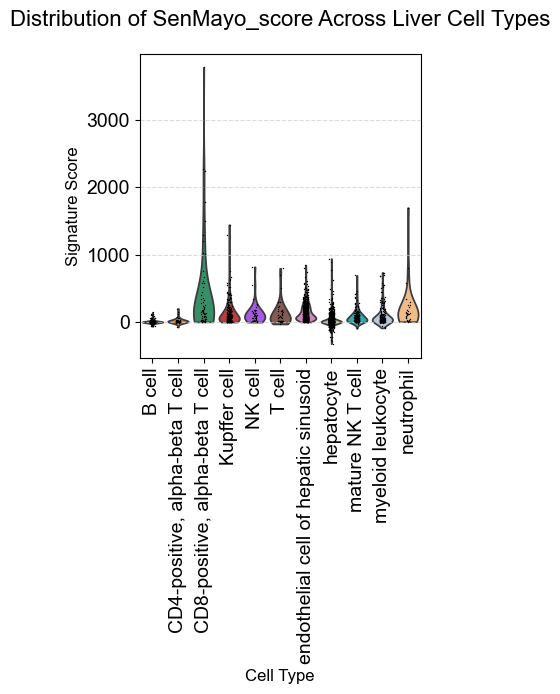


Generating violin plot for: CellAge_up_score


C:\Users\lukas\AppData\Local\Temp\ipykernel_13160\1753431581.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Adjusts plot parameters for a tight layout


<Figure size 800x400 with 0 Axes>

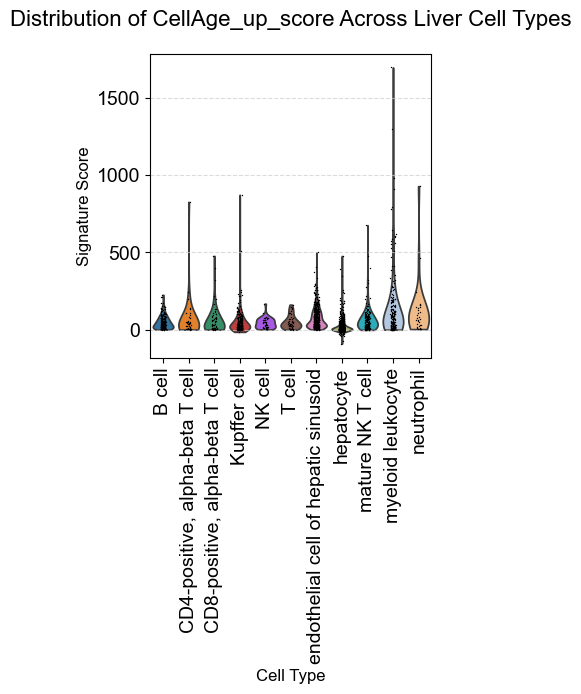


Generating violin plot for: HernandezSegura_enriched_score


C:\Users\lukas\AppData\Local\Temp\ipykernel_13160\1753431581.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Adjusts plot parameters for a tight layout


<Figure size 800x400 with 0 Axes>

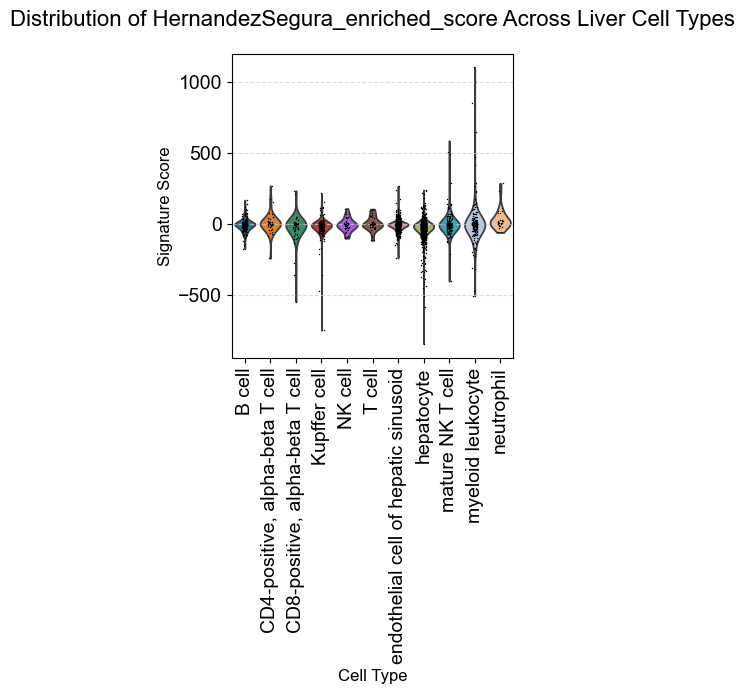


Generating violin plot for: HernandezSegura_depleted_score


C:\Users\lukas\AppData\Local\Temp\ipykernel_13160\1753431581.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Adjusts plot parameters for a tight layout


<Figure size 800x400 with 0 Axes>

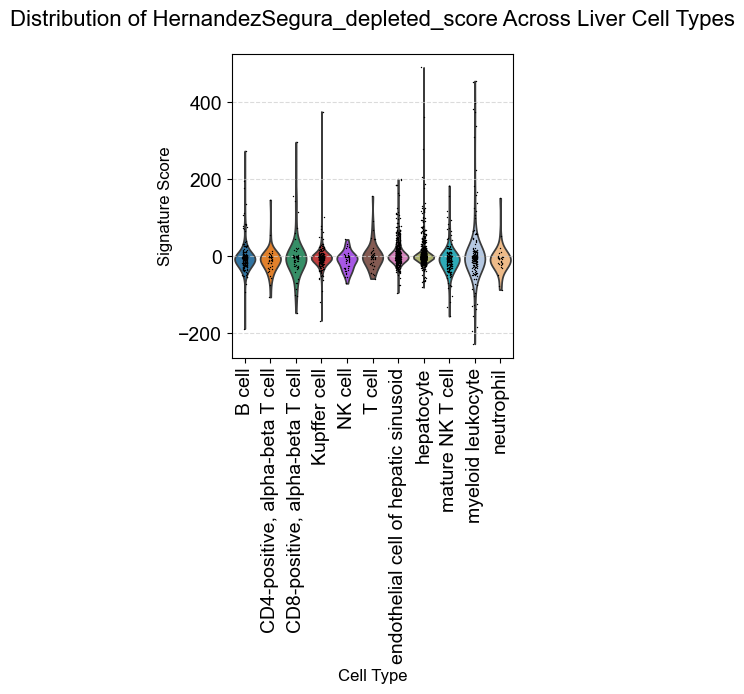

In [18]:
import scanpy as sc
import matplotlib.pyplot as plt

# ==============================================================================
# --- Step 1: Load the Liver AnnData object ---
# ==============================================================================
print("Loading the liver data file...")
# Load the specified h5ad file
adata_liver = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad")

# ==============================================================================
# --- Step 2: Define the senescence signatures to plot ---
# ==============================================================================
signatures = [
    'SenMayo_score',
    'CellAge_up_score',
    'HernandezSegura_enriched_score',
    'HernandezSegura_depleted_score'
]

# ==============================================================================
# --- Step 3: Generate a violin plot for each signature ---
# ==============================================================================

# We will loop through each signature and create a separate plot
for signature in signatures:
    print(f"\nGenerating violin plot for: {signature}")
    
    # Set the figure size for better readability
    plt.figure(figsize=(16, 8))
    
    # Use the Scanpy plotting function for violin plots
    # - `keys`: The score to plot on the y-axis.
    # - `groupby`: The category to group by on the x-axis.
    # - `rotation`: Rotates the x-axis labels (cell type names) to prevent overlap.
    sc.pl.violin(
        adata_liver,
        keys=signature,
        groupby='cell_ontology_class',
        rotation=90,
        show=False # We use show=False to prevent duplicate plotting, then call plt.show()
    )
    
    # Add a more descriptive title and improve layout
    plt.title(f'Distribution of {signature} Across Liver Cell Types', fontsize=16, pad=20)
    plt.xlabel('Cell Type', fontsize=12)
    plt.ylabel('Signature Score', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout() # Adjusts plot parameters for a tight layout
    
    # Display the plot
    plt.show()

Just to double check, I want to see if at least the same cells are being characterized as senescent by both senescent signatures.

In [19]:
# 1. Get descriptive statistics for each score
print("\nStatistics for SenMayo_score:")
print(adata.obs['SenMayo_score'].describe())

print("\nStatistics for CellAge_up_score:")
print(adata.obs['CellAge_up_score'].describe())

print("\nStatistics for HernandezSegura_combined_score:")
print(adata.obs['HernandezSegura_combined_score'].describe())


Statistics for SenMayo_score:
count    2858.000000
mean       80.413280
std       171.099791
min      -324.578194
25%         1.909231
50%        29.576941
75%       108.264624
max      3778.643187
Name: SenMayo_score, dtype: float64

Statistics for CellAge_up_score:
count    2858.000000
mean       50.789978
std        90.194227
min       -91.579133
25%         5.406867
50%        24.050039
75%        66.931189
max      1694.755844
Name: CellAge_up_score, dtype: float64

Statistics for HernandezSegura_combined_score:


KeyError: 'HernandezSegura_combined_score'

The logic for defining the thresholds:

My original code used thresholds like 500 or 100. The fundamental problem with this approach is: Those numbers have no connection to the actual data. As the above statistics show, the maximum SenMayo_score in the entire dataset is 3768.9, but the vast majority of cells are far lower. Choosing 500 was a guess, and it turned out to be too high to capture anything but the most extreme outliers.

The Solution: Data-Driven Thresholds using Percentiles 

Instead of guessing, we look at the distribution of the your scores and pick a logical cutoff. The most common and scientifically defensible way to do this is by using percentiles. The 75th percentile (shown as 75% in the stats) is the value for which 75% of the cells have a score below it. By definition, this means the remaining 25% of cells have a score above it.

Setting our threshold at or slightly above the 75th percentile gives us a clear, objective definition of a "high-scoring" cell: "a cell that is in the top 25% for this signature."

--- Defining consistent, data-driven thresholds for all analyses ---
Thresholds set: SenMayo > 108, CellAge > 67, Hernandez > 2.5

--- Counts and Ratios of Senescent Cells for Each Signature ---
For SenMayo: 715 of 2858 cells (25.02%) are identified as senescent.
For CellAge: 713 of 2858 cells (24.95%) are identified as senescent.
For Hernandez: 726 of 2858 cells (25.40%) are identified as senescent.
---------------------------------------------------------

--- Running Analysis of All Three Signatures ---

Cell Counts (3 Signatures):
senescence_category_3
Low in All              1474
High in 1 Signature      762
High in 2 Signatures     474
High in All 3            148
Name: count, dtype: int64
---------------------------------------------------------
Generating the UMAP plot...


<Figure size 1500x1500 with 0 Axes>

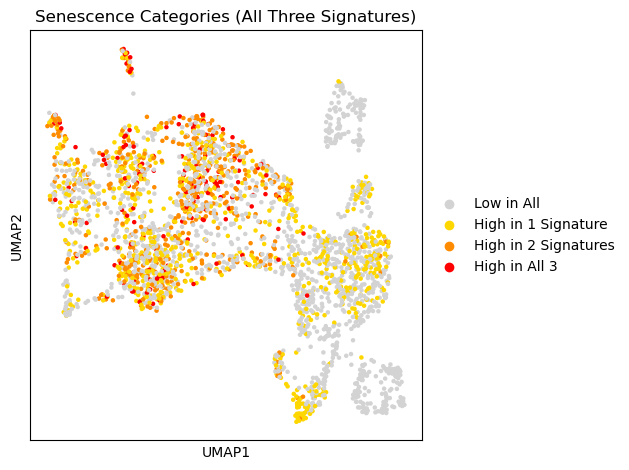


--- Saving the updated AnnData object with consistent flags ---
Successfully saved updated data to 'Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad'


In [ ]:
# --- Step 1: Load the data containing ALL scores ---
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad")

# ---------------------------------------------------------------------------
# --- PART 1: DEFINE DATA-DRIVEN PARAMETERS AND CREATE BOOLEAN FLAGS ---
# ---------------------------------------------------------------------------
print("--- Defining consistent, data-driven thresholds for all analyses ---")
senmayo_threshold = 108
cellage_threshold = 67
hernandez_threshold = 2.5

# Create the combined Hernandez score first
adata.obs['HernandezSegura_combined_score'] = adata.obs['HernandezSegura_enriched_score'] - adata.obs['HernandezSegura_depleted_score']

# Create and store a single set of boolean flags to be used everywhere
adata.obs['is_high_SenMayo'] = adata.obs['SenMayo_score'] > senmayo_threshold
adata.obs['is_high_CellAge'] = adata.obs['CellAge_up_score'] > cellage_threshold
adata.obs['is_high_Hernandez'] = adata.obs['HernandezSegura_combined_score'] > hernandez_threshold

print(f"Thresholds set: SenMayo > {senmayo_threshold}, CellAge > {cellage_threshold}, Hernandez > {hernandez_threshold}")

# --- MODIFICATION: EXPANDED THIS SECTION FOR CLARITY ---
print("\n--- Counts and Ratios of Senescent Cells for Each Signature ---")
total_cells = adata.n_obs

signatures_to_check = {
    "SenMayo": "is_high_SenMayo",
    "CellAge": "is_high_CellAge",
    "Hernandez": "is_high_Hernandez"
}

for name, column in signatures_to_check.items():
    # 1. Get the count of high-scoring cells (senescent)
    count_senescent = adata.obs[column].sum()
    
    # 2. Calculate the percentage
    percentage = (count_senescent / total_cells) * 100
    
    # 3. Print the formatted result
    print(f"For {name}: {count_senescent} of {total_cells} cells ({percentage:.2f}%) are identified as senescent.")

print("---------------------------------------------------------")


# ---------------------------------------------------------------------------
# --- PART 2: ANALYSIS of All Three Signatures ---
# ---------------------------------------------------------------------------
print("\n--- Running Analysis of All Three Signatures ---")

# Use the boolean flags to sum the conditions met by each cell
sum_of_conditions = adata.obs['is_high_SenMayo'].astype(int) + \
                    adata.obs['is_high_CellAge'].astype(int) + \
                    adata.obs['is_high_Hernandez'].astype(int)

# Create the 3-signature categorical column
adata.obs['senescence_category_3'] = 'Low in All'
adata.obs.loc[sum_of_conditions == 1, 'senescence_category_3'] = 'High in 1 Signature'
adata.obs.loc[sum_of_conditions == 2, 'senescence_category_3'] = 'High in 2 Signatures'
adata.obs.loc[sum_of_conditions == 3, 'senescence_category_3'] = 'High in All 3'

adata.obs['senescence_category_3'] = pd.Categorical(
    adata.obs['senescence_category_3'],
    categories=['Low in All', 'High in 1 Signature', 'High in 2 Signatures', 'High in All 3'], ordered=True)

print("\nCell Counts (3 Signatures):")
print(adata.obs['senescence_category_3'].value_counts())
print("---------------------------------------------------------")

# Visualize the 3-score categories on a UMAP plot
print("Generating the UMAP plot...")
plt.figure(figsize=(15, 15))
sc.pl.umap(adata, color='senescence_category_3', title='Senescence Categories (All Three Signatures)',
           palette={'Low in All': 'lightgrey', 'High in 1 Signature': 'gold', 'High in 2 Signatures': 'darkorange', 'High in All 3': 'red'}, show=False)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# --- PART 3: SAVE THE FINAL ANNDATA OBJECT ---
# ---------------------------------------------------------------------------
print("\n--- Saving the updated AnnData object with consistent flags ---")
output_filename = "Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad"
adata.write_h5ad(output_filename)
print(f"Successfully saved updated data to '{output_filename}'")

--- Venn Diagram Segment Sizes ---
High in SenMayo ONLY: 195
High in CellAge ONLY: 144
High in Hernandez-Segura ONLY: 430
High in SenMayo & CellAge ONLY: 319
High in SenMayo & Hernandez-Segura ONLY: 57
High in CellAge & Hernandez-Segura ONLY: 101
High in ALL THREE: 149
-----------------------------------


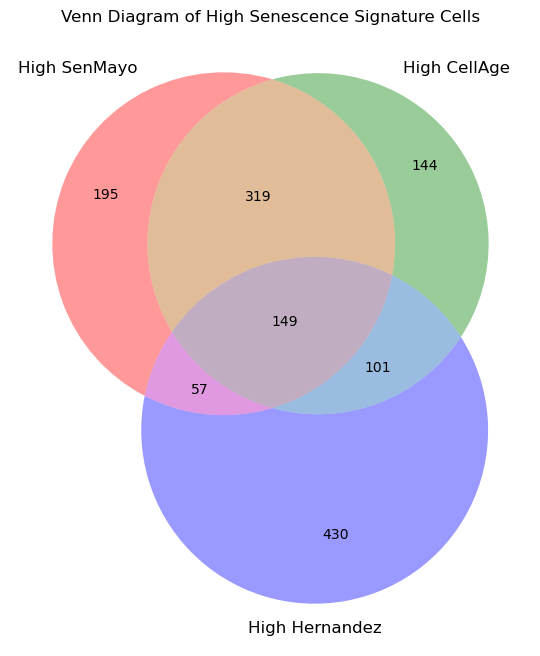

In [ ]:
# --- Step 1: Load the data ---
# This assumes 'adata' is loaded as in your script.
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad")

# --- Step 2: Define thresholds and create boolean flags ---
# Using the same definitions from your script
senmayo_threshold = 107
cellage_threshold = 67
hernandez_threshold = 2

adata.obs['HernandezSegura_combined_score'] = adata.obs['HernandezSegura_enriched_score'] - adata.obs['HernandezSegura_depleted_score']

adata.obs['is_high_SenMayo'] = adata.obs['SenMayo_score'] > senmayo_threshold
adata.obs['is_high_CellAge'] = adata.obs['CellAge_up_score'] > cellage_threshold
adata.obs['is_high_Hernandez'] = adata.obs['HernandezSegura_combined_score'] > hernandez_threshold

# --- Step 3: Calculate the sizes for EACH Venn diagram segment ---
# Let's create boolean Series for clarity
high_S = adata.obs['is_high_SenMayo']
high_C = adata.obs['is_high_CellAge']
high_H = adata.obs['is_high_Hernandez']

# Calculate the number of cells in each of the 7 mutually exclusive regions
# Note: '~' is the boolean NOT operator
# Abc: high_S=True,  high_C=False, high_H=False (SenMayo ONLY)
s_only = (high_S & ~high_C & ~high_H).sum()
# aBc: high_S=False, high_C=True,  high_H=False (CellAge ONLY)
c_only = (~high_S & high_C & ~high_H).sum()
# abC: high_S=False, high_C=False, high_H=True  (Hernandez ONLY)
h_only = (~high_S & ~high_C & high_H).sum()

# ABc: high_S=True,  high_C=True,  high_H=False (SenMayo and CellAge)
sc_only = (high_S & high_C & ~high_H).sum()
# AbC: high_S=True,  high_C=False, high_H=True  (SenMayo and Hernandez)
sh_only = (high_S & ~high_C & high_H).sum()
# aBC: high_S=False, high_C=True,  high_H=True  (CellAge and Hernandez)
ch_only = (~high_S & high_C & high_H).sum()

# ABC: high_S=True,  high_C=True,  high_H=True  (All Three)
all_three = (high_S & high_C & high_H).sum()

# --- DEBUGGING: Print the calculated sizes for each segment ---
print("--- Venn Diagram Segment Sizes ---")
print(f"High in SenMayo ONLY: {s_only}")
print(f"High in CellAge ONLY: {c_only}")
print(f"High in Hernandez-Segura ONLY: {h_only}")
print(f"High in SenMayo & CellAge ONLY: {sc_only}")
print(f"High in SenMayo & Hernandez-Segura ONLY: {sh_only}")
print(f"High in CellAge & Hernandez-Segura ONLY: {ch_only}")
print(f"High in ALL THREE: {all_three}")
print("-----------------------------------")


# --- Step 4: Create the Venn Diagram ---
# The venn3 function's 'subsets' argument takes a tuple of 7 values
# in a specific order: (Abc, aBc, ABc, abC, AbC, aBC, ABC)
plt.figure(figsize=(10, 8))
venn3(subsets=(s_only, c_only, sc_only, h_only, sh_only, ch_only, all_three),
      set_labels=('High SenMayo', 'High CellAge', 'High Hernandez'))
plt.title('Venn Diagram of High Senescence Signature Cells')
plt.show()

Here  we can see that from the whole dataset, the only cells that scored above 500/500/100 (thresholds) in the three signatures are devided by 137 cells from only one signature, 11 cells from two signatures, and 3 cells that are from the three signatures. These three cells show the best corroboration of their senescent nature. 

The counts could be misleading, since the counts for the cells with a high score of specific signatures do not add up to the high in one signature count seen later. The first sums up the total number of conditions met. If a single cell is high in both SenMayo and CellAge, it gets counted twice in this sum (once for SenMayo, once for CellAge). While the second works more intuitively with only the unique cells being counted.

But we can also see the large heterogeneity between the identification of senescence based on the different signatures, where the drop off from high in one signature to high in two and three signatures is very significant. All this could mean that these cells are less supported in their classification as they could be and that we should be more careful when deriving biological relevance from these cells, since they can actually not be senescent.

Besides this result demonstrates the lack of senescence prediction or, if the results are biologically relevant since I have not yet done a batch correction, the lack of senescent cells, it also demonstrates how much better SenMayo is than CellAge at identifying senescence, even though it is comprised of fewer marker genes (125 in comparison with 503 total). And how much better Hernandez Segura is than the other two signatures, possibly because of its composition of enriched and depleted genes. Although it should be noted that neither signature, SenMayo or Hernandez Segura, were built from mice or even the same tissue as the data that we are using so these scores have layers of biological meaning that could muddle the relevance.

By changing the thresholds to percentiles which are a more scientific fundamented reason, we see a huge increase in the amount of cells appear. This is due to the fact that these 75% percentiles are much lower thresholds than the first ones, which captured only the most extreme outliers. We also see that all three signatures identify a similar amount of senescent cells but the corroboration between these signatures is still of similar ratio to the original thresholds, where cell count drops significantly between one, two and three signatures where the same cell is classified.

Is this a better result? From an absolute count it is, but most of these cells have much weaker senescent signals than the "extreme outliers" so we should take them as senescent with a grain of salt. 

I now want to see if these "highly" correlated cells belong in fact to mice that are old, or at least older than 3 months, which is our starting sample.

In [ ]:
# --- Step 1: Load the data containing ALL scores and annotations ---
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad")

# ---------------------------------------------------------------------------
# --- SETUP: Define Parameters and Create Boolean Flags ---
# All setup is done once in this single, clean block.
# ---------------------------------------------------------------------------
print("--- Defining consistent thresholds based on FACS data statistics ---")

# Using thresholds based on the 75th percentile of the FACS data distribution.
senmayo_threshold = 108
cellage_threshold = 67
hernandez_threshold = 2

# Create the combined Hernandez score first, so we can use it for thresholding.
adata.obs['HernandezSegura_combined_score'] = adata.obs['HernandezSegura_enriched_score'] - adata.obs['HernandezSegura_depleted_score']

# Create and store a single set of boolean flags based on the correct thresholds.
adata.obs['is_high_SenMayo'] = adata.obs['SenMayo_score'] > senmayo_threshold
adata.obs['is_high_CellAge'] = adata.obs['CellAge_up_score'] > cellage_threshold
adata.obs['is_high_Hernandez'] = adata.obs['HernandezSegura_combined_score'] > hernandez_threshold

print(f"Thresholds set: SenMayo > {senmayo_threshold}, CellAge > {cellage_threshold}, Hernandez > {hernandez_threshold}")
print("-----------------------------------------------------------------\n")

# ---------------------------------------------------------------------------
# --- ANALYSIS: Crosstab for All Three Signatures ---
# Now we perform the analysis using the flags created above.
# ---------------------------------------------------------------------------
print("\n--- Running Crosstab for All Three Signatures ---")

# Use the boolean flags to sum the conditions met by each cell
sum_of_conditions = adata.obs['is_high_SenMayo'].astype(int) + \
                    adata.obs['is_high_CellAge'].astype(int) + \
                    adata.obs['is_high_Hernandez'].astype(int)

# Create the final categorical column for the 3-score comparison
adata.obs['senescence_category_3'] = 'Low in All'
adata.obs.loc[sum_of_conditions == 1, 'senescence_category_3'] = 'High in 1 Signature'
adata.obs.loc[sum_of_conditions == 2, 'senescence_category_3'] = 'High in 2 Signatures'
adata.obs.loc[sum_of_conditions == 3, 'senescence_category_3'] = 'High in All 3'

# --- Create and print the crosstab tables for the 3-score comparison ---
# Absolute counts
contingency_table_3 = pd.crosstab(
    adata.obs['age_sex'], 
    adata.obs['senescence_category_3']
)
print("\n--- Absolute Count of Cells (3 Signatures) ---")
print(contingency_table_3)
print("-----------------------------------------------\n")

# Normalized proportions (percentages)
proportion_table_3 = pd.crosstab(
    adata.obs['age_sex'], 
    adata.obs['senescence_category_3'], 
    normalize='index'
).multiply(100).round(2)
print("--- Normalized proportions of Cells (3 Signatures, within each age_sex group) ---")
print(proportion_table_3)
print("---------------------------------------------------------------------\n")

--- Defining consistent thresholds based on FACS data statistics ---
Thresholds set: SenMayo > 108, CellAge > 67, Hernandez > 2
-----------------------------------------------------------------


--- Running Crosstab for All Three Signatures ---

--- Absolute Count of Cells (3 Signatures) ---
senescence_category_3  High in 1 Signature  High in 2 Signatures  \
age_sex                                                            
3m_female                               26                     0   
3m_male                                147                     2   
18m_female                             175                   155   
18m_male                               156                   145   
24m_male                               265                   174   

senescence_category_3  High in All 3  Low in All  
age_sex                                           
3m_female                          0         135  
3m_male                            0         421  
18m_female               

Here we can see that the bigger proportion of cells characterized as senescent are from the 18 months mice onwards, with the biggest group of senescence associated with the 24 month mice. Even if the highest number of sampled cells belong to the 24 month old mice, the normalization makes the data significant. Also we can see a definite increase in cells classified as senescent with age. For example, the proportion of cells that were classified as senescent from a single signature (as a combination of the three signatures) increase with mice ages.  

So now we have identified a possible age related senescent signature in our data.

I want to check if the young, 3 months cells, have the expected low to near zero senescent scores that are expected in comparison to higher values for older, 18 to 24 months, cells.

Detected score columns for analysis: ['SenMayo_score', 'CellAge_up_score', 'HernandezSegura_enriched_score', 'HernandezSegura_depleted_score']

--- Signature Performance Report ---
                  Signature  ROC_AUC  Young_False_Pos_Rate (%)
0                   SenMayo    0.669                     18.19
1                CellAge_up    0.781                      3.56
2  HernandezSegura_enriched    0.485                     56.91
3  HernandezSegura_depleted    0.442                     58.00


C:\Users\lukas\AppData\Local\Temp\ipykernel_18420\1950129925.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='age_group_binary', y=score, ax=axes[i],
C:\Users\lukas\AppData\Local\Temp\ipykernel_18420\1950129925.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='age_group_binary', y=score, ax=axes[i],
C:\Users\lukas\AppData\Local\Temp\ipykernel_18420\1950129925.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='age_group_binary', y=score, ax=axes[i],
C:\Users\lukas\AppData\Local\Temp\ipyker

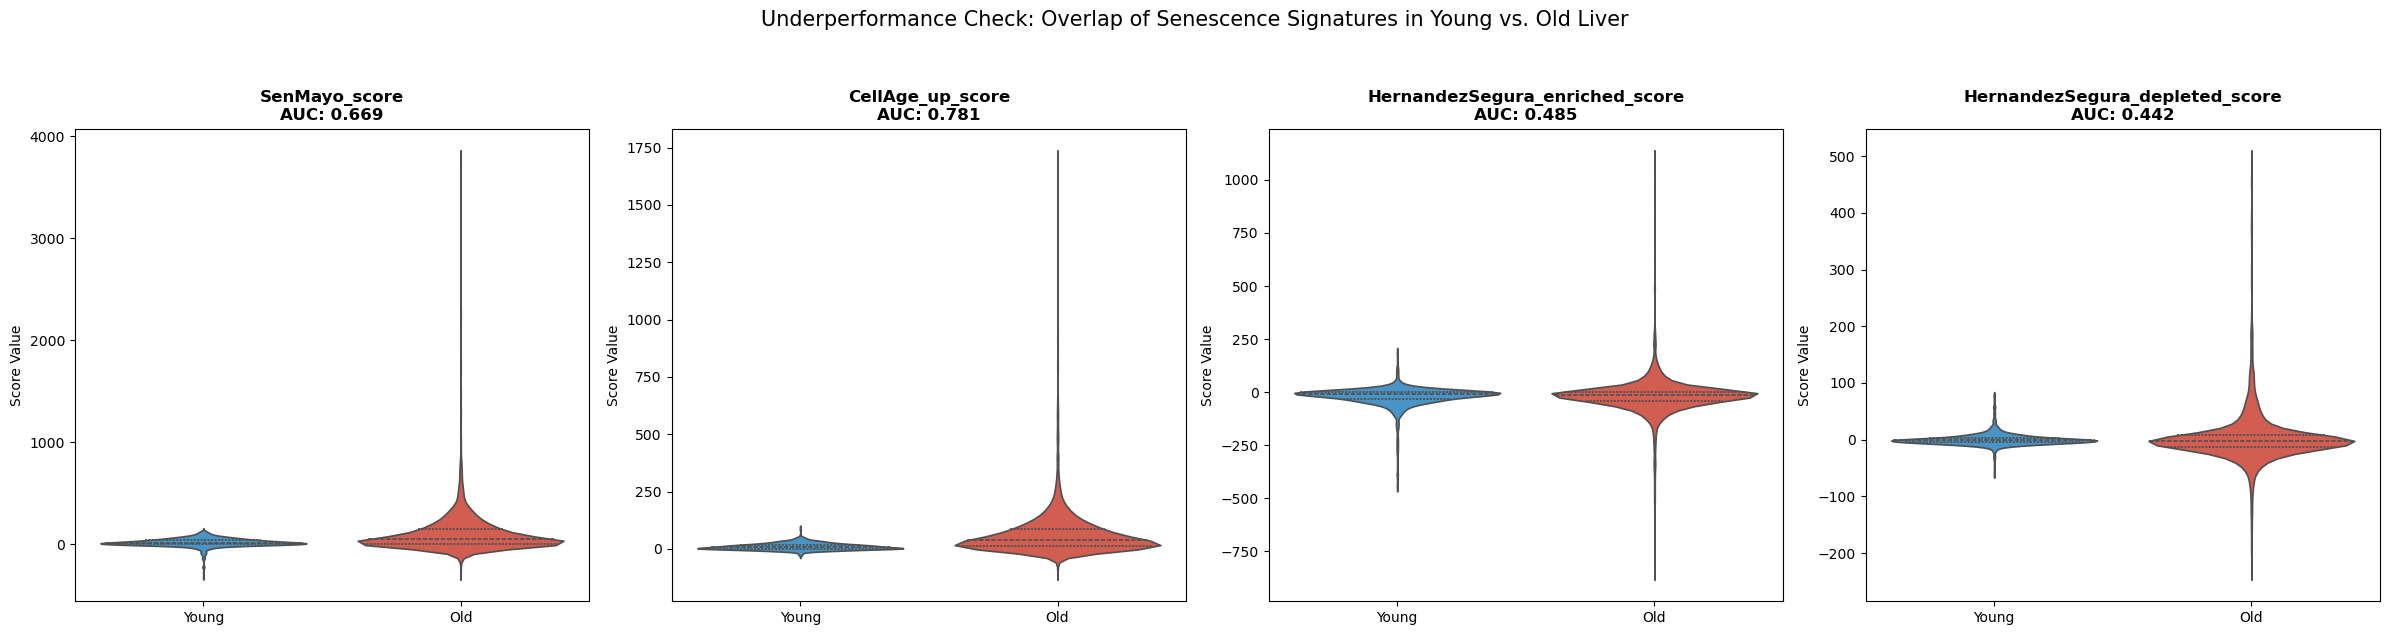

In [7]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score

# 1. LOAD DATA
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad")

# ==============================================================================
# 2. DIAGNOSTIC: FIND THE ACTUAL SCORE COLUMNS
# ==============================================================================
# This automatically finds your score columns regardless of exact naming
all_cols = adata.obs.columns.tolist()
score_cols = [c for c in all_cols if 'score' in c.lower() and ('sen' in c.lower() or 'cellage' in c.lower() or 'hernandez' in c.lower())]

print(f"Detected score columns for analysis: {score_cols}")

if not score_cols:
    print("Error: No score columns found. Available columns are:")
    print(all_cols)
    # Stop here if no scores are found
    raise ValueError("Could not find senescence score columns in metadata.")

# 3. STANDARDIZE AGE GROUPS
# Making it robust to '3m' vs '3' or uppercase 'Young'
def categorize_age(age):
    age_str = str(age).lower()
    if '3' in age_str: return 'Young'
    if '18' in age_str or '24' in age_str: return 'Old'
    return 'Other'

adata.obs['age_group_binary'] = adata.obs['age'].apply(categorize_age)

# Filter for cells we can compare
df = adata.obs[adata.obs['age_group_binary'].isin(['Young', 'Old'])].copy()

# ==============================================================================
# 4. STATISTICAL PERFORMANCE ANALYSIS
# ==============================================================================
print("\n--- Signature Performance Report ---")
performance_results = []

for score in score_cols:
    young_vals = df[df['age_group_binary'] == 'Young'][score].dropna()
    old_vals = df[df['age_group_binary'] == 'Old'][score].dropna()
    
    if len(young_vals) == 0 or len(old_vals) == 0:
        continue
        
    # A. ROC-AUC (Discriminatory Power)
    y_true = (df.loc[young_vals.index.union(old_vals.index), 'age_group_binary'] == 'Old').astype(int)
    y_scores = df.loc[young_vals.index.union(old_vals.index), score]
    auc = roc_auc_score(y_true, y_scores)
    
    # B. False Positive Rate (Young cells above Old Median)
    old_median = old_vals.median()
    fpr = (young_vals > old_median).sum() / len(young_vals) * 100
    
    performance_results.append({
        'Signature': score.replace('_score', ''),
        'ROC_AUC': round(auc, 3),
        'Young_False_Pos_Rate (%)': round(fpr, 2)
    })

perf_df = pd.DataFrame(performance_results)
print(perf_df)

# ==============================================================================
# 5. VISUALIZATION
# ==============================================================================
num_plots = len(score_cols)
fig, axes = plt.subplots(1, num_plots, figsize=(6*num_plots, 6))

# If only one score is found, axes won't be an array
if num_plots == 1: axes = [axes]

for i, score in enumerate(score_cols):
    sns.violinplot(data=df, x='age_group_binary', y=score, ax=axes[i], 
                   palette={'Young': '#3498db', 'Old': '#e74c3c'},
                   order=['Young', 'Old'], inner="quartile")
    
    auc_val = perf_df.loc[perf_df['Signature'] == score.replace('_score',''), 'ROC_AUC'].values[0]
    axes[i].set_title(f"{score}\nAUC: {auc_val}", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Score Value")
    axes[i].set_xlabel("")

plt.suptitle("Underperformance Check: Overlap of Senescence Signatures in Young vs. Old Liver", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

AUC (Area Under the Curve) is a statistical metric that measures Discriminatory Power.
Specifically, it asks: "If I pick one 'Old' cell and one 'Young' cell at random, what is the probability that the 'Old' cell has a higher senescence score than the 'Young' cell?"

AUC isn't just checking if a number went up; it's checking how much the distributions overlap. The more they overlap, the lower the AUC, and the more "underperforming" the signature is.

To validate the presence of senescent cells, we applied four established gene expression signatures (SenMayo, CellAge, Hernandez-Segura). Our analysis reveals a significant performance gap: the Hernandez-Segura signatures failed to differentiate age groups (AUC ≈ 0.5), and SenMayo showed only marginal separation (AUC = 0.669).
While CellAge performed best (AUC = 0.781), the high degree of distributional overlap suggests that these signatures, often derived from in vitro fibroblasts, do not translate well to the in vivo aging liver.

Crucially, this highlights the necessity of our Splicing Analysis, which previously demonstrated a much more robust and statistically significant separation of age groups (p<10−300), suggesting that splicing stochasticity may be a more sensitive biomarker of liver aging than traditional SASP-based expression signatures

Loading Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad...

--- Normalizing Signatures & Calculating Magnitude ---
--- Identifying Senescent Cells (Intersection Strategy) ---
Generating visualizations...


C:\Users\lukas\AppData\Local\Temp\ipykernel_4136\222615278.py:100: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = subset_prop.pivot_table(index=age_column, columns='senescence_status',
C:\Users\lukas\AppData\Local\Temp\ipykernel_4136\222615278.py:100: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = subset_prop.pivot_table(index=age_column, columns='senescence_status',
C:\Users\lukas\AppData\Local\Temp\ipykernel_4136\222615278.py:100: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot

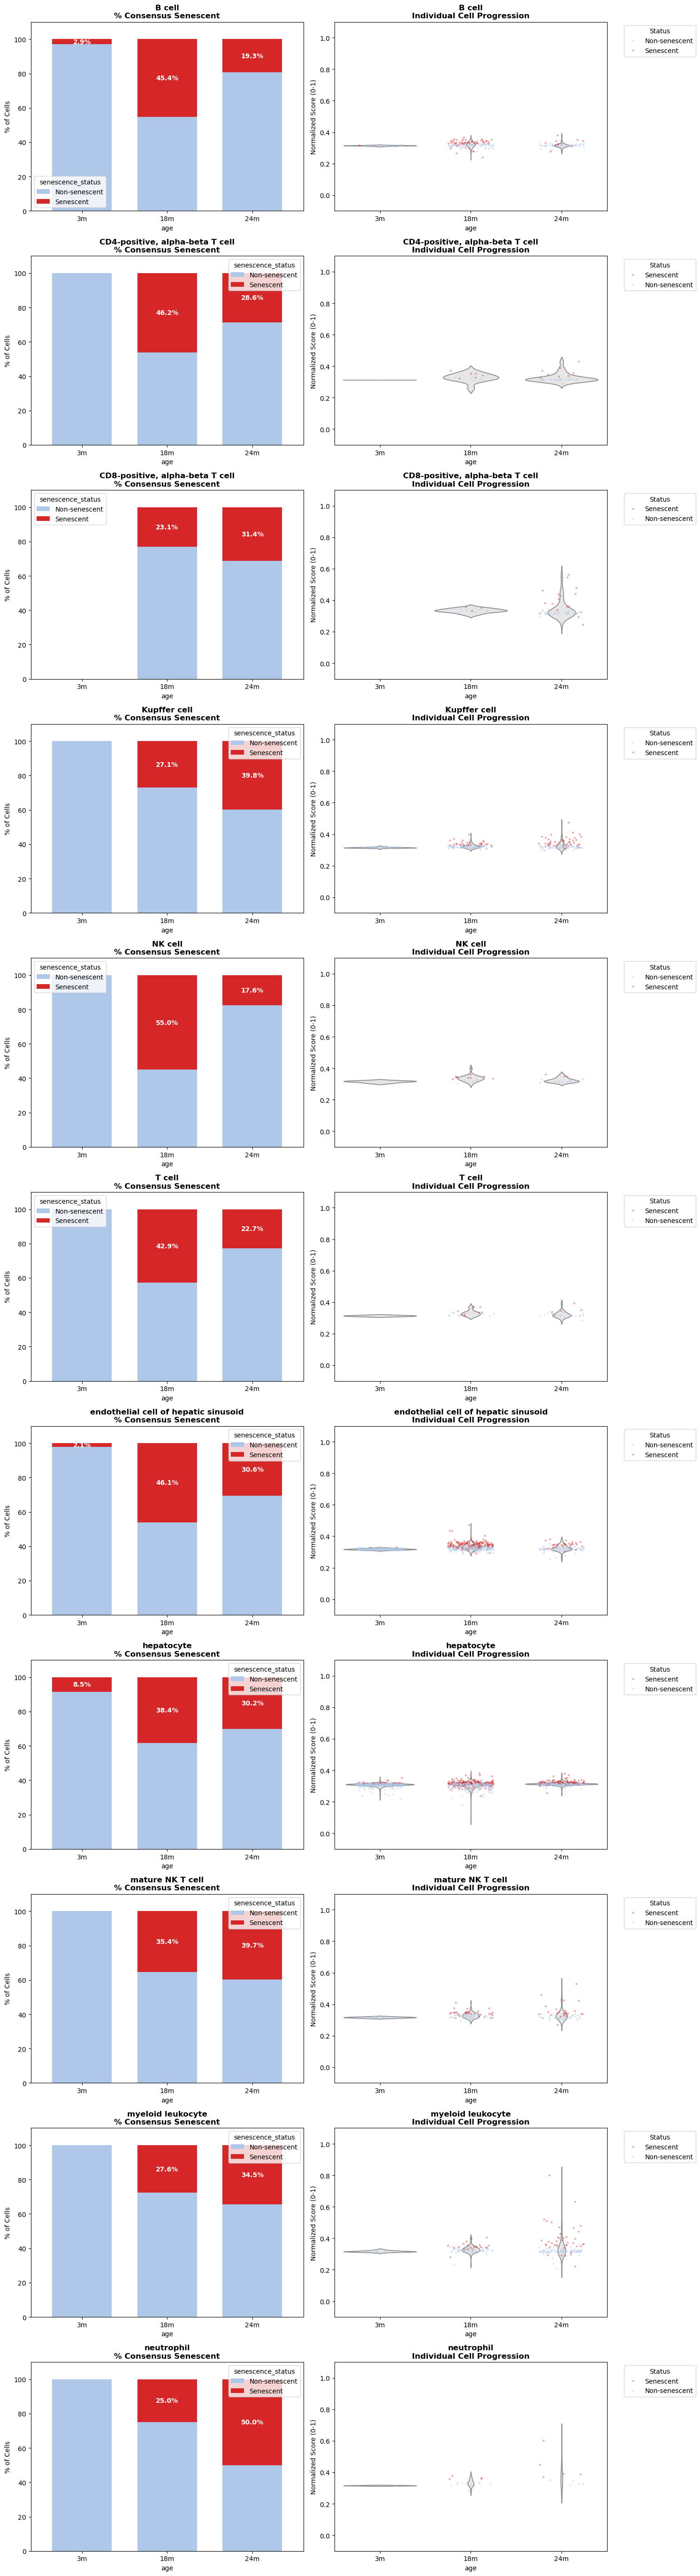

Analysis Complete. Mean Consensus Magnitude Range: 0.07 to 0.80


In [9]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ==============================================================================
# --- Step 1: Load Data & Configuration ---
# ==============================================================================
filename = "Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad"
try:
    print(f"Loading {filename}...")
    adata = sc.read_h5ad(filename)
except FileNotFoundError:
    print(f"[FATAL ERROR] {filename} not found.")
    exit()

cell_type_column = 'cell_ontology_class'
age_column = 'age'
age_order = ['3m', '18m', '24m']

# Positive signatures (Higher = More Senescent)
pos_signatures = ['SenMayo_score', 'CellAge_up_score', 'HernandezSegura_enriched_score']
# Negative signatures (Lower = More Senescent)
neg_signatures = ['HernandezSegura_depleted_score'] 

# Verify columns exist
all_sigs = pos_signatures + neg_signatures
missing_cols = [col for col in all_sigs if col not in adata.obs.columns]
if missing_cols:
    print(f"[ERROR] Missing columns in adata.obs: {missing_cols}")
    exit()

# ==============================================================================
# --- Step 2: Normalize Signatures & Calculate Consensus Magnitude ---
# ==============================================================================
print("\n--- Normalizing Signatures & Calculating Magnitude ---")

scores_df = adata.obs[all_sigs].copy()

for col in neg_signatures:
    scores_df[col] = -1 * scores_df[col]

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(scores_df)
scaled_df = pd.DataFrame(scaled_values, columns=all_sigs, index=adata.obs.index)

adata.obs['consensus_magnitude'] = scaled_df.mean(axis=1)

# ==============================================================================
# --- Step 3: Identify "Consensus" Senescent Cells (Intersection) ---
# ==============================================================================
print("--- Identifying Senescent Cells (Intersection Strategy) ---")
adata.obs['senescence_status'] = 'Non-senescent'
threshold_percentile = 0.75
min_signatures_required = 2

for cell_type in adata.obs[cell_type_column].dropna().unique():
    ct_mask = adata.obs[cell_type_column] == cell_type
    if ct_mask.sum() == 0: continue
    
    ct_data = scaled_df.loc[ct_mask]
    pass_matrix = pd.DataFrame(index=ct_data.index)
    
    for sig in all_sigs:
        thresh_val = ct_data[sig].quantile(threshold_percentile)
        pass_matrix[sig] = ct_data[sig] > thresh_val
        
    pass_counts = pass_matrix.sum(axis=1)
    senescent_indices = pass_counts[pass_counts >= min_signatures_required].index
    adata.obs.loc[senescent_indices, 'senescence_status'] = 'Senescent'

# ==============================================================================
# --- Step 4: Calculate Proportions ---
# ==============================================================================
counts_df = adata.obs.groupby([cell_type_column, age_column, 'senescence_status'], observed=False).size().reset_index(name='count')
total_counts_df = counts_df.groupby([cell_type_column, age_column], observed=False)['count'].sum().reset_index(name='total_count')
proportions_df = pd.merge(counts_df, total_counts_df, on=[cell_type_column, age_column])
proportions_df['percentage'] = (proportions_df['count'] / proportions_df['total_count']) * 100

# ==============================================================================
# --- Step 5: Visualization ---
# ==============================================================================
print("Generating visualizations...")

valid_cell_types = [ct for ct in sorted(proportions_df[cell_type_column].unique()) 
                   if proportions_df[proportions_df[cell_type_column] == ct]['total_count'].sum() > 50]

n_rows = len(valid_cell_types)
fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(15, 5 * n_rows))
if n_rows == 1: axes = np.expand_dims(axes, axis=0)

palette_status = {'Senescent': '#d62728', 'Non-senescent': '#aec7e8'}

for i, cell_type in enumerate(valid_cell_types):
    # --- LEFT: Stacked Bar ---
    ax_bar = axes[i, 0]
    subset_prop = proportions_df[proportions_df[cell_type_column] == cell_type]
    pivot_df = subset_prop.pivot_table(index=age_column, columns='senescence_status', 
                                     values='percentage', fill_value=0).reindex(age_order)
    
    for col in ['Non-senescent', 'Senescent']:
        if col not in pivot_df.columns: pivot_df[col] = 0
            
    pivot_df[['Non-senescent', 'Senescent']].plot(kind='bar', stacked=True, ax=ax_bar, 
                                                 color=[palette_status['Non-senescent'], palette_status['Senescent']], width=0.7)
    
    ax_bar.set_title(f'{cell_type}\n% Consensus Senescent', fontsize=12, fontweight='bold')
    ax_bar.set_ylabel('% of Cells')
    ax_bar.set_ylim(0, 110)
    
    # --- CHANGE: Set Age labels to horizontal ---
    ax_bar.tick_params(axis='x', labelrotation=0)
    
    for idx, age in enumerate(age_order):
        if age in pivot_df.index:
            sen_val = pivot_df.loc[age, 'Senescent']
            if sen_val > 0.5:
                y_pos = pivot_df.loc[age, 'Non-senescent'] + (sen_val / 2)
                ax_bar.text(idx, y_pos, f'{sen_val:.1f}%', ha='center', va='center', color='white', fontweight='bold')

    # --- RIGHT: Violin + Jitter ---
    ax_violin = axes[i, 1]
    subset_obs = adata.obs[adata.obs[cell_type_column] == cell_type].copy()
    subset_obs[age_column] = pd.Categorical(subset_obs[age_column], categories=age_order, ordered=True)
    
    sns.violinplot(data=subset_obs, x=age_column, y='consensus_magnitude', ax=ax_violin, 
                   inner=None, color=".9", order=age_order)
    
    sns.stripplot(data=subset_obs, x=age_column, y='consensus_magnitude', ax=ax_violin, 
                  hue='senescence_status', palette=palette_status, 
                  size=3, alpha=0.4, jitter=0.25, order=age_order)
    
    ax_violin.set_title(f'{cell_type}\nIndividual Cell Progression', fontsize=12, fontweight='bold')
    ax_violin.set_ylabel('Normalized Score (0-1)')
    ax_violin.set_ylim(-0.1, 1.1)
    ax_violin.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

    # --- CHANGE: Set Age labels to horizontal ---
    ax_violin.tick_params(axis='x', labelrotation=0)

plt.tight_layout()
plt.show()

print(f"Analysis Complete. Mean Consensus Magnitude Range: {adata.obs['consensus_magnitude'].min():.2f} to {adata.obs['consensus_magnitude'].max():.2f}")

Here we have compared for each cell type of our liver data cells that were marked as senescent above our 75th percentile score for two simultaneous signatures. Overall we can see an increase in senescent cells with age, particularly from the 3 months to 18 months brackets. Notably we do not see an overall increase in senescence from the 18 to 24 months. As mentioned in the paper, the researchers arrived at the same conclusion and hypothesized that mice that were capable of reaching such advanced ages like 24 months were already healthier and so demonstrated lower senescent cells counts (similar to the normal physiological characteristics observed in naked mole rats).

Here I have compared each cell type based on its percentage since not all cell types are represented equally in our data, such as neutrophils in comparison to endothilial cells, where neutrophils represent a very low sample in comparison to the other cell type. So in a statistical significance search I would go with the same conclusion that the researchers got to that there is a definitive increase from the 3 to 18 months, but not from the 19 to 24 months.

Loading the liver data file...
Identifying cells with at least 8000 unique genes...
Found 97 cells that meet the criteria.
Generating layered UMAP plot...


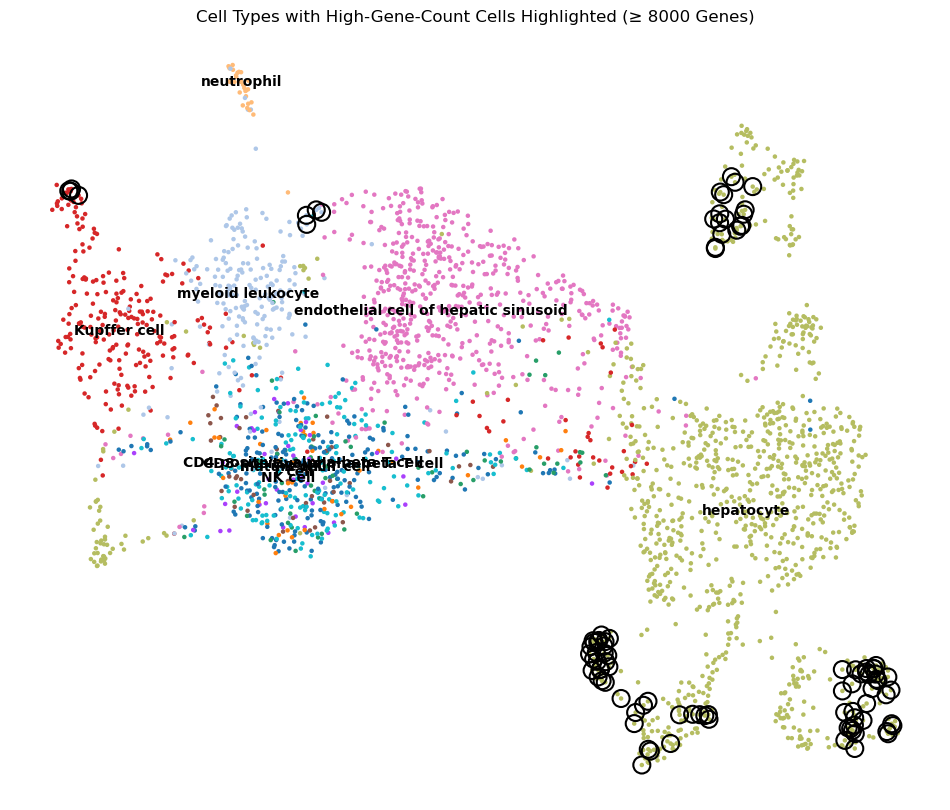

Saving updated data to Liver_facs_with_high_gene_status.h5ad...
Save complete.


In [7]:
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==============================================================================
# --- Step 1: Load the Liver AnnData object ---
# ==============================================================================
print("Loading the liver data file...")
adata_liver = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad")

# Define the threshold for the number of unique genes
gene_threshold = 8000

# ==============================================================================
# --- Step 2: Identify cells & Add Metadata Identifier ---
# ==============================================================================
print(f"Identifying cells with at least {gene_threshold} unique genes...")

# Create a boolean mask
is_high_gene_count = adata_liver.obs['n_genes_by_counts'] >= gene_threshold

# ADD NEW METADATA COLUMN for downstream access
# This creates a categorical label: 'High' or 'Normal'
adata_liver.obs['high_gene_status'] = np.where(is_high_gene_count, 'High', 'Normal')
adata_liver.obs['high_gene_status'] = adata_liver.obs['high_gene_status'].astype('category')

# Report how many cells were found
num_highlighted = is_high_gene_count.sum()
print(f"Found {num_highlighted} cells that meet the criteria.")

# ==============================================================================
# --- Step 3: Create a layered UMAP visualization ---
# ==============================================================================
print("Generating layered UMAP plot...")

fig, ax = plt.subplots(figsize=(12, 10))
sc.pl.umap(
    adata_liver,
    color='cell_ontology_class',
    ax=ax,
    show=False,
    legend_loc='on data',
    legend_fontsize='medium',
    frameon=False,
    title=f'Cell Types with High-Gene-Count Cells Highlighted (≥ {gene_threshold} Genes)'
)

# Get the UMAP coordinates of the cells to highlight
highlight_coords = adata_liver.obsm['X_umap'][is_high_gene_count]

# Plot these cells as larger black circles
ax.scatter(
    highlight_coords[:, 0],
    highlight_coords[:, 1],
    s=150,           
    facecolors='none', 
    edgecolors='black', 
    linewidth=1.5,      
    label=f'≥ {gene_threshold} genes' 
)

plt.show()

# ==============================================================================
# --- Step 4: Save the updated AnnData object ---
# ==============================================================================
output_filename = "Liver_facs_with_high_gene_status.h5ad"
print(f"Saving updated data to {output_filename}...")
adata_liver.write(output_filename)
print("Save complete.")

This is a UMAP identifying by cell type the cells that we saw had more than 8000 unique genes during QC. Clearly in the bottom right there are defined clusters of these cells that can indicate that these are artifacts that were missequenced together or that there is a clear biological signal going on.

Data loaded. Scoring cell cycle for 97 cells identified as 'High'.
S-phase genes found: 42
G2M-phase genes found: 49
Success: Cell-cycle scoring completed.


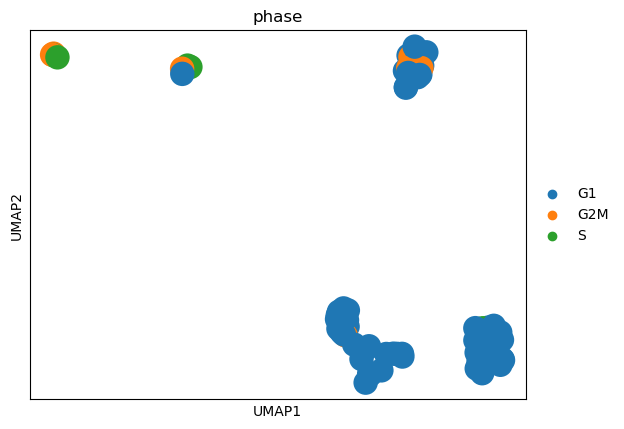

In [9]:
import scanpy as sc

# ==============================================================================
# --- ADDED: Load and Subset ---
# ==============================================================================
# Load the file saved from the previous step
adata_liver = sc.read_h5ad("Liver_facs_with_high_gene_status.h5ad")

# Subset the object to keep ONLY the high-count cells identified previously
adata_liver = adata_liver[adata_liver.obs['high_gene_status'] == 'High'].copy()

print(f"Data loaded. Scoring cell cycle for {adata_liver.n_obs} cells identified as 'High'.")

# ==============================================================================
# Step 1: Human/Standard Gene Lists (Uppercase) - INTACT
# ==============================================================================
s_genes = [
    'MCM5','PCNA','TYMS','FEN1','MCM2','MCM4','RRM1','UNG',
    'GINS2','MCM6','CDCA7','DTL','PRIM1','UHRF1','CENPU',
    'HELLS','RFC2','RPA2','NASP','RAD51AP1','GMNN',
    'WDR76','SLBP','CCNE2','UBR7','POLD3','MSH2','ATAD2',
    'RAD51','RRM2','CDC45','CDC6','EXO1','TIPIN','DSCC1',
    'BLM','CASP8AP2','USP1','CLSPN','POLA1','CHAF1B',
    'BRIP1','E2F8'
]

g2m_genes = [
    'HMGB2','CDK1','NUSAP1','UBE2C','BIRC5','TPX2','TOP2A',
    'NDC80','CKS2','NUF2','CKS1B','MKI67','TMPO','CENPF',
    'TACC3','FAM64A','SMC4','CCNB2','CKAP2L','CKAP2',
    'AURKB','BUB1','KIF11','ANP32E','TUBB4B','GTSE1',
    'KIF20B','HJURP','CDC20','TTK','CDC25C','KIF2C',
    'RANGAP1','NCAPD2','DLGAP5','CDCA3','HMMR',
    'AURKA','PSRC1','ANLN','LBR','CKAP5','CENPE',
    'CTCF','NEK2','G2E3','GAS2L3','CBX5','CENPA'
]

# ==============================================================================
# Step 2: Robust Matching (Handles hidden spaces or casing) - INTACT
# ==============================================================================

# 1. Clean up var_names
adata_liver.var_names = adata_liver.var_names.str.strip()

# 2. Match genes
var_names_lower = {name.lower(): name for name in adata_liver.var_names}

s_genes_present = [var_names_lower[g.lower()] for g in s_genes if g.lower() in var_names_lower]
g2m_genes_present = [var_names_lower[g.lower()] for g in g2m_genes if g.lower() in var_names_lower]

print(f"S-phase genes found: {len(s_genes_present)}")
print(f"G2M-phase genes found: {len(g2m_genes_present)}")

# ==============================================================================
# Step 3: Check Log-Normalization - INTACT
# ==============================================================================
if 'log1p' not in adata_liver.uns:
    print("Warning: Log-normalization not detected. Performing normalization...")
    sc.pp.normalize_total(adata_liver, target_sum=1e4)
    sc.pp.log1p(adata_liver)

# ==============================================================================
# Step 4: Run Scoring - INTACT
# ==============================================================================
if len(s_genes_present) > 0 and len(g2m_genes_present) > 0:
    sc.tl.score_genes_cell_cycle(
        adata_liver,
        s_genes=s_genes_present,
        g2m_genes=g2m_genes_present,
        use_raw=False 
    )
    print("Success: Cell-cycle scoring completed.")
else:
    print("Failure: Still no genes found.")

# ==============================================================================
# Step 5: Visualization - INTACT
# ==============================================================================
sc.pl.umap(adata_liver, color=['phase'], wspace=0.3)

Most cells we can see are in the G1 phase. This is a signature of polyploid hepatocytes in mice cells, and a reason why these cells show higher than average unique gene count for our dataset.

The other smaller size of cells that are in the G2M or S phase are examples where cells are dividing and so have a temporary increased gene count.

Now I want to see per cell (among all cells classified as senescent by SenMayo) how many reads are associated with the genes that classified it as senescent by the SenMayo signature, specifically, in an effort to identify one or more genes that are overexpressed in these cells in comparison with others. To facilitate observation and study of the data I will compute the overall percentage of cells that have reads above zero for any gene included in SenMayo. 

And i wonder if it also makes sense to, from the cells identified by SenMayo, identify and compare not only the genes that are more expressed but the genes that are least expressed between the cells that belong to different age groups.

This will be a descriptive / exploratory visualization of expression distributions for a pre‑chosen gene set, not DEG calling.

In [ ]:
# Data retrieval
sc.settings.set_figure_params(dpi=50, facecolor="white")

# Load your liver FACS Smart-seq2 data
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad")  # path to your file

# Make sure variable (gene) names are unique
adata.var_names_make_unique()

# Make sure observation (cell) names are unique
adata.obs_names_make_unique()

# Inspect AnnData object
print(adata)

#display the pandas crosstab 
print(pd.crosstab(adata.obs['age'], adata.obs['mouse.id']))

AnnData object with n_obs × n_vars = 2858 × 19559
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'age_sex', 'doublet_score', 'predicted_doublet', 'leiden_0.5', 'leiden_0.75', 'leiden_1.0', 'cell_type', 'celltypist_predicted_labels', 'SenMayo_score', 'CellAge_up_score', 'HernandezSegura_enriched_score', 'HernandezSegura_depleted_score', 'HernandezSegura_combined_score', 'is_high_SenMayo', 'is_high_CellAge', 'is_high_Hernandez', 'senescence_category_3'
    var: 'n_cells', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'mt', 'n_cells_by_counts', 'mean_counts

INFO:biothings.client:querying 1-117 ...


Found 186 high-scoring 'Hepatocyte' cells for analysis.


INFO:biothings.client:Finished.



[DIAGNOSTIC] Genes in main object: 19559
[DIAGNOSTIC] Genes in .raw object: 22966

[DIAGNOSTIC] Number of SenMayo genes found in .raw object: 123
[DIAGNOSTIC] Example matching genes: ['Acvr1b', 'Ang', 'Angpt1', 'Angptl4', 'Ar', 'Areg', 'Axl', 'Bmp2', 'Bmp6', 'C3']

--- Top 10 Genes by Total Read Count ---
      gene  total_reads
27    Ctsb     397004.0
9       C3     378905.0
59  Igfbp4     275663.0
57  Igfbp2     179527.0
62  Igfbp7     170065.0
52     Hrg     136340.0
55    Igf1      98818.0
1      Ang      89948.0
56  Igfbp1      83970.0
80     Mif      48505.0


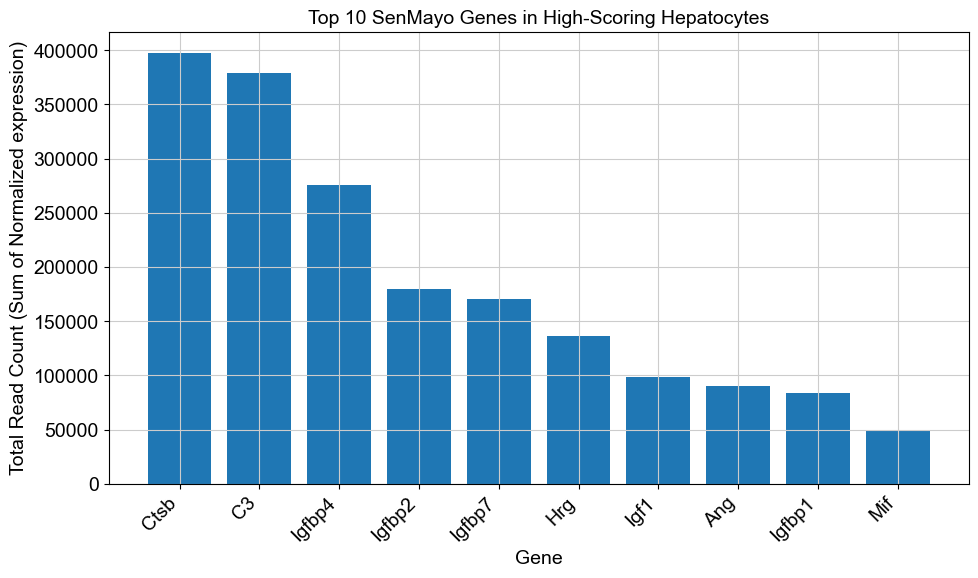

In [ ]:
# --- 1. Load Data and Subset ---
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad")
# (Your subsetting code is correct)
# ...
target_cell_type = 'Hepatocyte'
cell_type_mask = adata.obs['cell_type'] == target_cell_type
adata_subset = adata[cell_type_mask].copy()
senmayo_threshold = np.percentile(adata_subset.obs['SenMayo_score'], 75)
adata_subset.obs['is_high_SenMayo'] = adata_subset.obs['SenMayo_score'] > senmayo_threshold
senescent_cell_mask = adata_subset.obs['is_high_SenMayo'] == True
num_senescent_cells = senescent_cell_mask.sum()
print(f"Found {num_senescent_cells} high-scoring '{target_cell_type}' cells for analysis.")


if num_senescent_cells > 0:
    # --- 2. Load and Translate Gene List (this part is correct) ---
    # ... (code to load GMT and translate with mygene) ...
    # Let's assume 'all_possible_names' is the final translated set of SenMayo gene names.
    senmayo_gene_sets = gp.read_gmt(path="SAUL_SEN_MAYO.v2025.1.Mm.gmt")
    senmayo_symbols_to_find = list(senmayo_gene_sets["SAUL_SEN_MAYO"])
    # (Translation logic would go here, resulting in 'all_possible_names')
    # For this example, let's assume 'all_possible_names' is ready.
    # ...
    # This is a simplified version of your translation logic
    mg = mygene.MyGeneInfo()
    gene_info = mg.querymany(senmayo_symbols_to_find, scopes='symbol', fields='alias', species='mouse', as_dataframe=True)
    all_possible_names = set(s.upper() for s in senmayo_symbols_to_find)
    for alias_list in gene_info['alias'].dropna():
        aliases = alias_list if isinstance(alias_list, list) else [alias_list]
        for alias in aliases:
            all_possible_names.add(str(alias).upper())

    # --- 3. Find Intersection Using the CORRECT Gene List from .raw ---
    
    # --- DIAGNOSTIC CHECK ---
    # This will prove the difference and confirm the diagnosis.
    if adata_subset.raw:
        print(f"\n[DIAGNOSTIC] Genes in main object: {adata_subset.n_vars}")
        print(f"[DIAGNOSTIC] Genes in .raw object: {adata_subset.raw.n_vars}")
    else:
        raise ValueError("The .raw attribute is missing, which is required for this analysis.")
    # ----------------------

    # --- THIS IS THE FIX ---
    # We check for gene membership in adata_subset.raw.var_names
    adata_raw_var_names_upper = [name.upper() for name in adata_subset.raw.var_names]
    
    senmayo_genes_in_adata = [
        gene for gene, upper_gene in zip(adata_subset.raw.var_names, adata_raw_var_names_upper)
        if upper_gene in all_possible_names
    ]
    # --- END OF FIX ---
    
    print(f"\n[DIAGNOSTIC] Number of SenMayo genes found in .raw object: {len(senmayo_genes_in_adata)}")
    print(f"[DIAGNOSTIC] Example matching genes: {senmayo_genes_in_adata[:10]}")

    # --- 4. The rest of your analysis code is now correct ---
    if senmayo_genes_in_adata:
        senmayo_expression = adata_subset[senescent_cell_mask].raw[:, senmayo_genes_in_adata].X
        expression_dense = senmayo_expression.toarray() if scipy.sparse.issparse(senmayo_expression) else senmayo_expression
        total_reads = expression_dense.sum(axis=0)

        read_counts_df = pd.DataFrame({
            'gene': senmayo_genes_in_adata,
            'total_reads': total_reads
        }).sort_values(by='total_reads', ascending=False)

        print("\n--- Top 10 Genes by Total Read Count ---")
        print(read_counts_df.head(10))

        # (Your plotting code here...)
        plt.figure(figsize=(10, 6))
        top_genes_df = read_counts_df.head(10)
        plt.bar(top_genes_df['gene'], top_genes_df['total_reads'])
        plt.xticks(rotation=45, ha='right')
        plt.ylabel("Total Read Count (Sum of Normalized expression)")
        plt.xlabel("Gene")
        plt.title(f"Top 10 SenMayo Genes in High-Scoring {target_cell_type}s")
        plt.tight_layout()
        plt.show()

Here we can see the sum of normalized expression of cells based on their total read count for each of the more highly expressed genes included in the senmayo signature, meaning genes that in some way have been associated with the senescent senotype.

Here we can see that the two most highly expressed genes are Ctsb and C3. 

- CTSB (cathepsin B) is a lysosomal protease whose activity and localization change with ageing and lysosomal dysfunction; altered cathepsin function is observed in ageing tissues and neurodegeneration and has been linked to age‑related pathology and senescence‑like phenotypes.

- C3 is a central complement component that can be produced locally by stressed or damaged cells; complement activation is increasingly recognized as part of the SASP and the inflammatory milieu surrounding senescent cells.

--- Loading main data from: Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad ---


INFO:biothings.client:querying 1-117 ...


--- Found 11 cell types in 'cell_ontology_class': ---
['B cell', 'CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell', 'Kupffer cell', 'NK cell', 'T cell', 'endothelial cell of hepatic sinusoid', 'hepatocyte', 'mature NK T cell', 'myeloid leukocyte', 'neutrophil']

--- Loading and translating gene list from: SAUL_SEN_MAYO.v2025.1.Mm.gmt ---


INFO:biothings.client:Finished.


Found 123 matching SenMayo genes in the .raw object.

Using these Top 10 genes for all cell types: ['Hmgb1', 'Ctsb', 'Igfbp4', 'Mif', 'C3', 'Lcp1', 'Igf1', 'Tnfrsf1a', 'Ctnnb1', 'Jun']


--- Starting analysis for: B cell ---
Found 53 senescent cells (Score > 8.09).


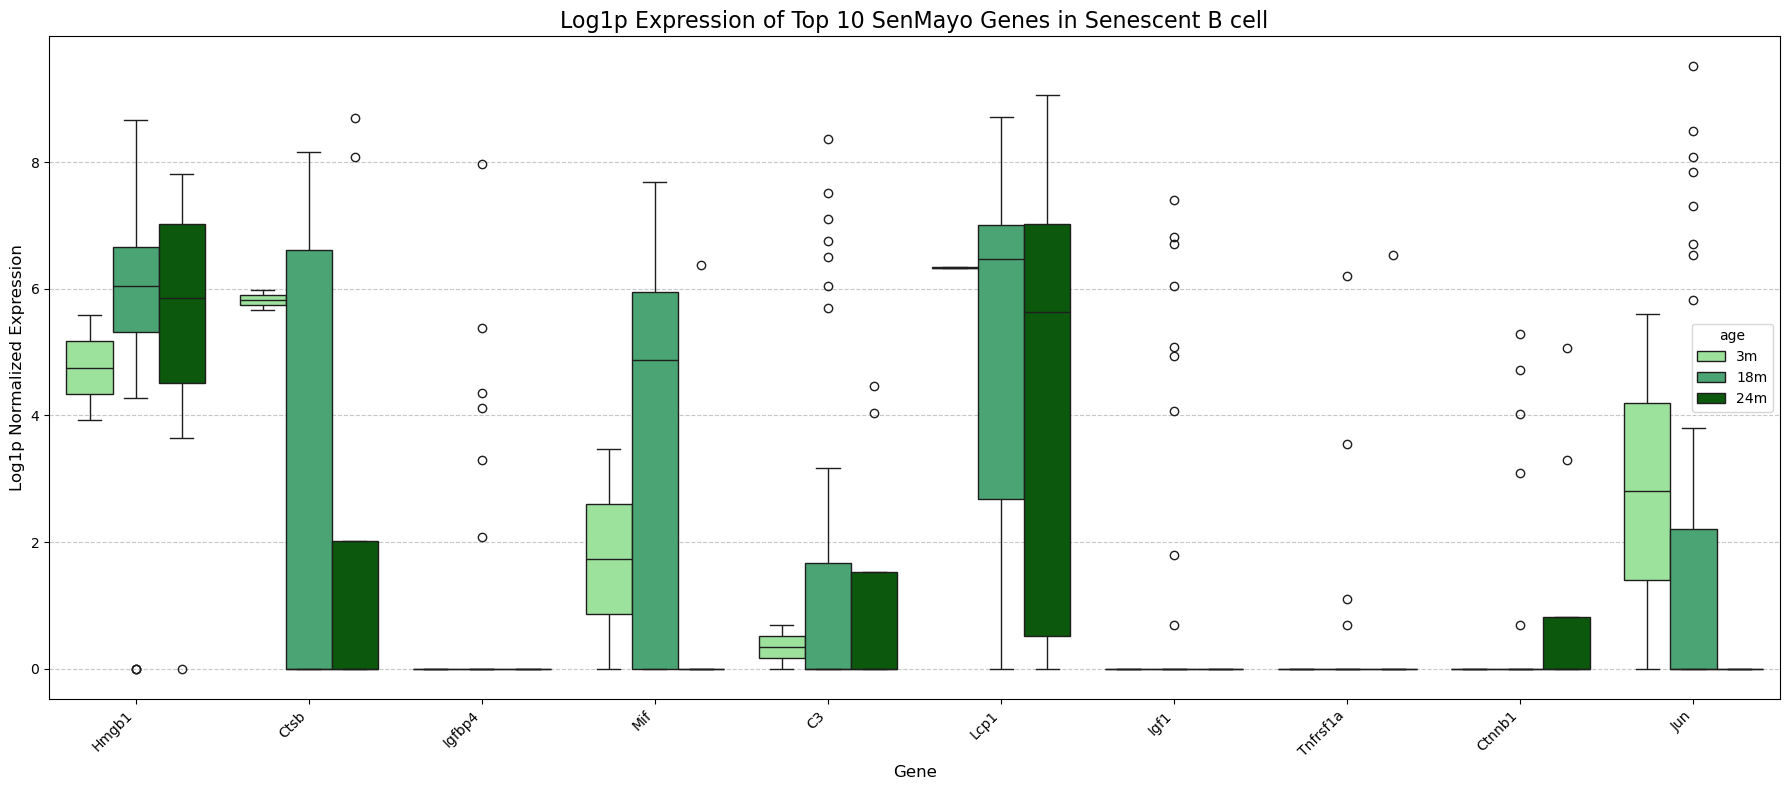


--- Starting analysis for: CD4-positive, alpha-beta T cell ---
Found 11 senescent cells (Score > 25.52).


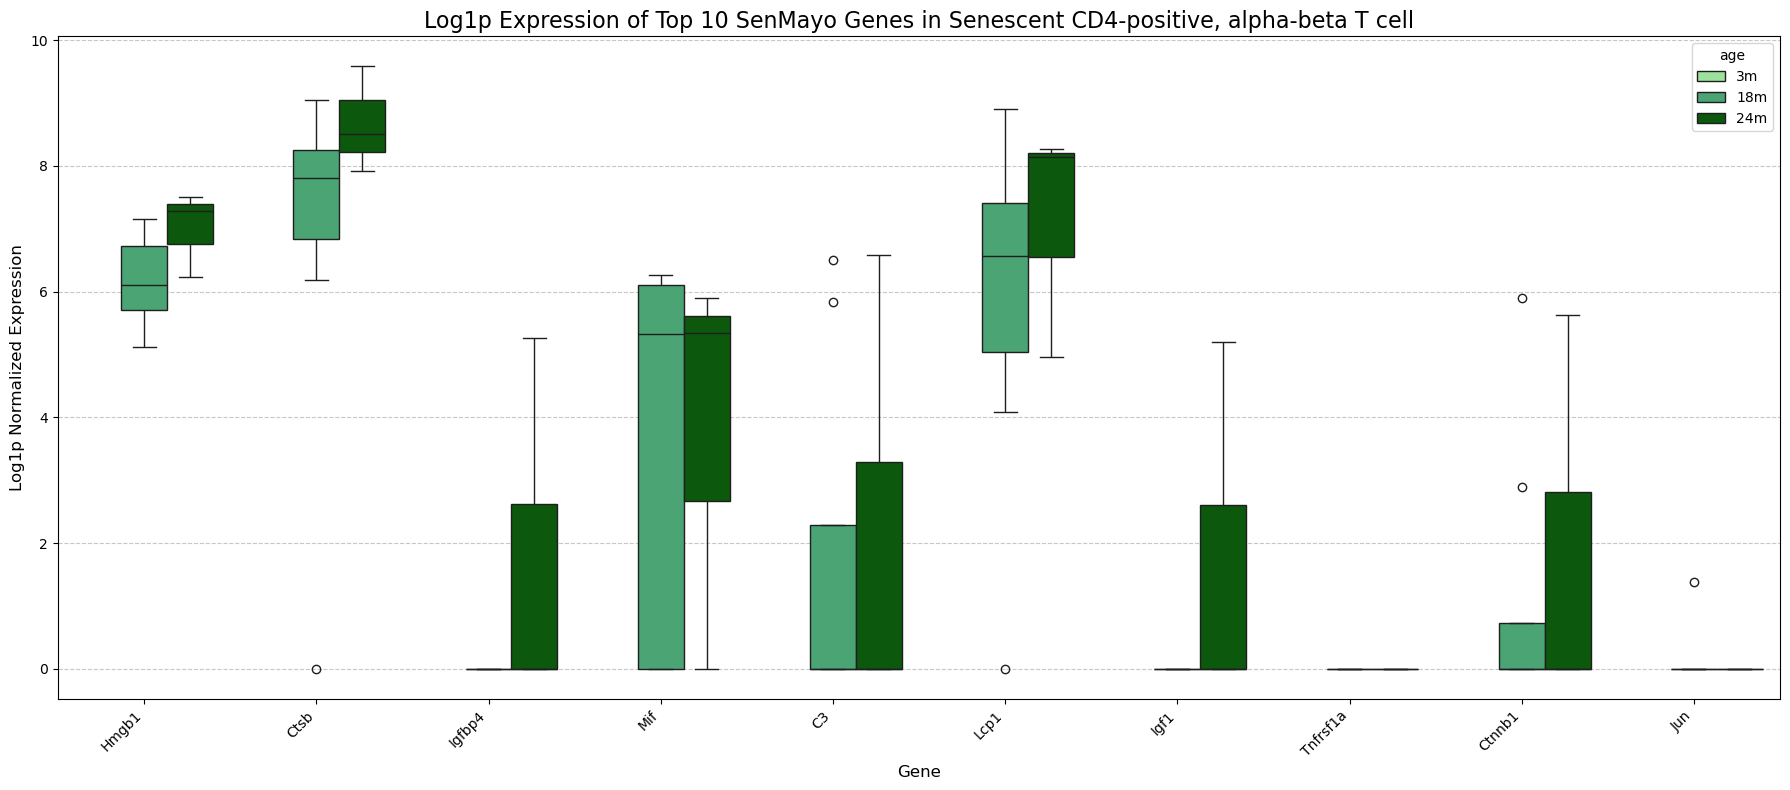


--- Starting analysis for: CD8-positive, alpha-beta T cell ---
Found 16 senescent cells (Score > 409.73).


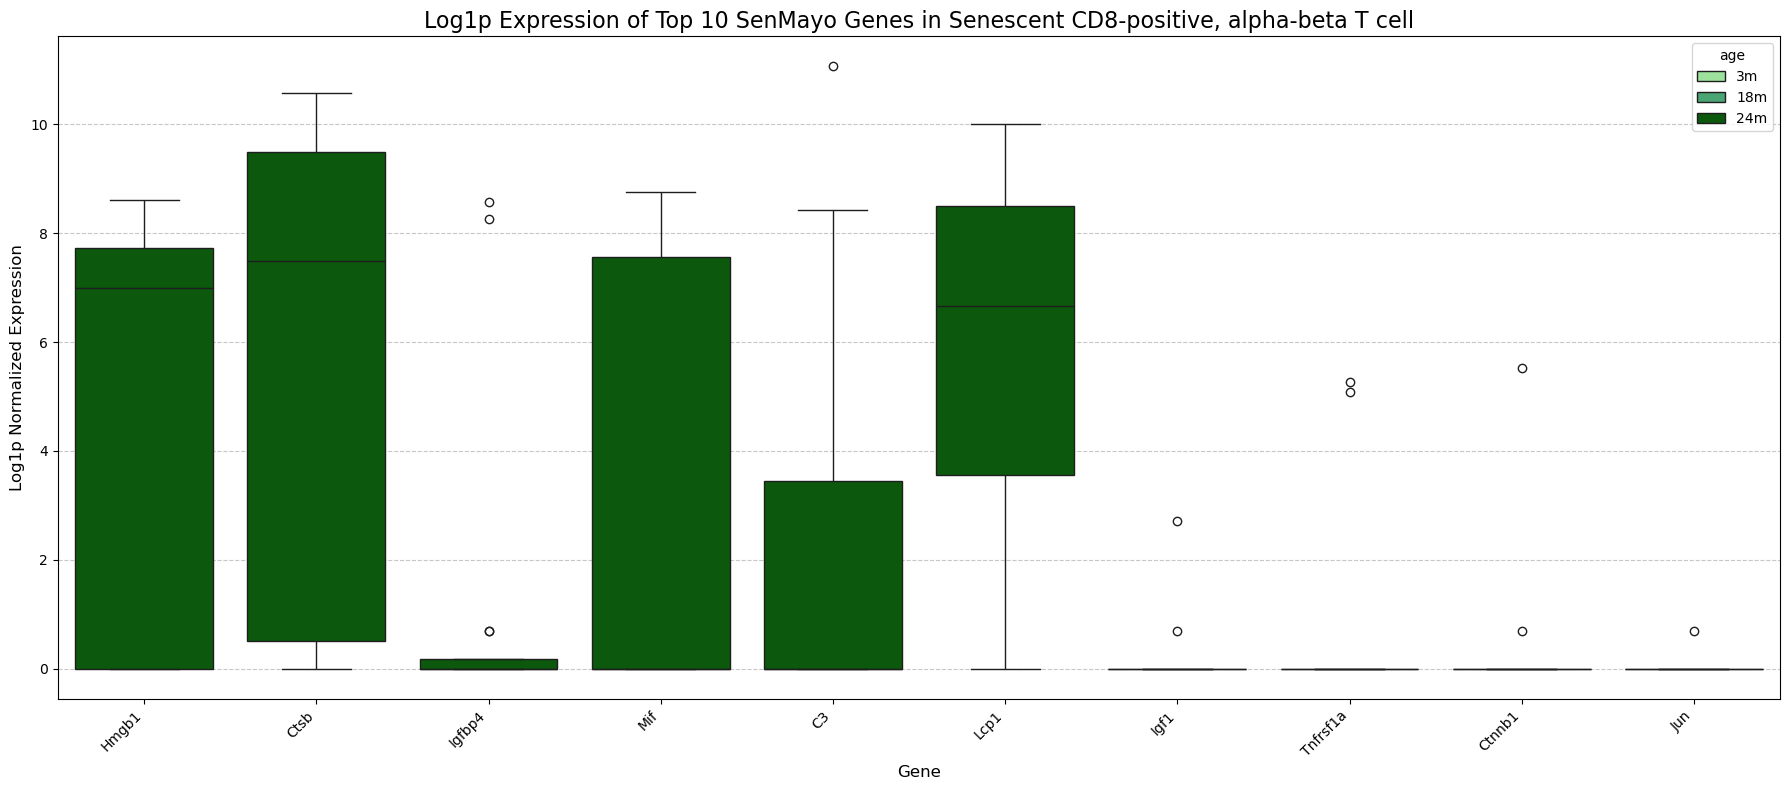


--- Starting analysis for: Kupffer cell ---
Found 66 senescent cells (Score > 177.16).


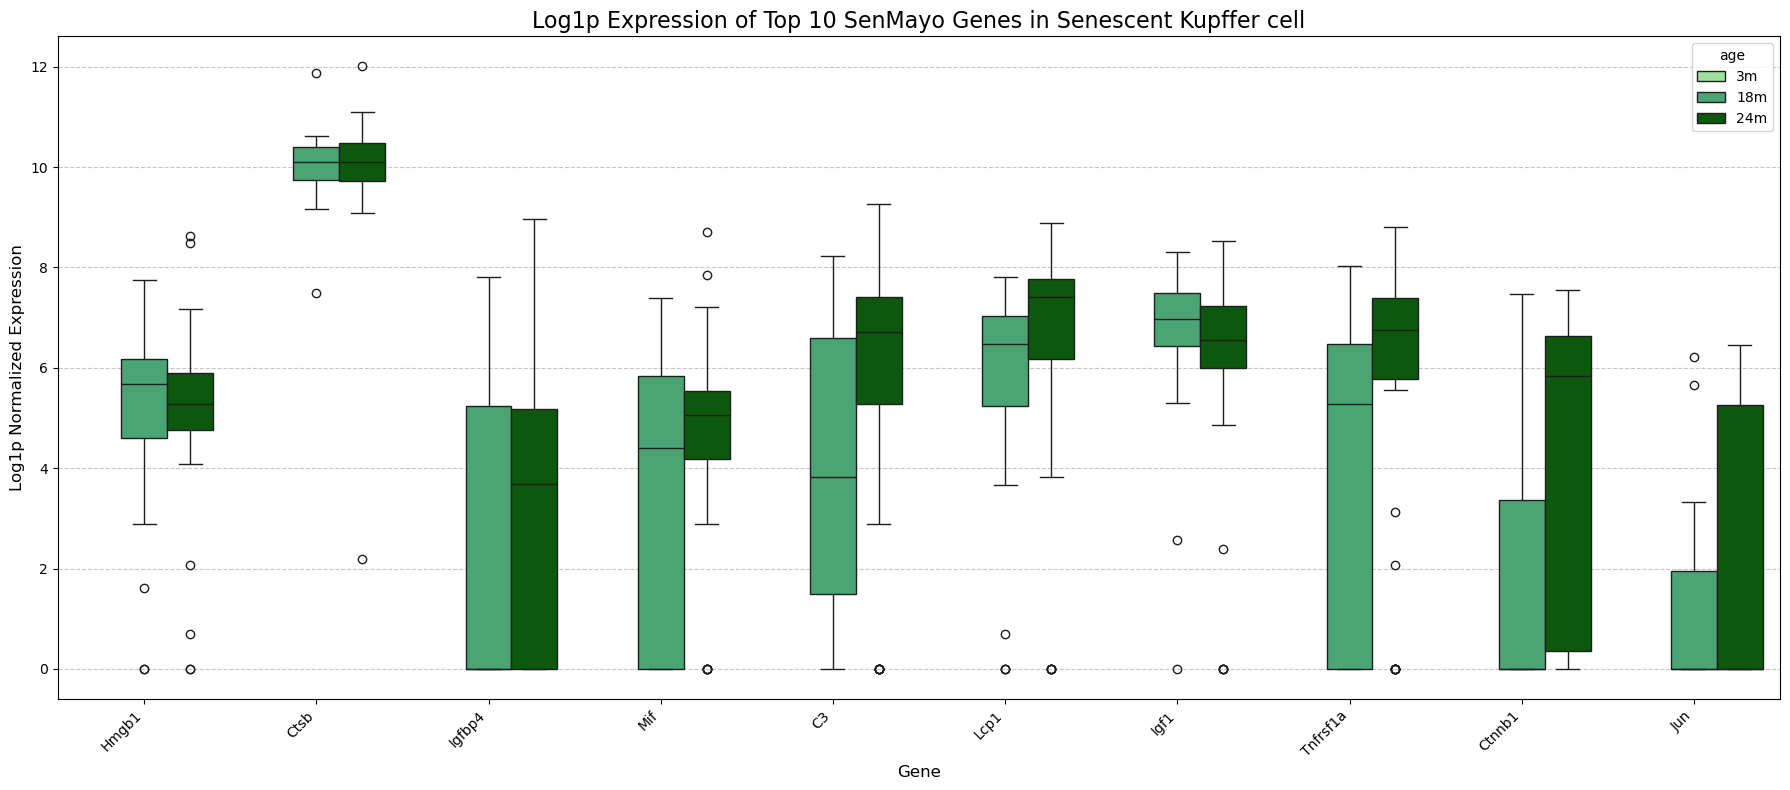


--- Starting analysis for: NK cell ---
Found 11 senescent cells (Score > 168.52).


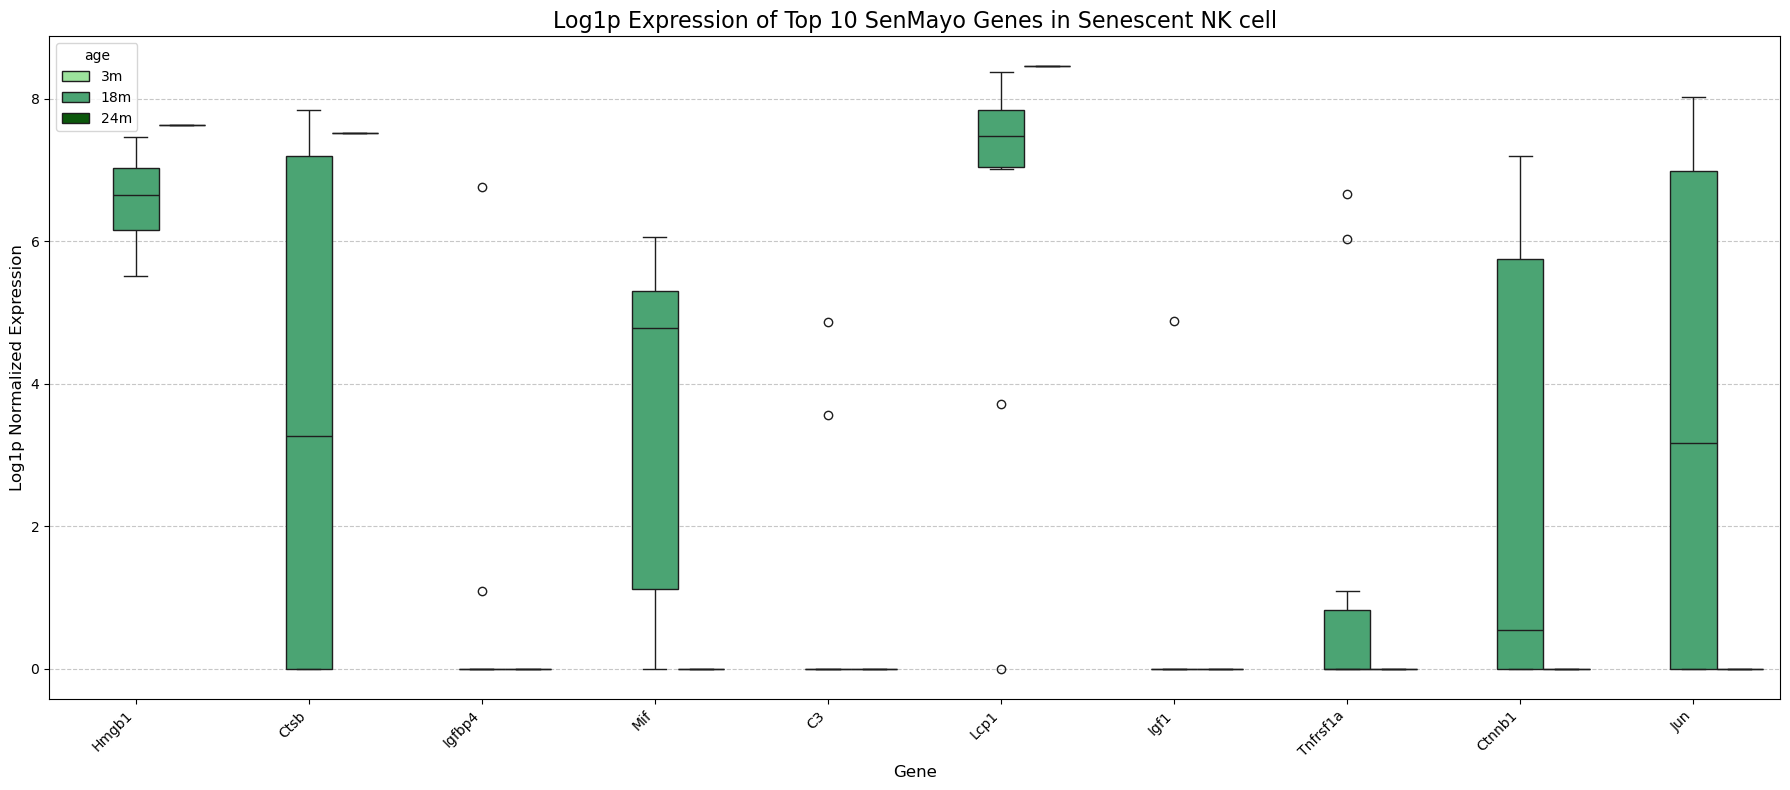


--- Starting analysis for: T cell ---
Found 11 senescent cells (Score > 163.68).


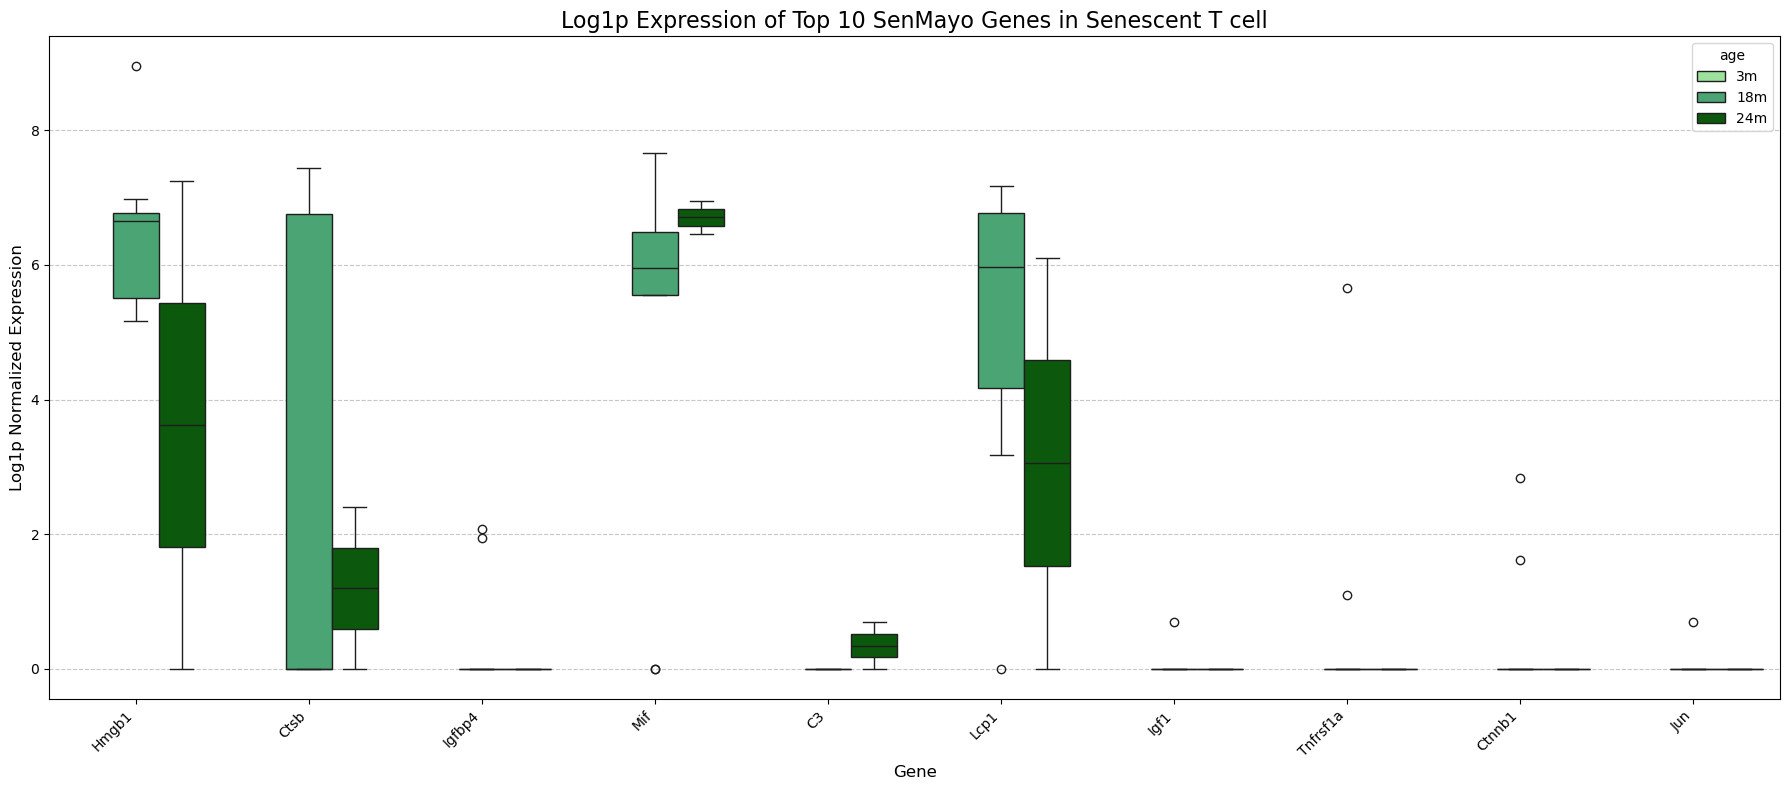


--- Starting analysis for: endothelial cell of hepatic sinusoid ---
Found 154 senescent cells (Score > 222.33).


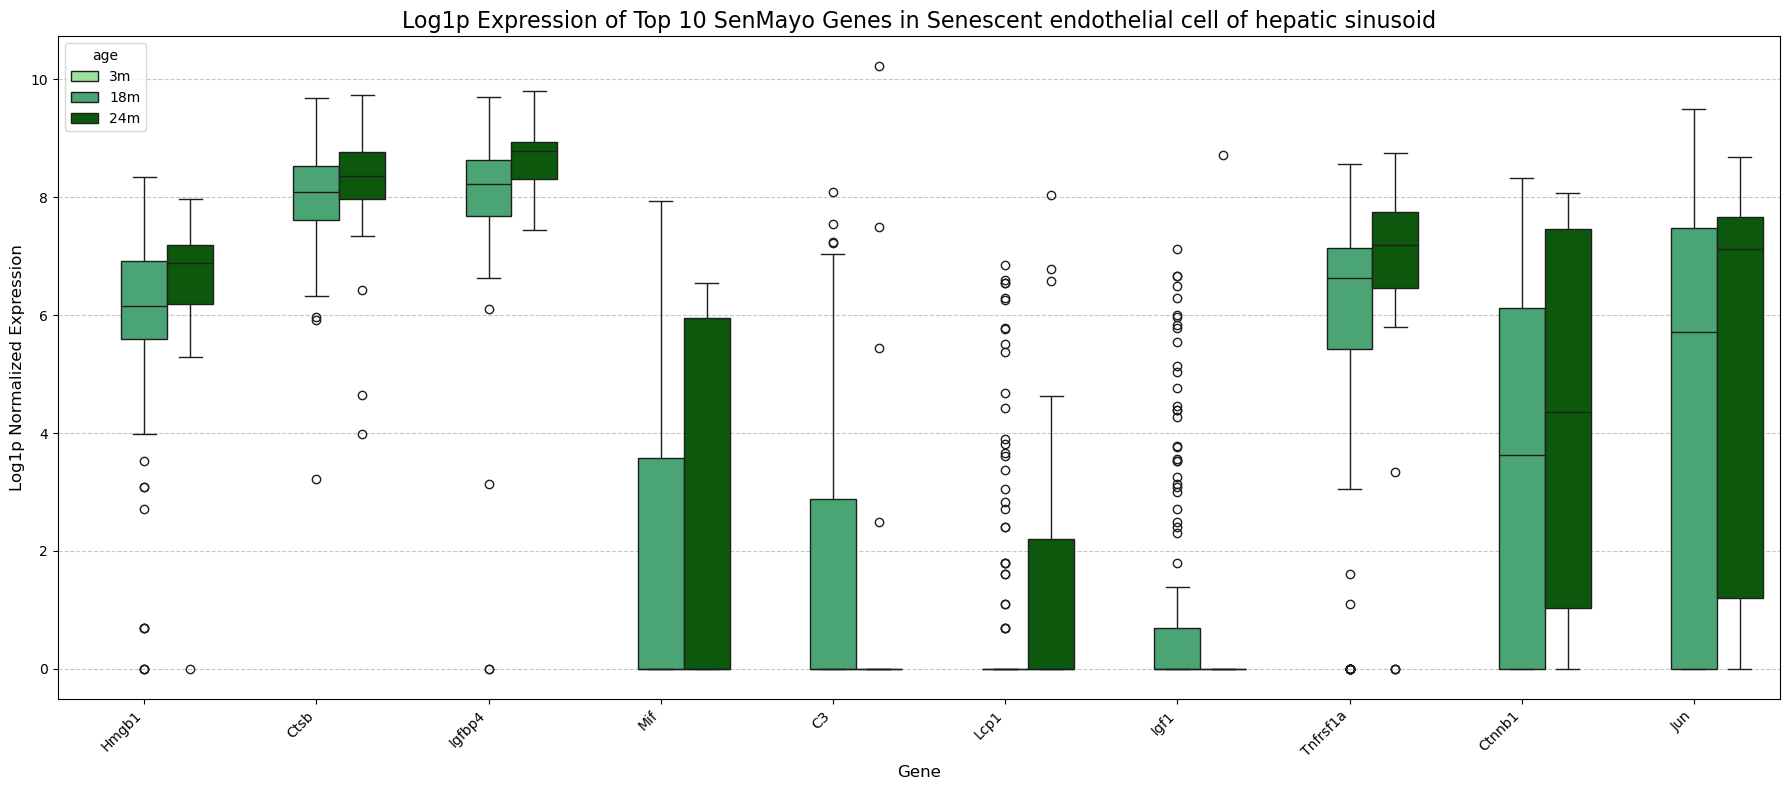


--- Starting analysis for: hepatocyte ---
Found 290 senescent cells (Score > 29.89).


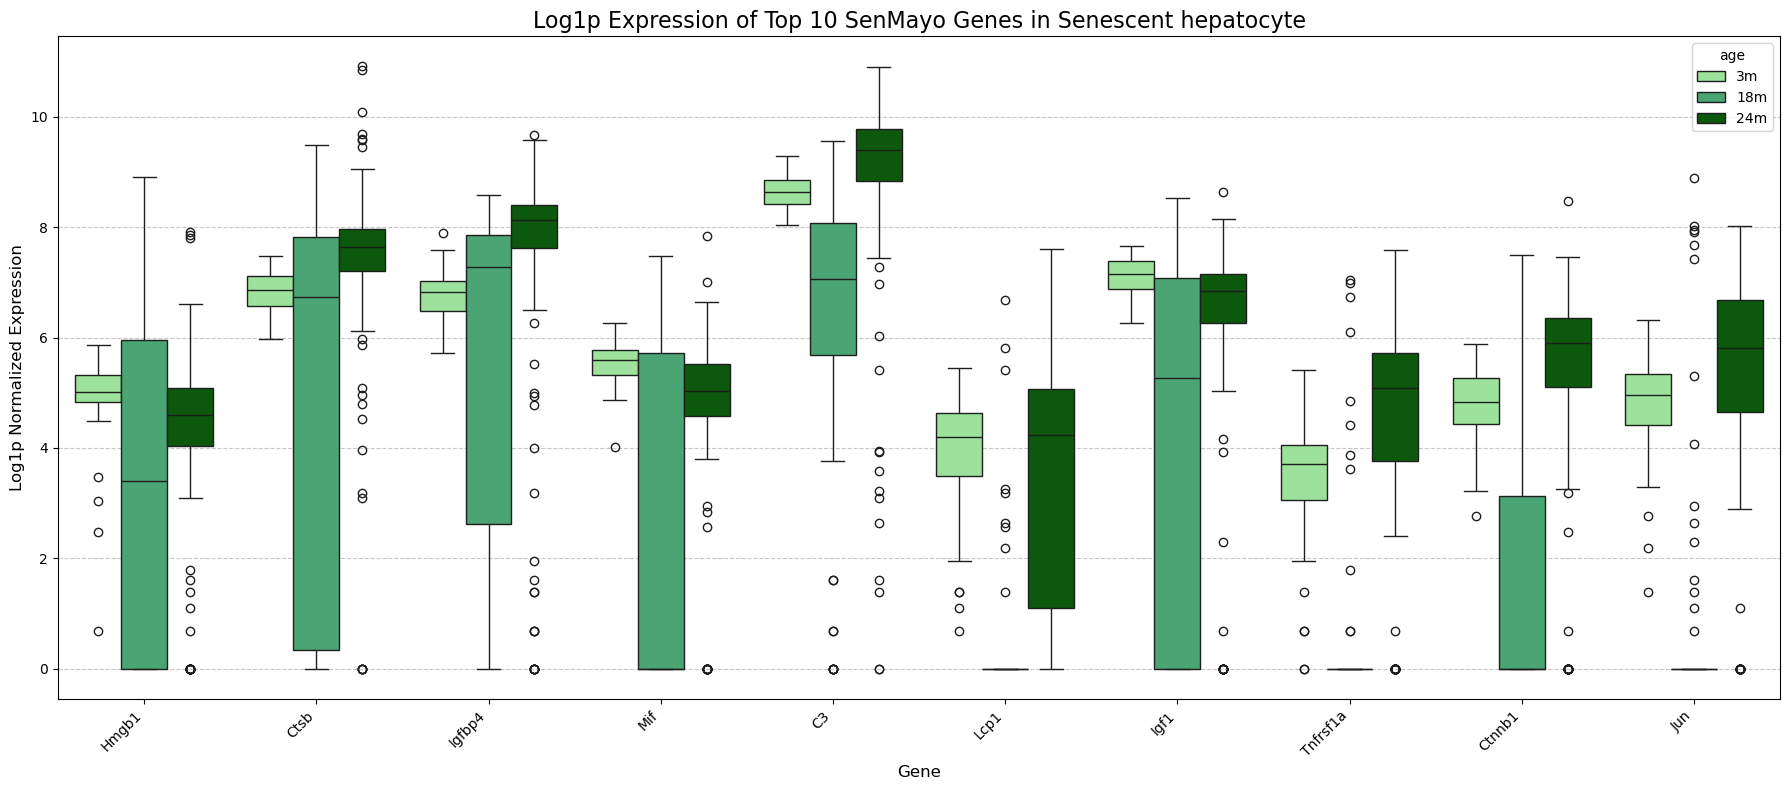


--- Starting analysis for: mature NK T cell ---
Found 44 senescent cells (Score > 107.79).


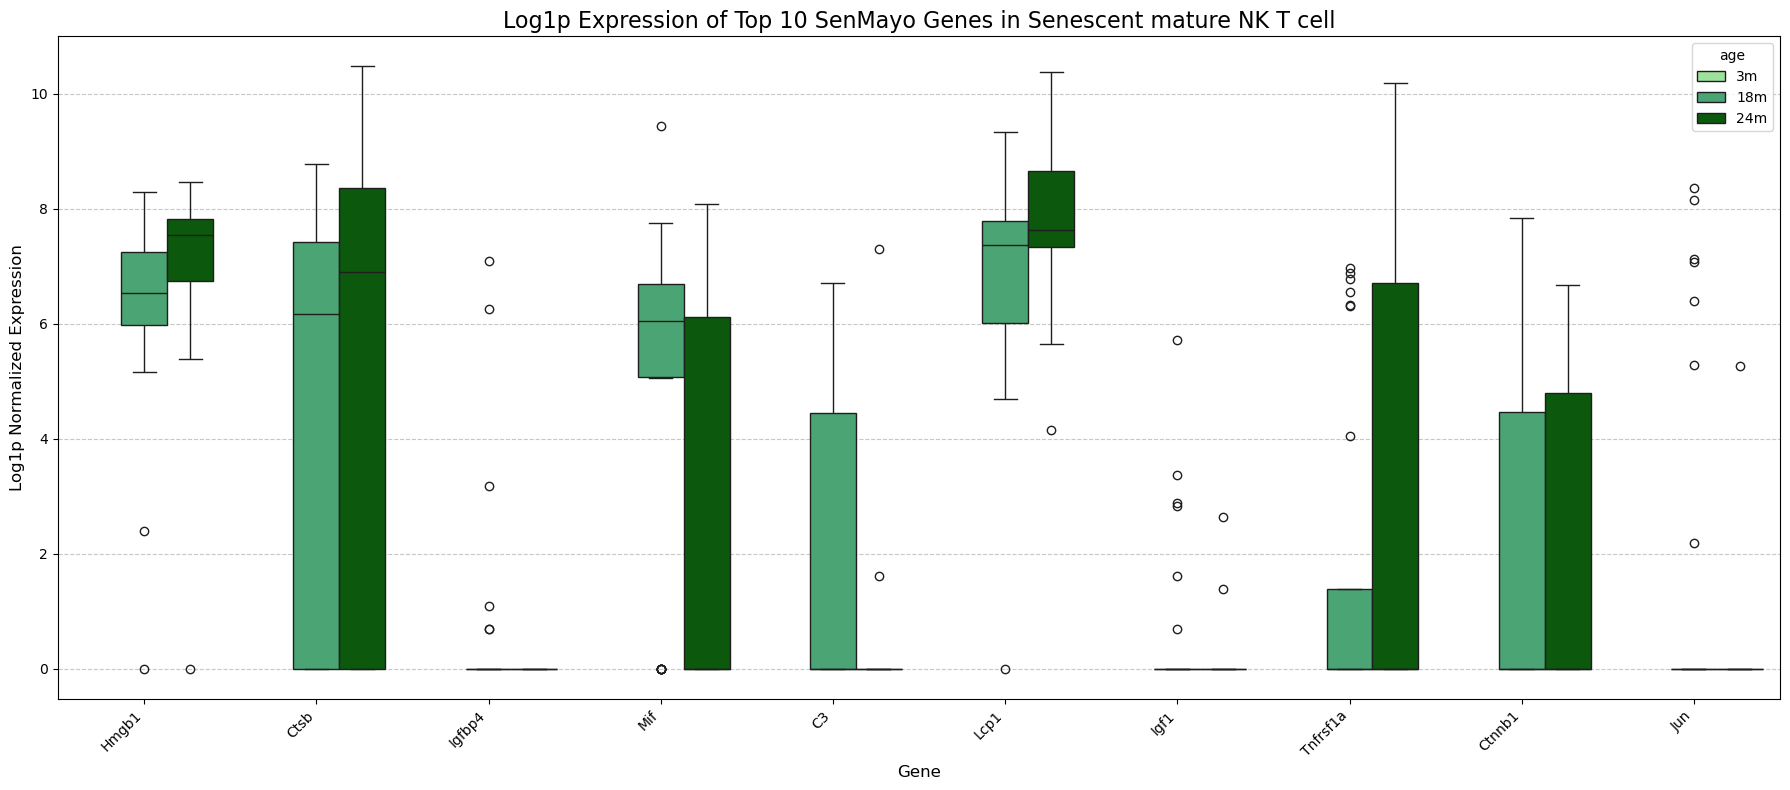


--- Starting analysis for: myeloid leukocyte ---
Found 52 senescent cells (Score > 102.47).


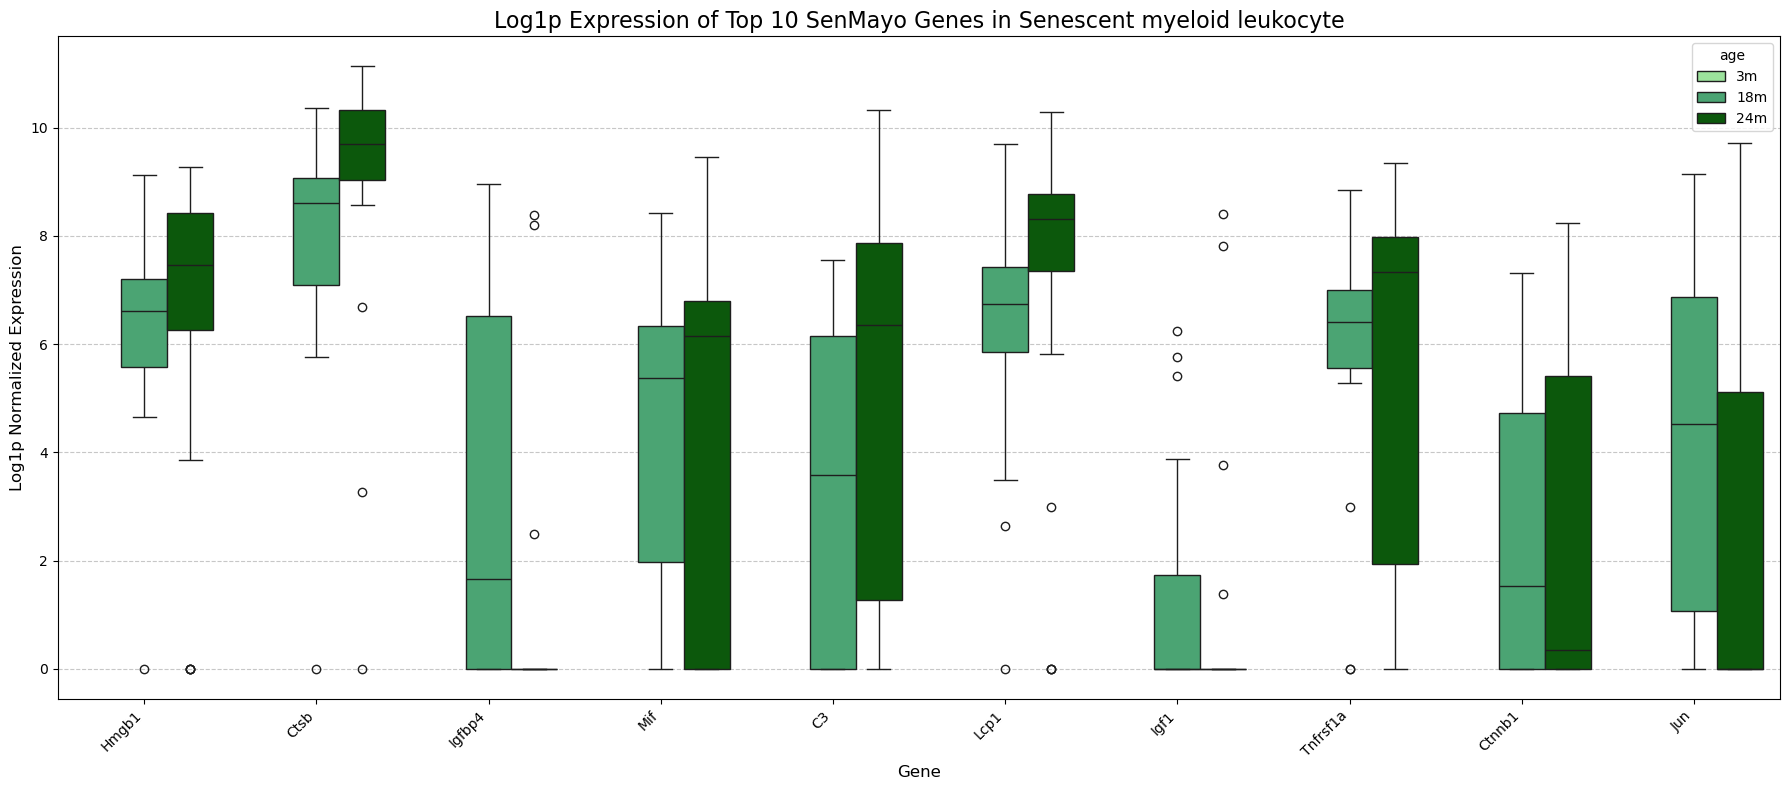


--- Starting analysis for: neutrophil ---
Found 8 senescent cells (Score > 207.02).


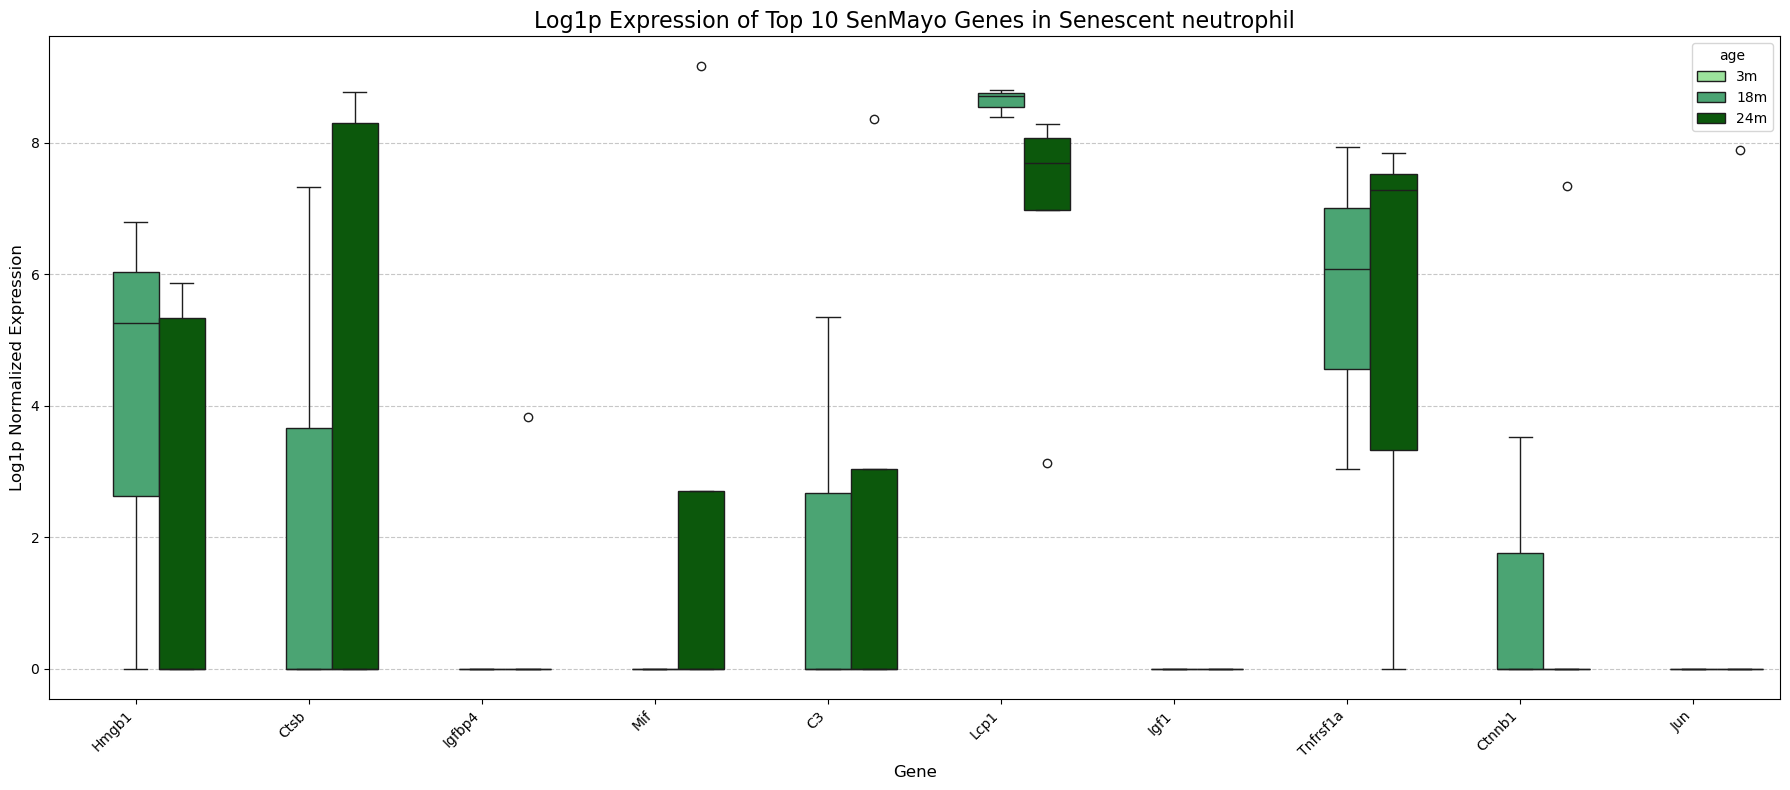


Analysis complete.


In [2]:
# ==============================================================================
# --- PART 0: IMPORT LIBRARIES (ASSUMED) ---
# ==============================================================================
import scanpy as sc
import pandas as pd
import numpy as np
import gseapy as gp
import mygene
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==============================================================================
# --- PART 1: SETUP (RUNS ONLY ONCE) ---
# ==============================================================================

# --- 1a. Define Inputs and Parameters ---
input_h5ad_file = "Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad"
input_gmt_file = "SAUL_SEN_MAYO.v2025.1.Mm.gmt"

# UPDATED: Use the cell ontology class column
cell_type_column = 'cell_ontology_class'

# --- 1b. Load Main Data File ---
print(f"--- Loading main data from: {input_h5ad_file} ---")
adata = sc.read_h5ad(input_h5ad_file)
if adata.raw is None:
    raise ValueError("The .raw attribute is missing, which is required for this analysis.")

# Check if column exists
if cell_type_column not in adata.obs.columns:
    raise ValueError(f"Column '{cell_type_column}' not found in adata.obs.")

# UPDATED: Automatically identify all cell types in the cell_ontology_class column
# We filter out NaNs and sort them alphabetically
all_cell_types_to_analyze = sorted(adata.obs[cell_type_column].dropna().unique().tolist())
print(f"--- Found {len(all_cell_types_to_analyze)} cell types in '{cell_type_column}': ---")
print(all_cell_types_to_analyze)

# --- 1c. Load and Translate SenMayo Gene List ---
print(f"\n--- Loading and translating gene list from: {input_gmt_file} ---")
try:
    senmayo_gene_sets = gp.read_gmt(path=input_gmt_file)
    senmayo_symbols_to_find = list(senmayo_gene_sets["SAUL_SEN_MAYO"])
except FileNotFoundError:
    print(f"Error: {input_gmt_file} not found.")
    exit()

# Translate gene symbols to match data's RIKEN IDs
mg = mygene.MyGeneInfo()
gene_info = mg.querymany(senmayo_symbols_to_find, scopes='symbol', fields='alias', species='mouse', as_dataframe=True)
all_possible_names = set(s.upper() for s in senmayo_symbols_to_find)
for alias_list in gene_info['alias'].dropna():
    aliases = alias_list if isinstance(alias_list, list) else [alias_list]
    for alias in aliases:
        all_possible_names.add(str(alias).upper())

# Find intersection with the FULL gene list from .raw
adata_raw_var_names_upper = [name.upper() for name in adata.raw.var_names]
senmayo_genes_in_adata = [
    gene for gene, upper_gene in zip(adata.raw.var_names, adata_raw_var_names_upper)
    if upper_gene in all_possible_names
]
print(f"Found {len(senmayo_genes_in_adata)} matching SenMayo genes in the .raw object.")

# --- 1d. Identify Top 10 Most Frequently Expressed SenMayo Genes (across all cells) ---
if senmayo_genes_in_adata:
    full_expression_dense = adata.raw[:, senmayo_genes_in_adata].X.toarray()
    percent_expressing_all = (full_expression_dense > 0).mean(axis=0) * 100
    percent_expressing_df = pd.DataFrame({
        'gene': senmayo_genes_in_adata,
        'percent_expressing': percent_expressing_all
    }).sort_values(by='percent_expressing', ascending=False)
    top_10_senmayo_genes = percent_expressing_df['gene'].head(10).tolist()
    print(f"\nUsing these Top 10 genes for all cell types: {top_10_senmayo_genes}")
else:
    print("No SenMayo genes found. Exiting.")
    exit()

# --- 1e. Prepare Global Plotting Information ---
# Ensure age and mouse.id exist
if 'age' in adata.obs.columns:
    mouse_info = adata.obs[['mouse.id', 'age']].drop_duplicates()
    age_order = ['3m', '18m', '24m']
    # Filter age_order to only include ages actually present in the data
    present_ages = adata.obs['age'].unique().tolist()
    age_order = [age for age in age_order if age in present_ages]
    adata.obs['age'] = pd.Categorical(adata.obs['age'], categories=age_order, ordered=True)
    age_color_map = {'3m': 'lightgreen', '18m': 'mediumseagreen', '24m': 'darkgreen'}
else:
    print("Warning: 'age' column not found. Plotting might fail.")

# ==============================================================================
# --- PART 2: LOOP THROUGH EACH CELL TYPE (ANALYSIS AND PLOTTING) ---
# ==============================================================================

print("\n" + "="*80)
for target_cell_type in all_cell_types_to_analyze:
    print(f"\n--- Starting analysis for: {target_cell_type} ---")

    # --- Step 2a: Isolate the Cell Type of Interest ---
    # UPDATED: Using the cell_ontology_class column
    cell_type_adata = adata[adata.obs[cell_type_column] == target_cell_type].copy()
    
    if cell_type_adata.n_obs < 10:
        print(f"Skipping '{target_cell_type}': Too few cells ({cell_type_adata.n_obs}).")
        continue

    # --- Step 2b: Define Senescent Population WITHIN this Cell Type ---
    # Check if SenMayo_score exists
    if 'SenMayo_score' not in cell_type_adata.obs.columns:
        print("SenMayo_score not found in obs. Please run sc.tl.score_genes first.")
        continue

    senmayo_threshold = np.percentile(cell_type_adata.obs['SenMayo_score'], 75)
    cell_type_adata.obs['is_high_SenMayo'] = cell_type_adata.obs['SenMayo_score'] > senmayo_threshold
    num_senescent_cells = cell_type_adata.obs['is_high_SenMayo'].sum()
    
    if num_senescent_cells < 5:
        print(f"Skipping '{target_cell_type}': Not enough high-scoring cells ({num_senescent_cells}).")
        continue

    print(f"Found {num_senescent_cells} senescent cells (Score > {senmayo_threshold:.2f}).")
    senescent_subset_adata = cell_type_adata[cell_type_adata.obs['is_high_SenMayo']].copy()

    # --- Step 2c: Extract and Format Expression Data from Individual Cells ---
    # 1. Extract raw normalized data
    raw_expression_data = senescent_subset_adata.raw[:, top_10_senmayo_genes].X.toarray()
    
    # 2. Apply Log Transformation (log(x+1))
    log_expression_data = np.log1p(raw_expression_data)

    # 3. Create DataFrame
    expression_df = pd.DataFrame(
        log_expression_data,
        columns=top_10_senmayo_genes
    )
    
    # Add metadata
    expression_df['age'] = senescent_subset_adata.obs['age'].values
    expression_df['mouse.id'] = senescent_subset_adata.obs['mouse.id'].values

    # Melt
    plot_df = expression_df.melt(
        id_vars=['age', 'mouse.id'],
        var_name='gene',
        value_name='log_normalized_expression'
    )

    if plot_df.empty:
        continue

    # --- Step 2d: Visualize the Results as Boxplots ---
    plt.figure(figsize=(18, 8))
    sns.boxplot(
        data=plot_df,
        x='gene',
        y='log_normalized_expression',
        hue='age',
        order=top_10_senmayo_genes,  
        hue_order=age_order,         
        palette=age_color_map
    )
    
    # Clean up the specific cell type name for the title
    clean_title_name = str(target_cell_type).replace("_", " ")
    
    plt.title(f'Log1p Expression of Top 10 SenMayo Genes in Senescent {clean_title_name}', fontsize=16)
    plt.ylabel('Log1p Normalized Expression', fontsize=12)
    plt.xlabel('Gene', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show() 

print("\n" + "="*80)
print("Analysis complete.")

Doing boxplots of the genes across the time points for every cell, we can see that just like the trend in senescence between the 18 and 24 months, the same occurs at the gene level, with some of the largest differences between 3 and 18 months across all genes including the ones previously mentioned, Ctsb and C3, along with notable mentions Igfbp4 and Mif.

The expression of these genes could either be an implication that these hepatocytes (in specific) are becoming senescent and expressing immune genes, or that the largest fraction of cells in this hepatocyte cluster is actually composed of immune cells.

These genes have notable splicing events:

- CTSB (Cathepsin B) Splicing: CTSB has numerous transcript variants (around 199), some encoding different isoforms with roles in lysosomal protease function, autophagy, and extracellular matrix remodeling.

- IGFBP4 (Insulin-like Growth Factor Binding Protein 4) Splicing: The gene produces at least 5 transcript (splice) variants, and its splicing landscape may change depending on cellular signals or developmental stage.

- C3 (Complement Component 3) Splicing: Recent studies show that C3 is both a differentially expressed gene (DEG) and undergoes differential alternative splicing (DAS) events in immune or disease contexts.​ The gene has multiple splicing variants (4 reported transcripts in mice), with some isoforms predominantly expressed in the liver, contributing to immune function.

In [ ]:
# ==============================================================================
# --- Step 1: Load Libraries ---
# ==============================================================================
import pandas as pd
import anndata
import scanpy as sc
import sys

print("Libraries loaded successfully.")

# ==============================================================================
# --- Step 2: Define File Names and Load Data ---
# ==============================================================================
# The input .h5ad file from your single-cell analysis
H5AD_FILE = "Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad"

# The names for the output files that the R script will use
METADATA_OUTPUT_FILE = "metadata_for_r.csv"
COUNTS_OUTPUT_FILE = "counts_for_r.csv"

# Load the AnnData object
try:
    print(f"Loading data from '{H5AD_FILE}'...")
    adata = anndata.read_h5ad(H5AD_FILE)
    print("AnnData object loaded successfully.")
    print(adata)
except FileNotFoundError:
    print(f"FATAL ERROR: The file '{H5AD_FILE}' was not found.")
    print("Please make sure it is in the same directory as this Python script.")
    sys.exit() # Exit the script if the file doesn't exist


# ==============================================================================
# --- Step 3: Extract and Save Metadata ---
# ==============================================================================
print("\n--- Processing Metadata ---")

# Define the columns required by your new R script
required_metadata_cols = ['age', 'sex', 'method']

# Check if all required columns exist in the metadata
available_cols = adata.obs.columns
missing_cols = [col for col in required_metadata_cols if col not in available_cols]

if missing_cols:
    print(f"FATAL ERROR: The AnnData object is missing required metadata columns.")
    print(f"Missing column(s): {', '.join(missing_cols)}")
    print(f"Available columns are: {', '.join(available_cols)}")
    sys.exit()

# If all columns are present, select them
metadata_df = adata.obs[required_metadata_cols]

# Save the metadata to a CSV file. The cell barcodes (index) will be saved
# as the first column, which is what `row.names = 1` in R expects.
metadata_df.to_csv(METADATA_OUTPUT_FILE)
print(f"✅ Metadata successfully saved to '{METADATA_OUTPUT_FILE}'")
print("Preview of metadata:")
print(metadata_df.head())


# ==============================================================================
# --- Step 4: Extract and Save Counts Matrix ---
# ==============================================================================
print("\n--- Processing Counts Matrix ---")

# Best practice is to use the raw counts stored in `adata.raw`.
# The R script will handle the log-normalization.
if adata.raw:
    print("Found raw counts in `adata.raw`. Using these for the output.")
    # The counts matrix has cells as rows and genes as columns.
    # R expects genes as rows and cells as columns, so we need to transpose it (.T).
    counts_matrix = adata.raw.X.T
    # Get the gene names from the raw object
    gene_names = adata.raw.var_names
else:
    print("WARNING: `adata.raw` not found. Using the data in `adata.X`.")
    print("This data may already be normalized, which is not ideal for MAST's model.")
    counts_matrix = adata.X.T
    gene_names = adata.var_names

# Create a pandas DataFrame for the counts.
# The matrix needs to be converted to a dense format to be saved in a standard CSV.
# This step can consume a lot of memory if your dataset is very large.
print("Creating dense DataFrame from sparse matrix (this may take a moment)...")
counts_df = pd.DataFrame(
    counts_matrix.toarray(),
    index=gene_names,        # Gene names as rows
    columns=adata.obs_names  # Cell barcodes as columns
)

# Save the counts matrix to a CSV file. The gene names (index) will be
# saved as the first column, which is what `row.names = 1` in R expects.
counts_df.to_csv(COUNTS_OUTPUT_FILE)
print(f"✅ Counts matrix successfully saved to '{COUNTS_OUTPUT_FILE}'")


# ==============================================================================
# --- Final Message ---
# ==============================================================================
print(f"\nAll done! You can now run the new R analysis script.")
print(f"It will use '{METADATA_OUTPUT_FILE}' and '{COUNTS_OUTPUT_FILE}'.")

Libraries loaded successfully.
Loading data from 'Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad'...
AnnData object loaded successfully.
AnnData object with n_obs × n_vars = 2858 × 19559
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'age_sex', 'doublet_score', 'predicted_doublet', 'leiden_0.5', 'leiden_0.75', 'leiden_1.0', 'cell_type', 'celltypist_predicted_labels', 'SenMayo_score', 'CellAge_up_score', 'HernandezSegura_enriched_score', 'HernandezSegura_depleted_score', 'HernandezSegura_combined_score', 'is_high_SenMayo', 'is_high_C

I want to now do a MAST analysis for each cell type to investigate which pathways are being up or downregulated in single cell. 

It will start from a CSV (mast_results_continuous_ALL.csv) that contains per‑gene outputs from a MAST model: FDR, age coefficient, etc., i.e. formal differential expression results, computed in R.

In [ ]:
# ==============================================================================
# --- Step 1: Load Libraries ---
# ==============================================================================
import pandas as pd
import anndata
import scanpy as sc
import sys
import re # Imported to help clean up filenames

print("Libraries loaded successfully.")

# ==============================================================================
# --- Step 2: Define File Names and Load Data ---
# ==============================================================================
# The input .h5ad file from your single-cell analysis
H5AD_FILE = "Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad"

# Load the AnnData object
try:
    print(f"Loading data from '{H5AD_FILE}'...")
    adata = anndata.read_h5ad(H5AD_FILE)
    print("AnnData object loaded successfully.")
    print(adata)
except FileNotFoundError:
    print(f"FATAL ERROR: The file '{H5AD_FILE}' was not found.")
    print("Please make sure it is in the same directory as this script.")
    sys.exit() # Exit the script if the file doesn't exist

# ==============================================================================
# --- Step 3: Identify Cell Types to Iterate Through ---
# ==============================================================================
# Check that the 'cell_ontology_class' column exists
if 'cell_ontology_class' not in adata.obs.columns:
    print(f"FATAL ERROR: The column 'cell_ontology_class' was not found in the metadata.")
    print(f"Available columns are: {', '.join(adata.obs.columns)}")
    sys.exit()

# Get a list of all unique cell types
unique_cell_types = adata.obs['cell_ontology_class'].unique().tolist()
print(f"\nFound {len(unique_cell_types)} unique cell types to process: {unique_cell_types}")


# ==============================================================================
# --- Step 4: Loop Through Each Cell Type and Export its Data ---
# ==============================================================================

for cell_type in unique_cell_types:
    print(f"\n{'='*20} Processing: {cell_type} {'='*20}")

    # --- Create a subset of the AnnData object for the current cell type ---
    adata_subset = adata[adata.obs['cell_ontology_class'] == cell_type]

    if adata_subset.n_obs == 0:
        print(f"Skipping '{cell_type}' because it has no cells.")
        continue

    # --- Sanitize the cell type name to create a safe filename ---
    # Replaces spaces and slashes with underscores, removes other non-alphanumeric characters
    safe_cell_type_name = re.sub(r'[^a-zA-Z0-9_]', '', cell_type.replace(' ', '_').replace('/', '_'))

    # --- Define unique output filenames for this cell type ---
    METADATA_OUTPUT_FILE = f"metadata_{safe_cell_type_name}.csv"
    COUNTS_OUTPUT_FILE = f"counts_{safe_cell_type_name}.csv"

    # --- A. Extract and Save Metadata for the Subset ---
    print(f"--- Processing Metadata for {cell_type} ---")
    required_metadata_cols = ['age', 'sex', 'method']
    metadata_df = adata_subset.obs[required_metadata_cols]
    metadata_df.to_csv(METADATA_OUTPUT_FILE)
    print(f"✅ Metadata for {cell_type} ({adata_subset.n_obs} cells) saved to '{METADATA_OUTPUT_FILE}'")


    # --- B. Extract and Save Counts Matrix for the Subset ---
    print(f"--- Processing Counts Matrix for {cell_type} ---")
    if adata.raw:
        print("Found raw counts in `adata.raw`. Subsetting these for output.")
        # Correctly subset the raw data using the barcodes from our subset anndata object
        # and then transpose (.T) for the correct genes x cells orientation for R
        counts_matrix = adata.raw[adata_subset.obs_names, :].X.T
        gene_names = adata.raw.var_names
    else:
        print("WARNING: `adata.raw` not found. Using the data in `adata.X`.")
        counts_matrix = adata_subset.X.T
        gene_names = adata_subset.var_names

    print("Creating dense DataFrame from sparse matrix...")
    counts_df = pd.DataFrame(
        counts_matrix.toarray(),
        index=gene_names,            # Gene names as rows
        columns=adata_subset.obs_names  # Cell barcodes from the subset as columns
    )

    counts_df.to_csv(COUNTS_OUTPUT_FILE)
    print(f"✅ Counts matrix for {cell_type} saved to '{COUNTS_OUTPUT_FILE}'")


# ==============================================================================
# --- Final Message ---
# ==============================================================================
print(f"\n{'='*20} All Done! {'='*20}")
print("The script has finished creating separate metadata and counts files for each cell type.")
print("You can now run your R script in a loop, once for each pair of generated files.")

Libraries loaded successfully.
Loading data from 'Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated_allscores.h5ad'...
AnnData object loaded successfully.
AnnData object with n_obs × n_vars = 2858 × 19559
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'age_sex', 'doublet_score', 'predicted_doublet', 'leiden_0.5', 'leiden_0.75', 'leiden_1.0', 'cell_type', 'celltypist_predicted_labels', 'SenMayo_score', 'CellAge_up_score', 'HernandezSegura_enriched_score', 'HernandezSegura_depleted_score', 'HernandezSegura_combined_score', 'is_high_SenMayo', 'is_high_C

The MAST workflow was used by the Tabula Researchers and is a flexible statistical framework for assessing transcriptional changes and characterizing heterogeneity in single-cell RNA sequencing data. The dataset for this specific workflow is the liver hepatocytes. I will try to reproduce the analysis done by the researchers, after the appropriate previous steps were computed in R.

Computed using MAST, treating age as a continuous covariate while controlling for sex and technology. Genes were classified as significant under a false-discovery rate (FDR) threshold of 0.01 and an age coefficient threshold of 0.005 (corresponding to an approximately 10%-fold change).

Libraries loaded successfully.
Loading MAST results from 'mast_results_continuous_ALL.csv'...
Data loaded successfully. Here's a preview:
            gene       p_value           FDR  age_coefficient
0  0610005C13Rik  4.454870e-06  1.289845e-05        -0.012373
1  0610007C21Rik  4.737909e-10  2.266952e-09         0.003466
2  0610007L01Rik  2.797907e-11  1.561145e-10         0.001351
3  0610007N19Rik  3.254754e-01  4.750171e-01         0.000981
4  0610007P08Rik  1.510456e-08  5.947048e-08         0.000720
Preparing data for visualization...
Generating the volcano plot...
Displaying plot. Close the plot window to finish the script.


c:\Users\lukas\miniconda3\envs\sc_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lukas\miniconda3\envs\sc_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


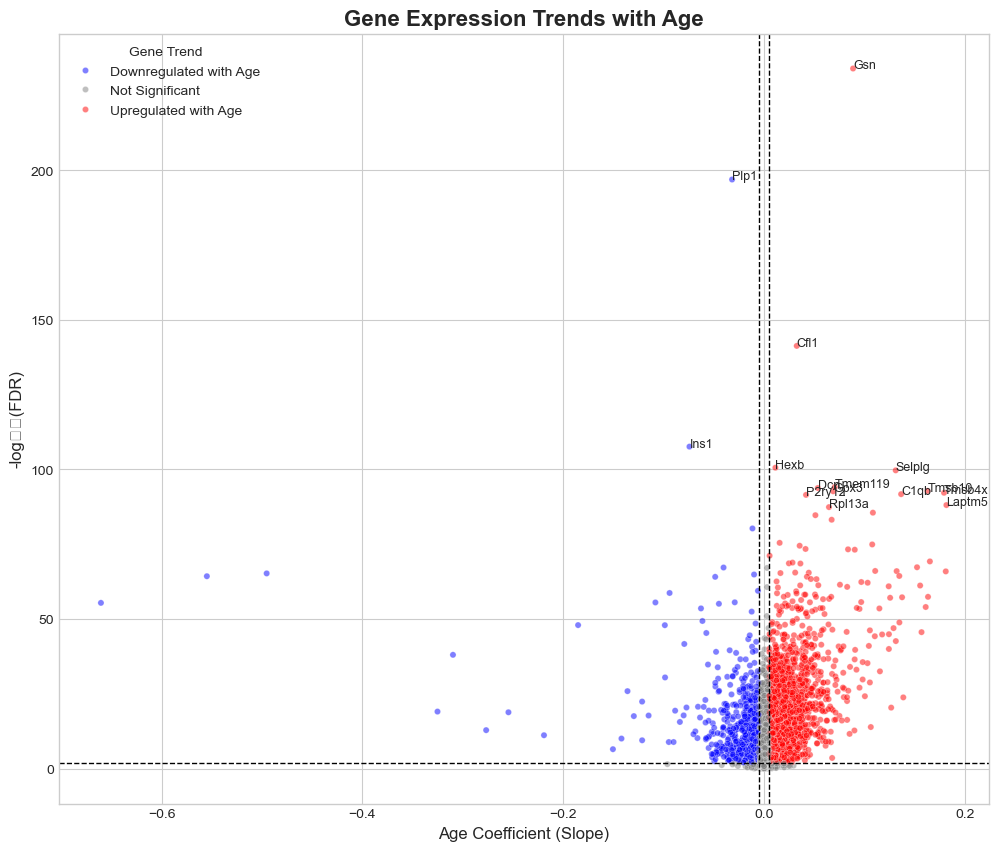

In [ ]:
# ==============================================================================
# --- Step 1: Load Required Libraries ---
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

print("Libraries loaded successfully.")


# ==============================================================================
# --- Step 2: Define Parameters and Load Data ---
# ==============================================================================
# --- Significance Thresholds (from the researchers' method) ---
FDR_THRESHOLD = 0.01
COEFFICIENT_THRESHOLD = 0.005

# --- Load the full results from the CSV file ---
# Make sure you have run the updated R script to generate this file
file_path = "mast_results_continuous_ALL.csv"
try:
    print(f"Loading MAST results from '{file_path}'...")
    results_df = pd.read_csv(file_path)
    print("Data loaded successfully. Here's a preview:")
    print(results_df.head())
except FileNotFoundError:
    print(f"FATAL ERROR: The file '{file_path}' was not found.")
    print("Please run the updated R script to create this file.")
    sys.exit()


# ==============================================================================
# --- Step 3: Prepare Data for Plotting ---
# ==============================================================================
print("Preparing data for visualization...")

# --- Calculate -log10 of the FDR for the y-axis ---
# We add a tiny number to avoid errors with FDR values of 0
results_df['-log10_FDR'] = -np.log10(results_df['FDR'] + 1e-300)

# --- Categorize genes based on the researchers' significance criteria ---
def classify_trend(row):
    is_significant = row['FDR'] < FDR_THRESHOLD
    trends_up = row['age_coefficient'] > COEFFICIENT_THRESHOLD
    trends_down = row['age_coefficient'] < -COEFFICIENT_THRESHOLD

    if is_significant and trends_up:
        return 'Upregulated with Age'
    elif is_significant and trends_down:
        return 'Downregulated with Age'
    else:
        return 'Not Significant'

results_df['significance'] = results_df.apply(classify_trend, axis=1)


# ==============================================================================
# --- Step 4: Generate the Volcano Plot ---
# ==============================================================================
print("Generating the volcano plot...")

# --- Create the plot canvas ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 10))

# --- Create the scatter plot ---
sns.scatterplot(
    data=results_df,
    x='age_coefficient',
    y='-log10_FDR',
    hue='significance',
    palette={
        'Upregulated with Age': 'red',
        'Downregulated with Age': 'blue',
        'Not Significant': 'grey'
    },
    alpha=0.5,
    s=20
)

# --- Add threshold lines for clarity ---
plt.axhline(y=-np.log10(FDR_THRESHOLD), color='black', linestyle='--', linewidth=1)
plt.axvline(x=COEFFICIENT_THRESHOLD, color='black', linestyle='--', linewidth=1)
plt.axvline(x=-COEFFICIENT_THRESHOLD, color='black', linestyle='--', linewidth=1)

# --- Annotate top significant genes ---
# We'll label the 15 genes with the smallest FDR
top_genes = results_df[results_df['significance'] != 'Not Significant'].nsmallest(15, 'FDR')

for i, row in top_genes.iterrows():
    plt.text(x=row['age_coefficient'], y=row['-log10_FDR'], s=row['gene'], fontsize=9)

# --- Final Touches: Titles and Labels ---
plt.title('Gene Expression Trends with Age', fontsize=16, fontweight='bold')
plt.xlabel('Age Coefficient (Slope)', fontsize=12)
plt.ylabel('-log₁₀(FDR)', fontsize=12)
plt.legend(title='Gene Trend')

# --- Display the plot ---
print("Displaying plot. Close the plot window to finish the script.")
plt.show()

X-Axis (Age Coefficient / Slope): This represents the rate of change in a gene's expression per month of age.
- Right Side (Positive): Genes that consistently increase in expression as the mice get older. A larger value means a faster rate of increase.
- Left Side (Negative): Genes that consistently decrease in expression as the mice get older. A more negative value means a faster rate of decrease.
- Center (Near Zero): Genes whose expression remains stable over time.

Y-Axis (-log₁₀(FDR)): This is your statistical confidence. The higher a gene is on the plot, the more confident you can be that its trend is real and not due to random chance.

The Points (Genes):
- Red Points (Upregulated with Age): The key finding of this analysis. These genes are significantly and progressively turned on with age.
- Blue Points (Downregulated with Age): These genes are significantly and progressively turned off with age.
- Grey Points (Not Significant): The majority of genes, which show no consistent trend.

Thresholds:

- The Horizontal Line: The Gatekeeper of Statistical Significance: This line is set at your False-Discovery Rate (FDR) threshold of 0.01. On the plot's y-axis, this corresponds to a value of -log₁₀(0.01), which equals 2.

Purpose: Its job is to filter out noise. When you test nearly 20,000 genes at once, some will appear to have a trend just by random chance. This threshold ensures that you only focus on genes where the observed trend is extremely unlikely to be a fluke.

Interpretation: A gene above this line has an FDR less than 0.01. This means there is a less than 1% chance that this finding is a false positive. This gives you high confidence that the age-related trend you see is statistically real.

- The Vertical Lines: The Gatekeepers of Biological Meaningfulness:

These lines are set at your Age Coefficient threshold of +0.005 and -0.005. This is your "effect size" threshold.

Purpose: Its job is to filter out changes that are real but trivial. A gene's expression could change by a tiny, statistically perfect 0.01% per year. While statistically "real," this change is likely too small to have any actual impact on the cell's function. These lines ensure you only focus on genes where the magnitude of the change is large enough to be potentially important.

Interpretation:
- A gene to the right of the +0.005 line is increasing at a rate the researchers deemed biologically relevant.
- A gene to the left of the -0.005 line is decreasing at a rate deemed biologically relevant.

Top Upregulated Genes Define an "Aging Signature": Your most confident hits are the genes that are progressively activated.

- Top Hit: Gsn (Gelsolin) is the most statistically significant upregulated gene. It is involved in cytoskeleton regulation and has been linked to cellular processes like apoptosis and inflammation. Its strong upregulation could point to changes in cell structure or stress responses with age.

- Inflammation/Immune Markers: Genes like C1qb and Selplg are associated with the immune system (complement cascade and cell adhesion). Their steady increase in hepatocytes is a classic sign of "inflammaging"—a chronic, low-grade inflammation that is a hallmark of aging.

- Other Hits: Cfl1 (Cofilin 1), Hexb, and Laptm5 are also very significant and warrant further investigation.

Top Downregulated Genes Confirm Metabolic and Functional Decline:

- Top Hit: Plp1 (Proteolipid protein 1) is a fascinating top hit. It is primarily known as a major component of myelin in the nervous system. Finding it strongly and consistently downregulated in liver hepatocytes is unusual and could suggest a novel function or be an artifact of cell type annotation. It requires careful follow-up.

- Metabolic Signature: The presence of Ins1 (Insulin 1) is highly significant. A progressive downregulation of insulin gene expression in hepatocytes could be linked to age-related declines in metabolic regulation and glucose homeostasis.

- Asymmetry in the "Slope": Notice that while there are many upregulated genes, their effect sizes (age coefficients) are mostly between 0 and 0.2. In contrast, several of the downregulated genes have much larger negative coefficients (e.g., beyond -0.4). This suggests that when a gene is turned off with age, the trend of suppression can be much stronger/faster than the trend of activation for upregulated genes.

GSEA is a statistical test performed on a ranked list of all genes in your dataset. It answers the question: "When I compare two groups of cells (e.g., old vs. young), are the genes in my SenMayo list systematically found at the top (upregulated) or bottom (downregulated) of the ranked list more than we'd expect by chance?"

Take the list of upregulated and dowregulated genes (red points) and run a gene set enrichment analysis (GSEA) or use a tool like Metascape. This will tell you which biological processes (e.g., "Inflammatory Response," "Lysosome Function") are being activated with age.


In [ ]:
# ==============================================================================
# --- Step 1: Load Libraries ---
# ==============================================================================
import pandas as pd
import numpy as np
import gseapy as gp
import sys

print("Libraries loaded successfully.")

# ==============================================================================
# --- Step 2: Load and Prepare the Ranked Gene List ---
# ==============================================================================
# Use the file with ALL genes from your MAST analysis
file_path = "mast_results_continuous_ALL.csv"
try:
    print(f"Loading MAST results from '{file_path}'...")
    results_df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"FATAL ERROR: The file '{file_path}' was not found.")
    print("Please make sure you have the complete results file from R.")
    sys.exit()

print("Preparing the ranked gene list for GSEA...")

# --- Create the ranking metric ---
# Metric = sign(coefficient) * -log10(FDR)
# We add a tiny number to FDR to avoid errors when FDR is 0
results_df['rank_metric'] = np.sign(results_df['age_coefficient']) * -np.log10(results_df['FDR'] + 1e-300)

# --- Create the final ranked list for gseapy ---
# The list needs to have two columns: gene name and the rank metric.
# It's also crucial to sort by the rank metric in descending order.
ranked_gene_list = results_df[['gene', 'rank_metric']].copy()
ranked_gene_list.dropna(inplace=True) # Remove any potential missing values
ranked_gene_list = ranked_gene_list.sort_values('rank_metric', ascending=False)

# GSEA can be sensitive to duplicate gene names. Let's remove them, keeping the one with the best rank.
ranked_gene_list = ranked_gene_list.drop_duplicates(subset='gene', keep='first')

print("Ranked list created successfully. Here's a preview:")
print(ranked_gene_list.head())

# ==============================================================================
# --- Step 3: Run GSEA Prerank Analysis ---
# ==============================================================================
print("\nStarting GSEA Prerank analysis...")

# --- (FIX) Let's find out what gene sets are available for Mouse ---
print("\nAvailable gene set libraries for Mouse:")
# This line will print a list of all valid names you can use
print(gp.get_library_name(organism='Mouse'))


print("\nRunning analysis...")
print("This may take a few minutes depending on the gene set library...")

# --- (FIX) Define Gene Set Libraries to test against with the CORRECT name ---
# Changed "KEGG_2021_Mouse" to "KEGG_2019_Mouse"
gene_sets_to_test = ["GO_Biological_Process_2021", "KEGG_2019_Mouse"]

# The gseapy.prerank() function is the core of the analysis
prerank_results = gp.prerank(
    rnk=ranked_gene_list,             # Your pre-ranked list of all genes
    gene_sets=gene_sets_to_test,      # The pathway databases to check against
    organism='Mouse',                 # Crucial! Set to 'Human' or 'Mouse'
    outdir='gsea_prerank_results',    # Name of the folder to save results
    min_size=15,                      # Min number of genes in a pathway to test
    max_size=500,                     # Max number of genes in a pathway to test
    format='png'                      # Save plots as png files
)

print("\n✅ GSEA analysis complete!")
print("Check the new folder 'gsea_prerank_results' for detailed results and plots.")

Libraries loaded successfully.
Loading MAST results from 'mast_results_continuous_ALL.csv'...
Preparing the ranked gene list for GSEA...
Ranked list created successfully. Here's a preview:
          gene  rank_metric
9656       Gsn   233.977727
4854      Cfl1   141.258892
9962      Hexb   100.543563
18295   Selplg    99.666519
20523  Tmem119    94.092283

Starting GSEA Prerank analysis...

Available gene set libraries for Mouse:


2025-11-18 13:00:31,232 [WARNING] Duplicated values found in preranked stats: 5.84% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency_CellLines_2023',

In [3]:
import pandas as pd
import numpy as np
import gseapy as gp
import re

# 1. Load and Prepare Ranked List
results_df = pd.read_csv("mast_results_continuous_ALL.csv")
results_df['rank_metric'] = np.sign(results_df['age_coefficient']) * -np.log10(results_df['FDR'] + 1e-300)
ranked_list = results_df[['gene', 'rank_metric']].copy()
ranked_list['gene'] = ranked_list['gene'].astype(str).str.capitalize()
ranked_list = ranked_list.sort_values('rank_metric', ascending=False).drop_duplicates('gene')

# 2. Run GSEA
print("--- Running Analysis ---")
pre_res = gp.prerank(
    rnk=ranked_list,
    gene_sets=["GO_Biological_Process_2021", "KEGG_2019_Mouse"],
    organism='Mouse',
    outdir=None, # No files saved to disk, just memory
    min_size=15,
    max_size=500,
    seed=42
)

# 3. Access and Filter Results
res = pre_res.res2d
sig_res = res[((res['NES'] > 1.5) | (res['NES'] < -1.5)) & 
              (res['FDR q-val'] < 0.25) & 
              (res['FWER p-val'] < 0.05)]

print("\n--- SIGNIFICANT PATHWAYS LIST ---\n")

# 4. Print "No Frills" List
for index, row in sig_res.iterrows():
    term = row['Term']
    nes = row['NES']
    
    # Determine direction
    direction = "[UPREGULATED]" if nes > 0 else "[DOWNREGULATED]"
    
    # Extract GO ID using regex (e.g., GO:0006614)
    go_match = re.search(r'GO:\d+', term)
    go_id = go_match.group(0) if go_match else "KEGG-PATHWAY"
    
    # Clean the pathway name (remove the GO ID from the end for a cleaner print)
    clean_name = re.sub(r' \(GO:\d+\)', '', term)
    
    print(f"{direction} {go_id} : {clean_name}")

print("\n--- End of List ---")

2026-04-22 12:48:54,108 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2026-04-22 12:48:54,164 [WARNING] Duplicated values found in preranked stats: 5.84% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


--- Running Analysis ---

--- SIGNIFICANT PATHWAYS LIST ---

[DOWNREGULATED] GO:0009063 : GO_Biological_Process_2021__cellular amino acid catabolic process
[DOWNREGULATED] KEGG-PATHWAY : KEGG_2019_Mouse__Maturity onset diabetes of the young
[DOWNREGULATED] GO:0016338 : GO_Biological_Process_2021__calcium-independent cell-cell adhesion via plasma membrane cell-adhesion molecules
[UPREGULATED] GO:0002181 : GO_Biological_Process_2021__cytoplasmic translation
[UPREGULATED] GO:0006614 : GO_Biological_Process_2021__SRP-dependent cotranslational protein targeting to membrane
[UPREGULATED] GO:0000184 : GO_Biological_Process_2021__nuclear-transcribed mRNA catabolic process, nonsense-mediated decay
[UPREGULATED] GO:0006613 : GO_Biological_Process_2021__cotranslational protein targeting to membrane
[UPREGULATED] GO:0045047 : GO_Biological_Process_2021__protein targeting to ER
[DOWNREGULATED] KEGG-PATHWAY : KEGG_2019_Mouse__Steroid hormone biosynthesis
[UPREGULATED] KEGG-PATHWAY : KEGG_2019_Mouse_

This is a table showing if the most significant pathways, after threshold application of:
- 'NES' (Normalized Enrichment Score) is either greater than 1.5 or less than -1.5
- 'FDR q-val' (False Discovery Rate q-value) is less than 0.25
- 'FWER p-val' (Familywise-Error Rate p-value) of less than 0.05

Are in any way connected to Senescence of Splicing Dysregulation

| Pathway                                                             | Senescence Connection | Splicing Dysregulation Connection |
| ------------------------------------------------------------------- | --------------------- | --------------------------------- |
| Cytoplasmic translation/ribosome/protein targeting to ER/SRP        | Yes                   | Yes                               |
| Nuclear-transcribed mRNA catabolic process, nonsense-mediated decay | Yes                   | Yes                               |
| Cellular/amino acid catabolic process                               | Yes                   | Indirect                          |
| Extracellular matrix disassembly/cell adhesion                      | Yes                   | Indirect                          |
| Lysosome                                                            | Yes                   | Indirect                          |
| Steroid hormone biosynthesis                                        | Contextual            | Indirect                          |
| Retinol metabolism                                                  | Weak/Contextual       | Indirect                          |
| Antigen/protein presentation, Fc gamma R-phagocytosis               | Indirect              | No                                |
| Cellular component disassembly                                      | Yes                   | Indirect                          |
| Peptide biosynthetic process                                        | Indirect              | Indirect                          |
| Other pathways                                                      | Indirect/None         | Indirect/None                     |

In [3]:
import pandas as pd
import numpy as np
import gseapy as gp
import glob
import os

# Thresholds
NES_THRESH = 1.5
FDR_THRESH = 0.25
FWER_THRESH = 0.05
GENE_SETS = ["GO_Biological_Process_2021", "KEGG_2019_Mouse"]

# Find cell-type files
input_files = glob.glob("mast_results_all_*.csv")
cell_type_files = [f for f in input_files if "continuous_ALL" not in f and "FDR_filtered" not in f]

print(f"Found {len(cell_type_files)} cell types to process.")

for file_path in cell_type_files:
    cell_type = file_path.replace("mast_results_all_", "").replace(".csv", "")
    print(f"\n>>> Processing: {cell_type}")

    try:
        df = pd.read_csv(file_path)
        
        # 1. CLEANING: Remove NaNs and normalize case
        df = df.dropna(subset=['FDR', 'age_coefficient'])
        df['gene'] = df['gene'].astype(str).str.capitalize()

        # 2. RANKING: Sign(coef) * -log10(FDR)
        df['rank_metric'] = np.sign(df['age_coefficient']) * -np.log10(df['FDR'] + 1e-300)
        ranked_list = df[['gene', 'rank_metric']].sort_values('rank_metric', ascending=False)
        ranked_list = ranked_list.drop_duplicates(subset='gene', keep='first')

        # 3. PRE-FLIGHT CHECK: Avoid the 'PanicException'
        # We check the overlap with the actual library before running the engine
        gene_set_data = gp.get_library_name(organism='Mouse')
        
        # Check if the ranking metric has any variation
        # If all genes have the same FDR (e.g., 1.0), rank_metric is constant and GSEA fails
        if ranked_list['rank_metric'].std() == 0:
            print(f"   Skipping: No statistical variation in MAST results (all FDRs might be 1.0).")
            continue

        # 4. RUN GSEA WITH TIGHTER ERROR CATCHING
        out_dir = f"GSEA_Plots_{cell_type}"
        
        try:
            # We use a very small min_size because your datasets are tiny
            pre_res = gp.prerank(
                rnk=ranked_list,
                gene_sets=GENE_SETS,
                organism='Mouse',
                outdir=out_dir,
                min_size=3,  # Minimum genes per pathway - very lenient
                max_size=500,
                format='png',
                seed=42,
                verbose=False
            )
            
            gsea_results = pre_res.res2d

            if gsea_results is not None and not gsea_results.empty:
                significant_pathways = gsea_results[
                    ((gsea_results['NES'] > NES_THRESH) | (gsea_results['NES'] < -NES_THRESH)) &
                    (gsea_results['FDR q-val'] < FDR_THRESH) &
                    (gsea_results['FWER p-val'] < FWER_THRESH)
                ].copy()

                output_csv = f"GSEA_SIGNIFICANT_pathways_{cell_type}.csv"
                significant_pathways.to_csv(output_csv, index=False)
                print(f"   ✅ Done! Found {len(significant_pathways)} significant pathways.")
            else:
                print(f"   Notice: No enrichment found.")

        except Exception as engine_err:
            # This is where the Option::unwrap() Panic is caught
            print(f"   ⚠️  Skipping {cell_type}: GSEA engine could not find enough overlap in pathways.")

    except Exception as data_err:
        print(f"   ❌ Data error for {cell_type}: {data_err}")

print("\nWorkflow complete.")

Found 11 cell types to process.

>>> Processing: B_cell


2026-03-25 11:29:56,935 [WARNING] Duplicated values found in preranked stats: 98.39% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


   ✅ Done! Found 0 significant pathways.

>>> Processing: CD4positive_alphabeta_T_cell
   Skipping: No statistical variation in MAST results (all FDRs might be 1.0).

>>> Processing: CD8positive_alphabeta_T_cell
   Skipping: No statistical variation in MAST results (all FDRs might be 1.0).

>>> Processing: endothelial_cell_of_hepatic_sinusoid


2026-03-25 11:33:00,144 [WARNING] Duplicated values found in preranked stats: 23.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


   ✅ Done! Found 19 significant pathways.

>>> Processing: hepatocyte


...

   ✅ Done! Found 0 significant pathways.

>>> Processing: neutrophil


2026-03-25 12:22:58,242 [WARNING] Duplicated values found in preranked stats: 99.89% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


   ✅ Done! Found 0 significant pathways.

>>> Processing: NK_cell
   Skipping: No statistical variation in MAST results (all FDRs might be 1.0).

>>> Processing: T_cell


2026-03-25 12:23:45,090 [WARNING] Duplicated values found in preranked stats: 99.92% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


   ✅ Done! Found 0 significant pathways.

Workflow complete.


In [4]:
import pandas as pd
import glob
import os

# 1. Find all significant pathway files
significant_files = glob.glob("GSEA_SIGNIFICANT_pathways_*.csv")

if not significant_files:
    print("No significant pathway files found. Please run the GSEA script first.")
else:
    print(f"Found {len(significant_files)} cell types with significant results.\n")

# 2. Process each file and print results
for file_path in significant_files:
    # Extract cell type name from the filename
    cell_type = file_path.replace("GSEA_SIGNIFICANT_pathways_", "").replace(".csv", "")
    
    # Load the data
    df = pd.read_csv(file_path)
    
    print("="*80)
    print(f"CELL TYPE: {cell_type.upper().replace('_', ' ')}")
    print("="*80)
    
    if df.empty:
        print("No pathways passed the significance thresholds for this cell type.")
    else:
        # Rank by Absolute NES (Magnitude of change)
        # We create a temporary column for sorting but print the original NES
        df['abs_NES'] = df['NES'].abs()
        df_ranked = df.sort_values(by='abs_NES', ascending=False)
        
        # Select and rename columns for a clean display
        # We use 'Term' (pathway name), 'NES', and 'FDR q-val'
        summary = df_ranked[['Term', 'NES', 'FDR q-val']].copy()
        
        # Add a 'Trend' column to make it easy to read
        summary['Trend'] = summary['NES'].apply(lambda x: "⬆️ Upregulated (Aged)" if x > 0 else "⬇️ Downregulated (Aged)")
        
        # Format for printing
        pd.set_option('display.max_colwidth', 60) # Don't cut off long pathway names
        print(summary.to_string(index=False))
        
        print(f"\nTotal significant pathways: {len(summary)}")
    
    print("\n") # Add spacing between cell types

Found 8 cell types with significant results.

CELL TYPE: B CELL
No pathways passed the significance thresholds for this cell type.


CELL TYPE: ENDOTHELIAL CELL OF HEPATIC SINUSOID
                                                                                                        Term      NES  FDR q-val                 Trend
        GO_Biological_Process_2021__SRP-dependent cotranslational protein targeting to membrane (GO:0006614) 1.860438   0.000000 ⬆️ Upregulated (Aged)
                      GO_Biological_Process_2021__cotranslational protein targeting to membrane (GO:0006613) 1.847439   0.000000 ⬆️ Upregulated (Aged)
                                            GO_Biological_Process_2021__cytoplasmic translation (GO:0002181) 1.846345   0.000000 ⬆️ Upregulated (Aged)
GO_Biological_Process_2021__nuclear-transcribed mRNA catabolic process, nonsense-mediated decay (GO:0000184) 1.840523   0.000000 ⬆️ Upregulated (Aged)
                                            GO_Biological_Proces